# <center> Redes neuronales para el Procesamiento del Lenguaje Natural </center>  
# <center> Práctica final </center>



# Detección de lenguaje ofensivo en redes sociales
## Jesús Ferrándiz Alarcón

En esta práctica vamos a utilizar el dataset OffendES el cual contiene 13368 instancias de entrenamiento y 3342 instancias 
de test. Tiene las siguientes etiquetas:
* Ofensivo, el objetivo es una persona (OFP)
* Ofensivo, el objetivo es un grupo de personas o colectivo (OFG)
* No ofensivo, aunque con lenguaje inapropiado o insultante (NOM)
* No ofensivo (NO)

Vamos a resolver la tarea de detección de lenguaje ofensivo a partir del entrenamiento de algoritmos de
aprendizaje automático en este dataset para clasificar las 4 clases mencionadas o la agrupación de estas en Ofensivo, No ofensivo.
Primero, vamos a definir unos baselines para tener unos resultados de referencia. Y posteriormente, vamos a entrenar
algoritmos basados en aprendizaje profundo y a compararlos entre ellos y con los baselines.

# Instalación

Proporciono un fichero **requirements.txt** que reproduce el entorno de Python de la práctica. Para instalarlo, ejecutar:
```bash
pip install -r requirements.txt
```

# Análisis de Datos y Representación de Textos

## Carga y visualización de datos

Comenzamos por una serie de imports.

In [1]:
# Librerias necesarias
# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':40,
         'ytick.labelsize': 40
}
plt.rcParams.update(params)
# Seaborn conf
import seaborn as sns
sns.set(style='darkgrid')
sns.set_palette(sns.color_palette("Blues"))

import sys

#Procesado de datos
import pandas as pd
import numpy as np
import operator

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

import warnings
warnings.filterwarnings('ignore')

Cargamos el dataset, **attención con la ruta relativa**. Se puede cambiar si el dataset está en otro lugar.

In [2]:
training_set = pd.read_csv('../OffendES_dataset/offendes/train.csv')
print(f"Training set shape: {training_set.shape}, columns: {training_set.columns.tolist()}")
test_set = pd.read_csv('../OffendES_dataset/offendes/test.csv')
print(f"Test set shape: {test_set.shape}, columns: {test_set.columns.tolist()}")

Training set shape: (13368, 3), columns: ['comment_id', 'comment', 'label']
Test set shape: (3342, 3), columns: ['comment_id', 'comment', 'label']


In [3]:
# Inspeccionamos el aspecto del conjunto de entrenamiento
training_set.head(20)

,comment_id,comment,label
0,2081,Dalas: hace una pregunta retórica Turbobo: *...,NO
1,21214,Por qué no solamente le diste a una fundación ...,NO
2,40888,Te ves guapísima y brillante con ese nuevo loo...,NO
3,40790,Se esta hablando de que Ariana Grande esta rel...,NO
4,55889,¡¡HAGO REVIEWS DE SERIES Y PELIS!! ¿ Quieres e...,NO
5,41294,"YouTube ya no es como antes, como en esos tiem...",NO
6,33127,Entrar a YouTube después de un día de mierda y...,NOM
7,40612,"Oye y no se puede pagar el curso, hacerlo y de...",NO
8,22418,"Hombre, Javi, se sobreentiende que cuando dice...",NO
9,18623,Lo que habla del hate de él y badabun yo creo ...,NO


Vemos que tenemos un dataset tabular con las columnas **comment_id**, **comment** y **label**.

In [4]:
# Inspeccionamos el aspecto del conjunto de test
test_set.head(20)

,comment_id,comment,label
0,30327,Eres el mejor Dalas no hagas caso a los haters...,NO
1,32217,La ballena blanca es el único mamífero que a c...,NO
2,799,"Sisi,yo ya estoy harta de él,y pensar que me g...",NO
3,12385,No quiero ser hater ni criticar mira mas abajo...,NO
4,10931,"Lo que dice el Rubius es cierto, mucha gente a...",NO
5,45843,Es el primer video q no me gusta !! Jeje miare...,NO
6,41627,windy por favor >:v deja de gritar me esta la...,NO
7,10540,De aquí a comentar a ese maldito video,NO
8,25087,Te odio BUUUU FALSA,OFP
9,18286,Haz un video opinando de la empresa in cruises...,NO


Vamos a revisar las etiquetas. Quiero ver que no haya errores de etiquetado en el sentido de que ninguna muestra
tenga alguna etiqueta que no sea ['NO', 'NOM', 'OFP', 'OFG'].

In [5]:
unique_labels_train = training_set['label'].unique()
print(f'Unique labels in training set: {unique_labels_train}')
unique_labels_test = test_set['label'].unique()
print(f'Unique labels in test set: {unique_labels_test}')

assert set(unique_labels_train) == set(unique_labels_test), "Train and test sets have different labels"

Unique labels in training set: <ArrowStringArray>
['NO', 'NOM', 'OFP', 'OFG']
Length: 4, dtype: str
Unique labels in test set: <ArrowStringArray>
['NO', 'OFP', 'NOM', 'OFG']
Length: 4, dtype: str


Las etiquetas son correctas. Todas las muestras tienen un valor que pertenece a la lista de etiquetas que esperábamos.

Ahora voy a crear una columna nueva para unir las etiquetas en 'Offensive' (OFP y OFG) y 'No offensive' (NOM y NO).

In [6]:
# Mapping dictionary
label_mapping = {
    'OFP': 'Offensive',
    'OFG': 'Offensive',
    'NOM': 'No offensive',
    'NO':  'No offensive'
}

# Apply mapping to create the new column
training_set['joint_label'] = training_set['label'].map(label_mapping)
test_set['joint_label']     = test_set['label'].map(label_mapping)

In [7]:
unique_labels_train = training_set['joint_label'].unique()
print(f'Unique labels in training set: {unique_labels_train}')
unique_labels_test = test_set['joint_label'].unique()
print(f'Unique labels in test set: {unique_labels_test}')

assert set(unique_labels_train) == set(unique_labels_test), "Train and test sets have different labels"

Unique labels in training set: <ArrowStringArray>
['No offensive', 'Offensive']
Length: 2, dtype: str
Unique labels in test set: <ArrowStringArray>
['No offensive', 'Offensive']
Length: 2, dtype: str


In [8]:
accepted_labels = {'No offensive', 'Offensive'}
rows_with_problems = training_set[training_set.joint_label.isin(accepted_labels) == False]
rows_with_problems

,comment_id,comment,label,joint_label


In [9]:
dataset = pd.concat([training_set, test_set])
dataset.shape
dataset.columns

Index(['comment_id', 'comment', 'label', 'joint_label'], dtype='str')

### Distribución de las muestras de entrenamiento
Ahora vamos a ver las distribución de las muestras en el set de datos de entrenamiento.

([0, 1, 2, 3],
 [Text(0, 0, 'NO'), Text(1, 0, 'OFP'), Text(2, 0, 'NOM'), Text(3, 0, 'OFG')])

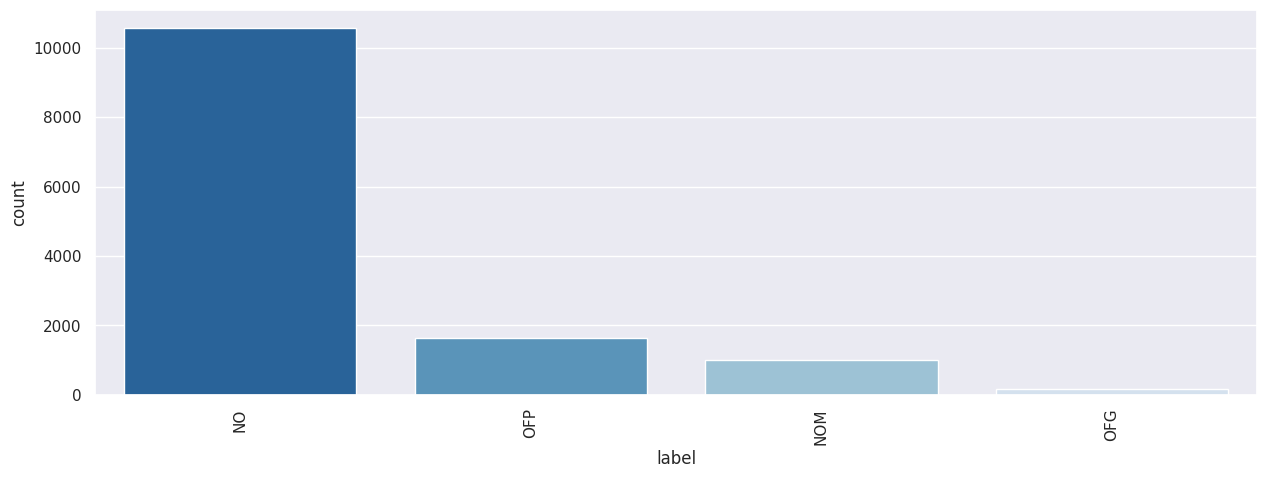

In [10]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.label, order=[x for x, count in sorted(Counter(training_set.label).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

Se puede ver que este es un problema desbalanceado donde la clase no tiene más de 5 veces más muestras que la siguiente clase (OFP).
OFP tiene casi el doble de muestras que NOM. Y OFG a penas tiene muestras si la comparamos con las demás clases.

En apartados posteriores podremos utilizar ciertas técnicas que ayuden con el problema del desequilibrio de los datos.

A continuación muestro la misma visualización para el etiquetado conjunto.

([0, 1], [Text(0, 0, 'No offensive'), Text(1, 0, 'Offensive')])

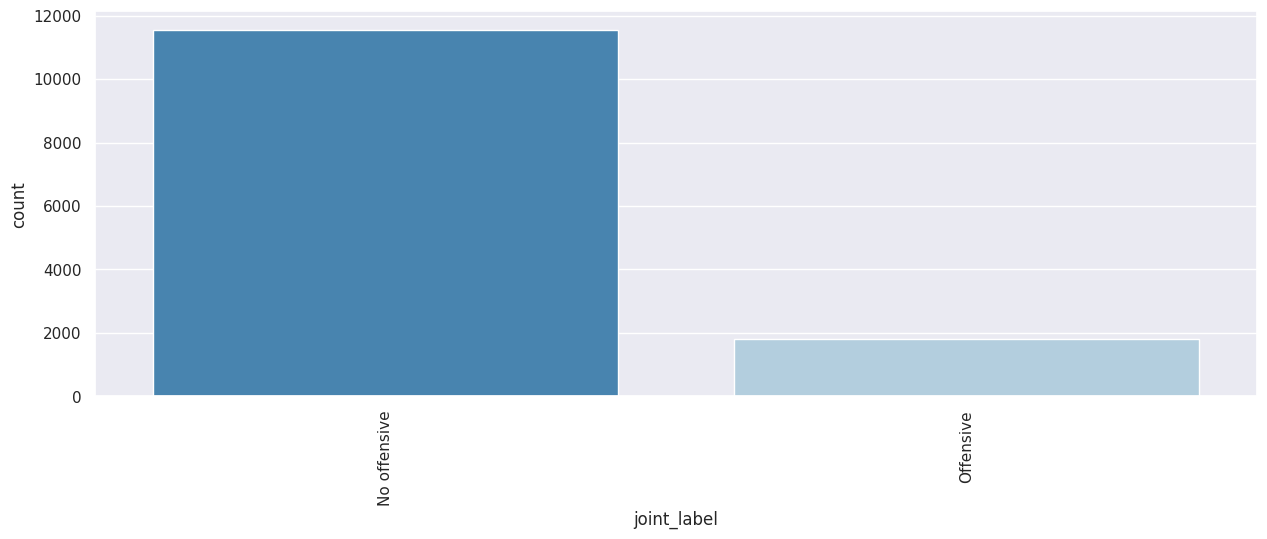

In [11]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.joint_label, order=[x for x, count in sorted(Counter(training_set.joint_label).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

Si el etiquetado es binario, tendremos que la clase No ofensiva, tiene alrededor de 6 veces más muestras que la clase ofensiva.

### Palabras más frecuentes por clase y procesado del texto
Vamos a ver ahora, para el etiquetado conjunto, qué términos son más comunes para cada clase.

In [12]:
from matplotlib import interactive

# Agrupamos las reviews por su etiqueta
df = pd.DataFrame({"text": training_set.comment, "label": training_set.joint_label})
grouped = df.groupby(['label']).apply(lambda x: x['text'].sum())
grouped_df = pd.DataFrame({'label': grouped.index, 'text': grouped.values})

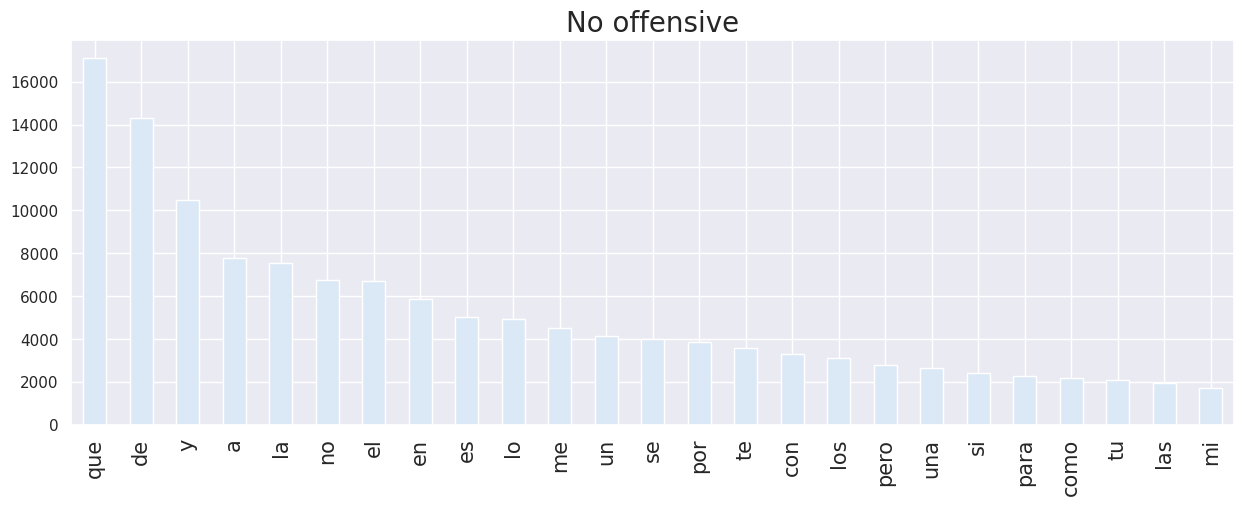

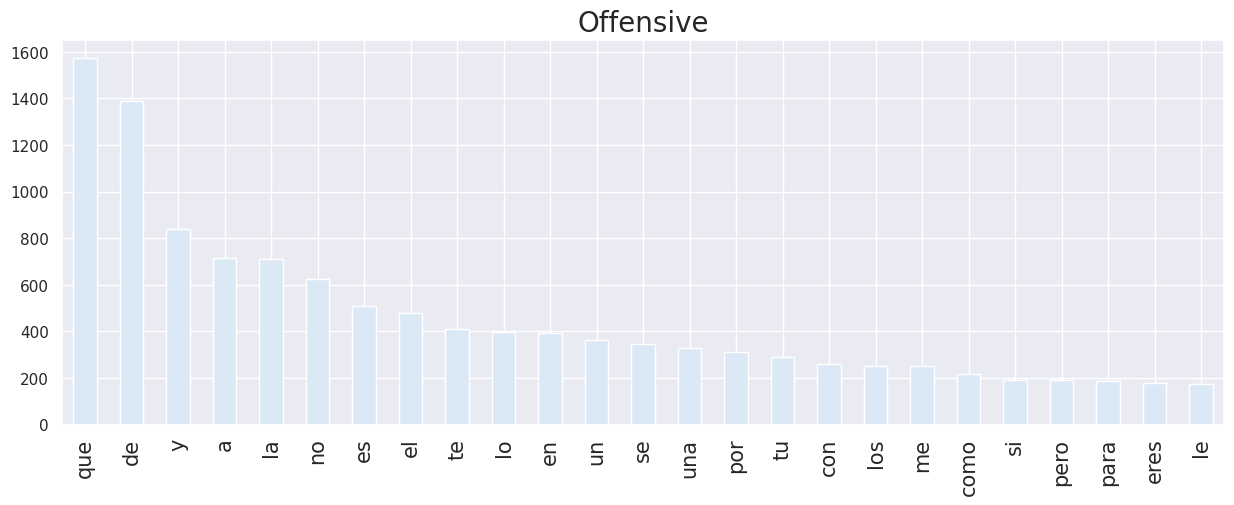

In [13]:
from nltk.tokenize import WhitespaceTokenizer
import matplotlib.pyplot as plt

tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    tokens = tokenizer.tokenize(text)
    
    word_counts = pd.Series(tokens).value_counts().head(25)
    
    word_counts.plot(kind="bar")
    plt.title(grouped_df.label[ii], fontsize=20)
    plt.xticks(fontsize=15)
    plt.show()

Se puede ver que en los datos sin procesar, los términos más comunes son stopwords del español. Esto no ayuda a diferenciar entre clases. Vamos
a hacer la misma visualización, pero normalizando el texto en el siguiente orden:
- Filtrar y quedarse solo con letras
- Convertir todo a minúscula
- Aplicar lematización
- Eliminar acentos

Si hubiese algún problema, por favor, ejecutar:
```bash
pip install spacy
python -m spacy download es_core_news_sm
```


In [14]:
import spacy
import unicodedata
import re

nlp = spacy.load("es_core_news_sm")
spanish_stopwords = nlp.Defaults.stop_words


def remove_accents(text, keep_enye=True):
    if keep_enye:
        text = text.replace('ñ', '\0n').replace('Ñ', '\0N')
    nfkd = unicodedata.normalize('NFD', text)
    stripped = ''.join(c for c in nfkd if unicodedata.category(c) != 'Mn')
    if keep_enye:
        stripped = stripped.replace('\0n', 'ñ').replace('\0N', 'Ñ')
    return stripped


def process_text(raw_text):
    # Keep letters with accents so the lemmatizer works correctly
    pattern = "[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]"
    letters_only = re.sub(pattern, " ", raw_text)

    # Lowercase
    text = letters_only.lower()

    # Lemmatize and remove stopwords
    doc = nlp(text)
    lemmas = [
        token.lemma_
        for token in doc
        if token.lemma_ not in spanish_stopwords and token.lemma_.strip()
    ]

    # Remove accents after lemmatization
    lemmas = [remove_accents(lemma) for lemma in lemmas]

    return " ".join(lemmas)

Procesamos los comentarios y los guardamos en una columna nueva.

In [15]:
from tqdm import tqdm
tqdm.pandas()

dataset['clean_comment'] = dataset['comment'].progress_apply(lambda x: process_text(x))

100%|██████████| 16710/16710 [01:27<00:00, 190.69it/s]


In [16]:
dataset.head()

,comment_id,comment,label,joint_label,clean_comment
0,2081,Dalas: hace una pregunta retórica Turbobo: *...,NO,No offensive,da el pregunta retorico turbobo contar el vida...
1,21214,Por qué no solamente le diste a una fundación ...,NO,No offensive,distir fundacion dale mil dolar alguien probab...
2,40888,Te ves guapísima y brillante con ese nuevo loo...,NO,No offensive,guapisimo brillante look fantastico video apor...
3,40790,Se esta hablando de que Ariana Grande esta rel...,NO,No offensive,hablar arianar relacionado movida atentado ocu...
4,55889,¡¡HAGO REVIEWS DE SERIES Y PELIS!! ¿ Quieres e...,NO,No offensive,reviews serie pelis querer empezar serie empez...


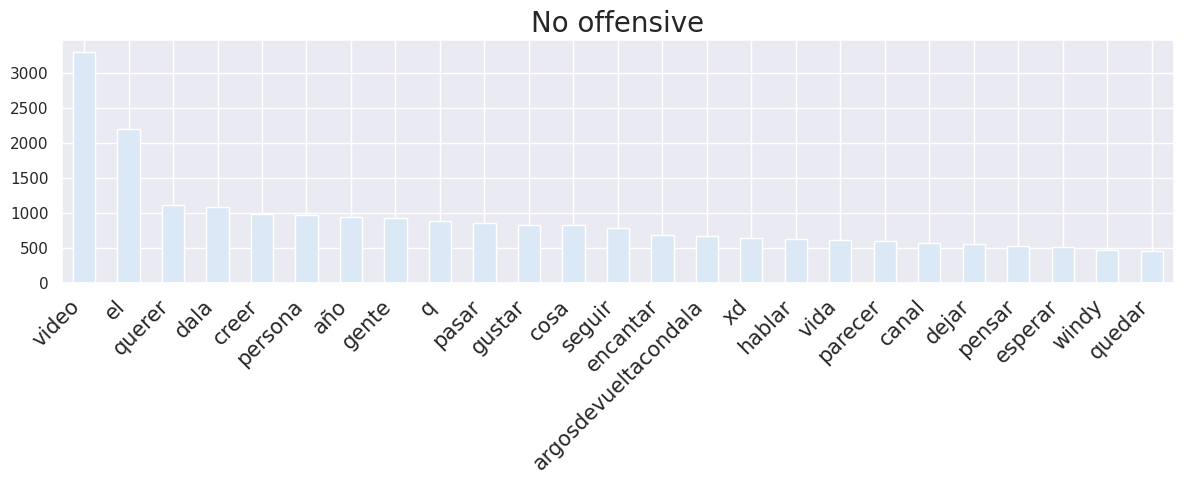

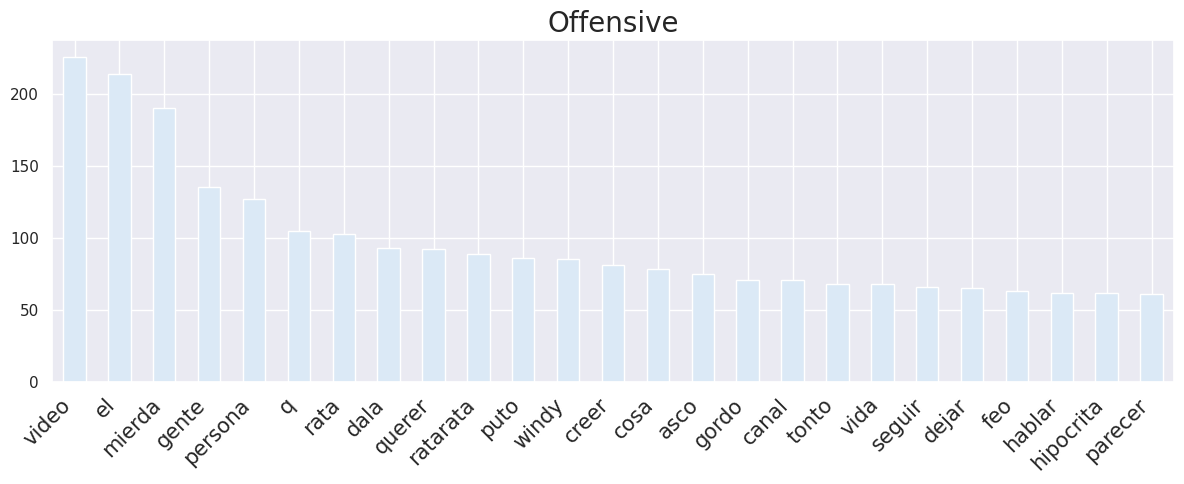

In [17]:
from nltk.tokenize import WhitespaceTokenizer
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "text": dataset[0:len(training_set)].clean_comment,
    "CLASS": dataset[0:len(training_set)].joint_label
})

grouped_df = (
    df.groupby("CLASS")["text"]
      .apply(lambda x: " ".join(x.astype(str)))
      .reset_index()
)

tokenizer = WhitespaceTokenizer()

for ii, text in enumerate(grouped_df.text):
    tokens = tokenizer.tokenize(text)
    word_counts = pd.Series(tokens).value_counts().head(25)
    
    plt.figure(figsize=(12, 5))
    word_counts.plot(kind="bar")
    plt.title(grouped_df.CLASS[ii], fontsize=20)
    plt.xticks(fontsize=15, rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Antes sin procesar el texto veíamos en ambas clases que las stopwords eran las palabras más frecuentes. Ahora, en cambio, aparecen en la clase
Offensive palabras que la ayudan a identificar y que no están en la clase No offensive: mierda, rata, puto, asco, feo, hipocrita, etc.

### Estadísticas sobre las longitudes de los comentarios
Vamos a ver ahora estadísticas sobre las longitudes de los comentarios. Estas estadísticas servirán posteriormente para dimensionar la entreada
(max len) de ciertos algoritmos.

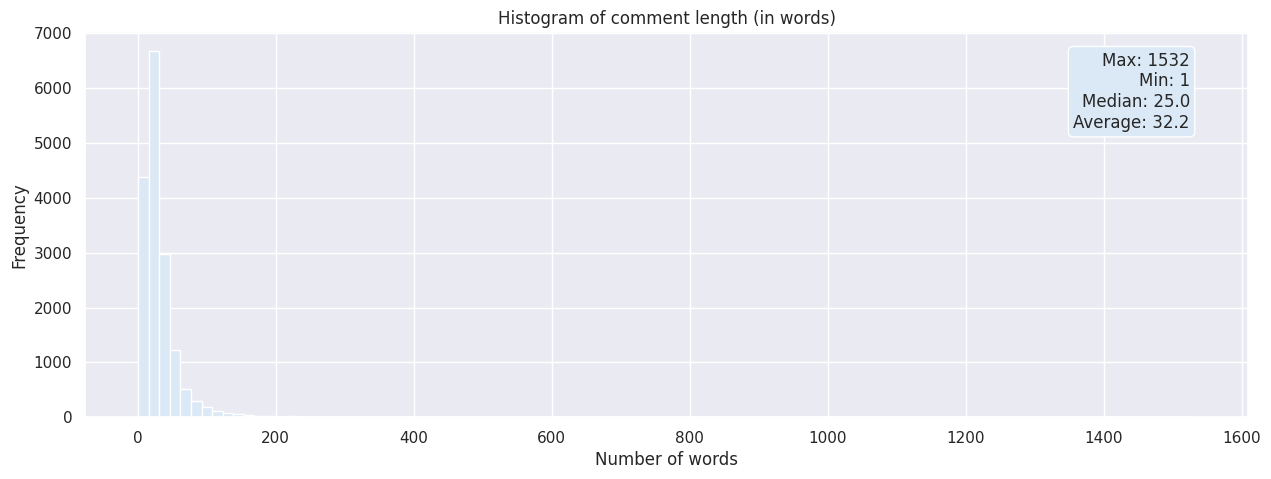

In [18]:
import matplotlib.pyplot as plt

# Count words in each string
word_counts = dataset.comment.str.split().str.len()

# Calculate statistics
max_len = word_counts.max()
min_len = word_counts.min()
median_len = word_counts.median()
avg_len = word_counts.mean()

# Plot histogram
word_counts.plot.hist(bins=100)
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.title('Histogram of comment length (in words)')

# Add statistics as text box
stats_text = (f'Max: {max_len}\n'
              f'Min: {min_len}\n'
              f'Median: {median_len:.1f}\n'
              f'Average: {avg_len:.1f}')
plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round'))

plt.show()

Sin procesar el texto, se ve que la longitud de los comentarios tiene una mediana de 25 palabras, con un outlier en 1532 palabras. Parece bastante seguro establecer una longitud máxima de 200 palabras.

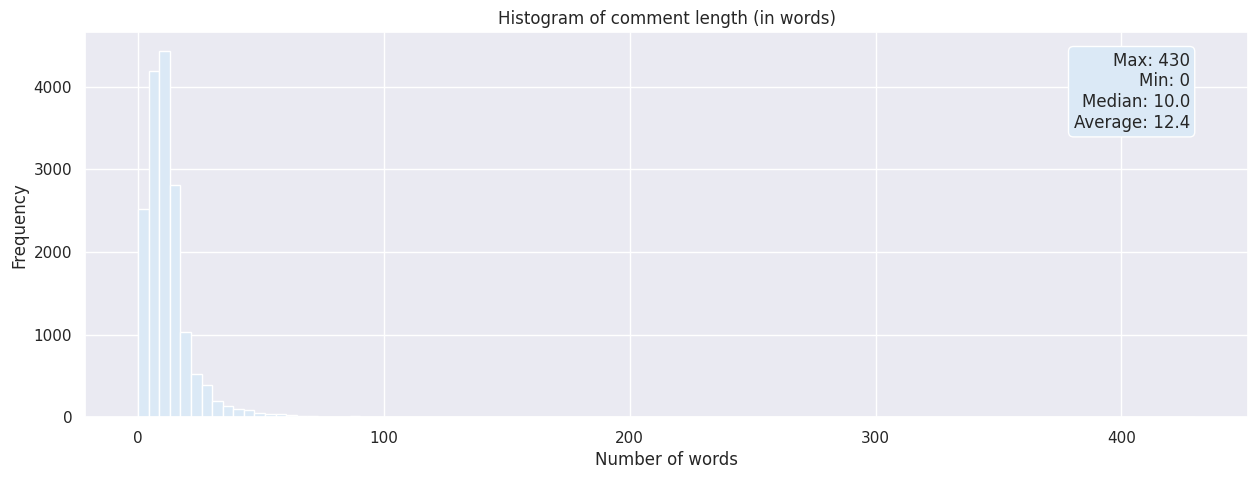

In [19]:
import matplotlib.pyplot as plt

# Count words in each string
word_counts = dataset.clean_comment.str.split().str.len()

# Calculate statistics
max_len = word_counts.max()
min_len = word_counts.min()
median_len = word_counts.median()
avg_len = word_counts.mean()

# Plot histogram
word_counts.plot.hist(bins=100)
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.title('Histogram of comment length (in words)')

# Add statistics as text box
stats_text = (f'Max: {max_len}\n'
              f'Min: {min_len}\n'
              f'Median: {median_len:.1f}\n'
              f'Average: {avg_len:.1f}')
plt.text(0.95, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round'))

plt.show()

Con los datos procesados, la mediana se reduce a 10 palabras. En este espacio sería bastante seguro utilizar una longitud máxima de secuencia de 100 palabras.

## Representaciones vectoriales

### Codificación de las etiquetas

In [20]:
X_train = dataset[0:len(training_set)][["comment_id", "clean_comment"]]
y_train = dataset[0:len(training_set)][["joint_label"]]

X_test = dataset[len(training_set):len(dataset)][["comment_id", "clean_comment"]]
y_test = dataset[len(training_set):len(dataset)][["joint_label"]]

In [21]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
print(f"Values before encoding: {y_train.joint_label.values}")
le.fit(y_train.joint_label.values)
target_labels = le.classes_
encoded_y_train = le.transform(y_train.joint_label.values)
print(f"Labels after encoding: {encoded_y_train}")

print(f"Target labels: {target_labels}")

Values before encoding: <ArrowStringArray>
['No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive',
 ...
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive', 'No offensive', 'No offensive',
 'No offensive', 'No offensive']
Length: 13368, dtype: str
Labels after encoding: [0 0 0 ... 0 0 0]
Target labels: ['No offensive' 'Offensive']


In [22]:
print(encoded_y_train)
print(encoded_y_train.shape)

[0 0 0 ... 0 0 0]
(13368,)


### Representación TF

In [23]:
X_train = dataset[0:len(training_set)][["comment_id", "clean_comment"]]
y_train = dataset[0:len(training_set)][["joint_label"]]

X_test = dataset[len(training_set):len(dataset)][["comment_id", "clean_comment"]]
y_test = dataset[len(training_set):len(dataset)][["joint_label"]]

In [24]:
count_vect = CountVectorizer(analyzer = "word")

train_features = count_vect.fit_transform(X_train.clean_comment)
test_features = count_vect.transform(X_test.clean_comment)

In [25]:
# Observemos el vocabulario
print('Longitud del vocabulario: ')
print(len(count_vect.vocabulary_))
print()
print("Observemos el vocabulario:")
print(count_vect.vocabulary_)
print()


Longitud del vocabulario: 
22969

Observemos el vocabulario:
{'da': 5406, 'el': 7141, 'pregunta': 16998, 'retorico': 18546, 'turbobo': 21473, 'contar': 4680, 'vida': 22090, 'año': 2148, 'llegar': 12739, 'xdd': 22678, 'distir': 6694, 'fundacion': 9307, 'dale': 5462, 'mil': 13925, 'dolar': 6781, 'alguien': 897, 'probablemente': 17166, 'siquiera': 19740, 'internet': 11343, 'quieres': 17684, 'ayudar': 2105, 'gente': 9517, 'excusa': 8389, 'video': 22102, 'seguidor': 19279, 'guapisimo': 9862, 'brillante': 2797, 'look': 12871, 'fantastico': 8713, 'aportar': 1458, 'hora': 10549, 'ejercicio': 7129, 'beso': 2473, 'hablar': 10021, 'arianar': 1608, 'relacionado': 18260, 'movida': 14336, 'atentado': 1858, 'ocurrio': 15095, 'concierto': 4458, 'pertenecer': 16267, 'mafia': 13047, 'arian': 1606, 'rechazar': 17972, 'titulo': 20971, 'dama': 5475, 'reina': 18235, 'isabel': 11489, 'ofrecer': 15157, 'reviews': 18606, 'serie': 19430, 'pelis': 16017, 'querer': 17640, 'empezar': 7290, 'bola': 2659, 'dejame': 

In [26]:
# Ejemplo original de una review
print("Original:")
print(dataset.comment.head()[0])
print()

# Ejemplo tras el preprocesado
print("Pre-procesado:")
print(X_train.clean_comment[0])
print()

# Convertimos la primera review
v0 = count_vect.transform([X_train.clean_comment[0]]).toarray()[0]
print('Convertido: ')
print(v0)
print()

# Es demasiado grande para observarlo, imprimimos su longitud
print('Longitud del vector: ')
print(len(v0))
print()

# ¿Cuántas palabras contiene la frase?
print('Número de palabras: ')
print(np.sum(v0))
print()


Original:
Dalas: hace una pregunta retórica   Turbobo: *se pone a contarle su vida a partir de los 15 años y de cómo llegó hasta hoy*   Xdd

Pre-procesado:
da el pregunta retorico turbobo contar el vida año llegar xdd

Convertido: 
[0 0 0 ... 0 0 0]

Longitud del vector: 
22969

Número de palabras: 
11



### Representación TF-IDF

In [27]:
from sklearn.feature_extraction.text import TfidfTransformer

X_train["all"] = X_train[['clean_comment']].apply(lambda x: ''.join(x), axis=1)
X_test["all"] = X_test[['clean_comment']].apply(lambda x: ''.join(x), axis=1)

count_vect = CountVectorizer(analyzer = "word")
train_features = count_vect.fit_transform(X_train['all'])
test_features = count_vect.transform(X_test['all'])

# Se utiliza L2 (norma euclídea) para normalizar los vectores resultantes
tfidf = TfidfTransformer(norm="l2")
train_text_tfidf_features = tfidf.fit_transform(train_features)
test_text_tfidf_features = tfidf.transform(test_features)                


### Bigramas

In [28]:
bigram_count_vect = CountVectorizer(analyzer = "word", ngram_range=(1,2))
train_bigram_features = bigram_count_vect.fit_transform(X_train.clean_comment)
test_bigram_features = bigram_count_vect.transform(X_test.clean_comment)

### Bigramas con TF-IDF

In [29]:
tfidf = TfidfTransformer(norm="l2")
train_text_bigram_tfidf_features = tfidf.fit_transform(train_bigram_features)
test_text_bigram_tfidf_features = tfidf.fit_transform(test_bigram_features)

### Bigramas con TF-IDF y reducción de características a 5000

In [30]:
bigram_tfidf_chi2_vect = TfidfVectorizer(norm="l2", ngram_range=(1,2))
train_text_bigram_tfidf_chi2_features = bigram_tfidf_chi2_vect.fit_transform(X_train.clean_comment)
test_text_bigram_tfidf_chi2_features = bigram_tfidf_chi2_vect.transform(X_test.clean_comment)

ch2 = SelectKBest(chi2, k=5000)
train_text_bigram_tfidf_chi2_features = ch2.fit_transform(train_text_bigram_tfidf_chi2_features, y_train)
test_text_bigram_tfidf_chi2_features = ch2.transform(test_text_bigram_tfidf_chi2_features)

# Definición de baselines

Como baselines, vamos a utilizar algoritmos de **Machine Learning** clásicos. Primero, vamos a representar los comentarios en una representación vectorial del tipo: TF, TF-IDF y con bigramas. Posteriormente, entrenaremos algoritmos de ML con estas features e identificaremos el que mejor resultados tenga. Se considera esto un baseline por que:
- Son rápidos de entrenar directamente en CPU.
- Son rápidos de implementar. Al menos en las prácticas no han requerido mucha ingeniería ni finetuning.
- En las prácticas anteriores se demostró que obtienen buenos resultados.


## Utilidades
Primero definimos una serie de funciones para entrenar, evaluar y mostrar resultados de los algoritmos de machine learning clásicos.

In [31]:
import numpy as np
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        scoring='f1_macro',
                        train_sizes=np.linspace(.1, 1.0, 5)):

    plt.figure()
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=1, train_sizes=train_sizes,
        scoring=scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.legend(loc="best")
    plt.grid("on")
    if ylim:
        plt.ylim(ylim)
    plt.title(title)

In [32]:
def train_and_evaluate_classifier(X, yt, estimator, grid):
    """Train and Evaluate a estimator (defined as input parameter) on the given labeled data using F1 Macro."""

    # Se realiza validación cruzada estratificada sobre el clasificador seleccionado
    from sklearn.model_selection import StratifiedShuffleSplit
    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    from sklearn.model_selection import GridSearchCV
    classifier = GridSearchCV(estimator=estimator, cv=cv, param_grid=grid,
                              scoring='f1_macro', error_score=0.0,
                              n_jobs=-1, verbose=5)
    
    # Entrenamiento
    print("Training model")
    classifier.fit(X, yt)

    # Puntuación de la validación cruzada
    print("CV-scores for each grid configuration")
    means = classifier.cv_results_['mean_test_score']
    stds = classifier.cv_results_['std_test_score']
    for mean, std, params in sorted(zip(means, stds, classifier.cv_results_['params']), key=lambda x: -x[0]):
        print("F1 Macro: %0.3f (+/-%0.03f) for params: %r" % (mean, std * 2, params))
    print()
        
    # Curva de aprendizaje
    print("Learning curve for the best estimator")
    title = 'Learning Curves (' + str(estimator.__class__).replace("'>", "").split(".")[-1] + ' )'
    plot_learning_curve(classifier.best_estimator_, title, X, yt, cv=cv)
    plt.show()
    
    return classifier

In [33]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    import itertools
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()


## Baselines 2 classes

### Naive Bayes

Training model
Fitting 5 folds for each of 1 candidates, totalling 5 fits


CV-scores for each grid configuration
F1 Macro: 0.645 (+/-0.026) for params: {}

Learning curve for the best estimator


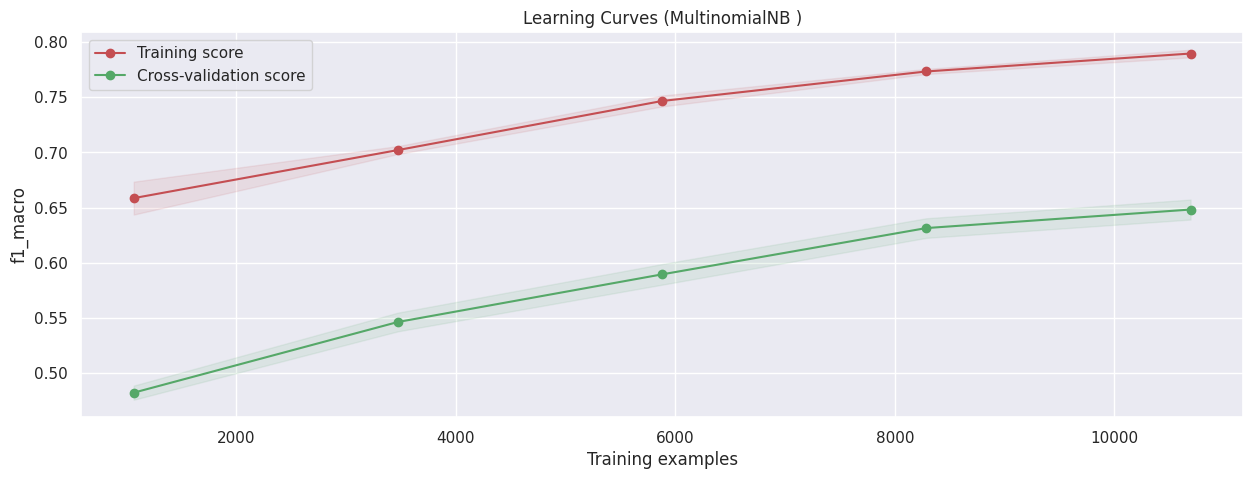

In [34]:
from sklearn.naive_bayes import MultinomialNB

#En este caso no hace falta optimizar ningún parámetro
nb_grid= {} 

nb_text_cls = train_and_evaluate_classifier(train_features, encoded_y_train, MultinomialNB(), nb_grid)

In [35]:
print("Predicting on the test set")
y_pred = nb_text_cls.predict(test_features)

y_pred = le.inverse_transform(y_pred)

Predicting on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.89      0.99      0.94      2889
   Offensive       0.84      0.24      0.37       453

    accuracy                           0.89      3342
   macro avg       0.87      0.62      0.66      3342
weighted avg       0.89      0.89      0.86      3342

Confusion matrix, without normalization


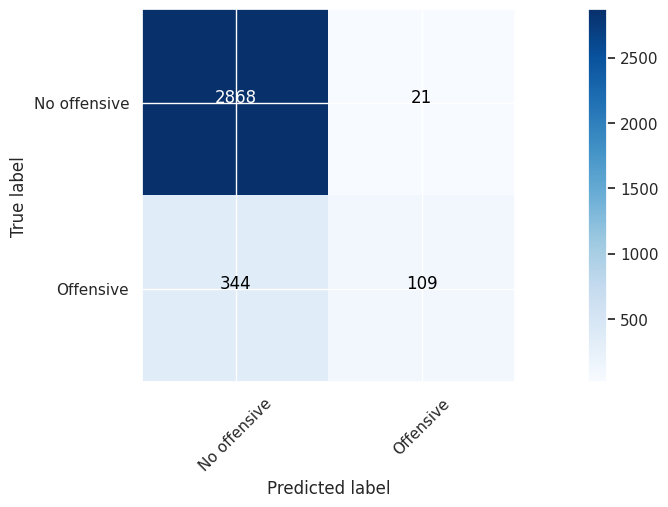

F1 Macro: 0.6571


In [36]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

La matriz de confusión muestra bastantes errores al detectar la clase "Offensive". Se ve que:
- 109 casos con clase verdadera Offensive se han clasificaco como offensive (True Positive).
- 344 casos con clase verdadera Offensive se han clasificado como No offensive (False Negative).
- 21 casos con clase verdadera No Offensive, se han clasificado como Offensive (False Positive).

### SVM

He añadido un **class_weight='balanced'** con el fin de penalizar más los errores cometidos en la clase minoritaria. Espero
que ahora se cometan menos errores en la clase **Offensive**. 

Training model
Fitting 5 folds for each of 6 candidates, totalling 30 fits


CV-scores for each grid configuration
F1 Macro: 0.745 (+/-0.010) for params: {'C': 1, 'kernel': 'linear'}
F1 Macro: 0.744 (+/-0.011) for params: {'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}
F1 Macro: 0.714 (+/-0.019) for params: {'C': 10, 'kernel': 'linear'}
F1 Macro: 0.698 (+/-0.012) for params: {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
F1 Macro: 0.691 (+/-0.015) for params: {'C': 100, 'kernel': 'linear'}
F1 Macro: 0.422 (+/-0.024) for params: {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}

Learning curve for the best estimator


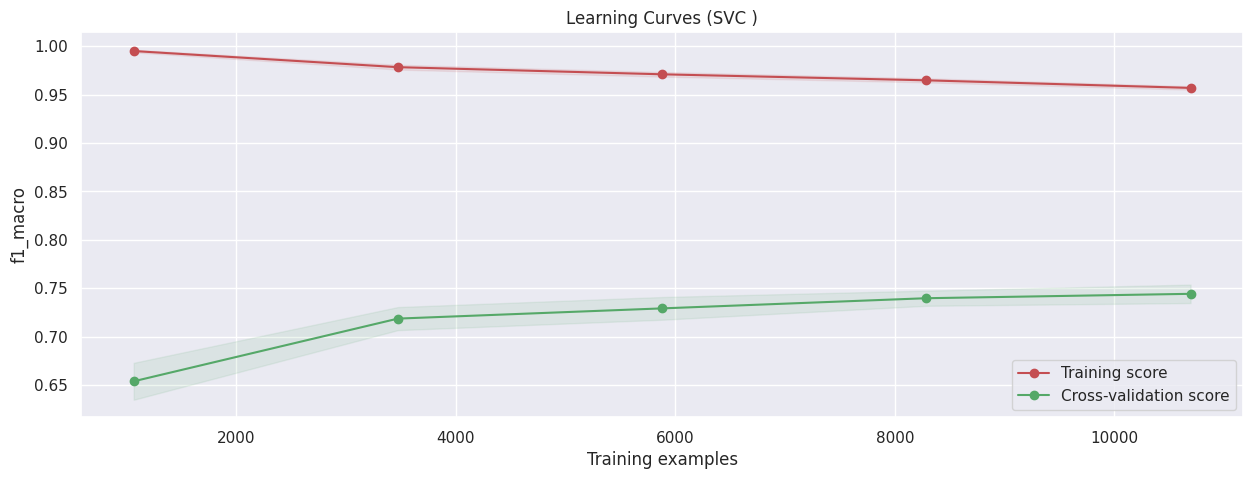

In [37]:
# SVM
from sklearn.svm import SVC

svm_grid = [
  {'C': [1, 10, 100], 'kernel': ['linear']},
  {'C': [10, 100, 1000], 'gamma': [0.0001], 'kernel': ['rbf']},
 ]

svm_cls = train_and_evaluate_classifier(train_features, encoded_y_train, SVC(class_weight='balanced'), svm_grid)

In [38]:
print("Best estimator found by grid search:")
print(svm_cls.best_estimator_)

Best estimator found by grid search:
SVC(C=1, class_weight='balanced', kernel='linear')


In [39]:
print("Predicting sentiment reviews on the test set")
y_pred = svm_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment reviews on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.91      0.92      2889
   Offensive       0.52      0.63      0.57       453

    accuracy                           0.87      3342
   macro avg       0.73      0.77      0.75      3342
weighted avg       0.88      0.87      0.88      3342

Confusion matrix, without normalization


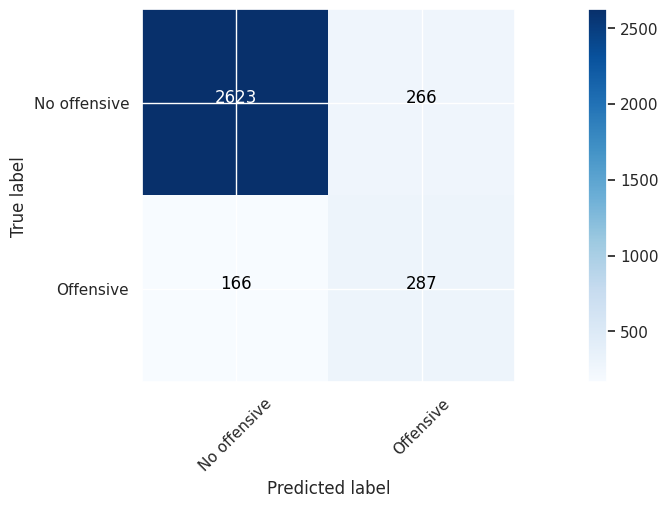

F1 Macro: 0.7472


In [40]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

F1 macro ahora es mejor que antes. Los True positive han aumentado (287), pero tenemos más false positives (266).
En ciertas aplicaciones se prefiere tener un algoritmo que tienda a dar más FP que FN. Por ejemplo, sería peligroso un algoritmo de detección de cáncer que cometa muchos false negatives. En estos casos el algoritmo dice que no hay cáncer cuando sí lo hay. Sería más conservador tener más False Positives y pocos False Negatives.

En el contexto de lenguaje ofensivo de redes sociales dependerá del criterio de la red social. Si se usa una estrategia de tener más False Positives y menos False Negatives una solución sería que una persona revise las detecciones (solo las positivas).

### MaxEnt

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits


CV-scores for each grid configuration
F1 Macro: 0.752 (+/-0.012) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.752 (+/-0.009) for params: {'C': 1, 'penalty': 'l1'}
F1 Macro: 0.747 (+/-0.011) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.739 (+/-0.007) for params: {'C': 10, 'penalty': 'l1'}
F1 Macro: 0.726 (+/-0.012) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.726 (+/-0.008) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.719 (+/-0.004) for params: {'C': 0.1, 'penalty': 'l1'}
F1 Macro: 0.717 (+/-0.014) for params: {'C': 100, 'penalty': 'l1'}
F1 Macro: 0.705 (+/-0.016) for params: {'C': 1000, 'penalty': 'l2'}
F1 Macro: 0.693 (+/-0.017) for params: {'C': 1000, 'penalty': 'l1'}
F1 Macro: 0.657 (+/-0.012) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.592 (+/-0.015) for params: {'C': 0.001, 'penalty': 'l2'}
F1 Macro: 0.464 (+/-0.000) for params: {'C': 0.001, 'penalty': 'l1'}
F1 Macro: 0.400 (+/-0.014) for params: {'C': 0.01, 'penalty': 'l1'}

Learning curve for th

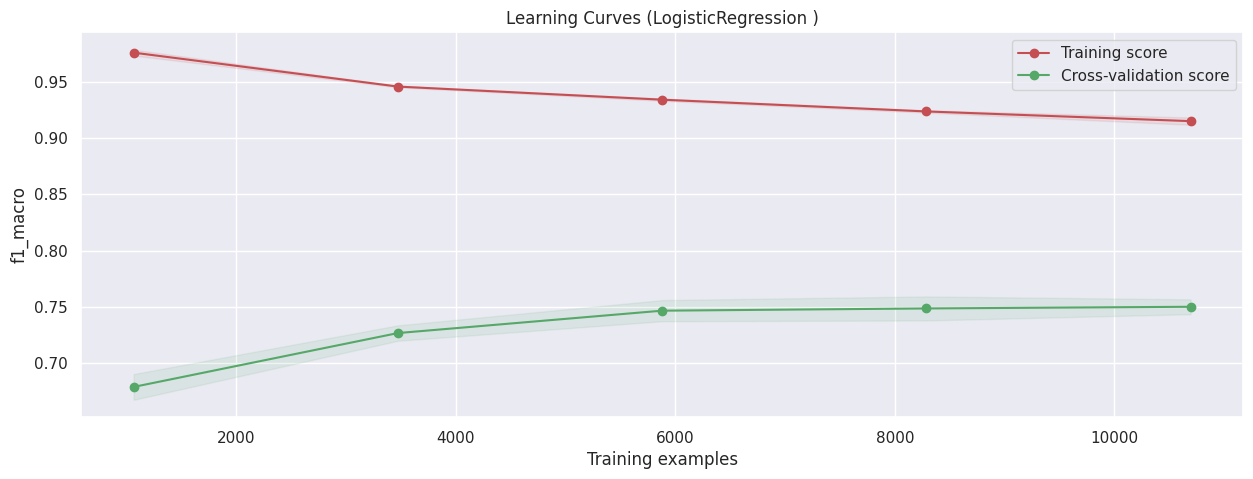

In [41]:
from sklearn.linear_model import LogisticRegression
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_cls = train_and_evaluate_classifier(train_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [42]:
print("Best estimator found by grid search:")
print(max_ent_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [43]:
print("Predicting sentiment on the test set")
y_pred = max_ent_cls.predict(test_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.89      0.92      2889
   Offensive       0.51      0.70      0.59       453

    accuracy                           0.87      3342
   macro avg       0.73      0.80      0.76      3342
weighted avg       0.89      0.87      0.88      3342

Confusion matrix, without normalization


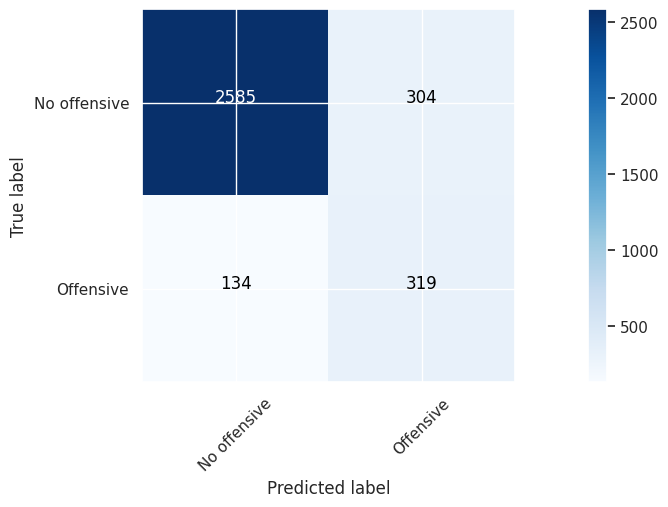

F1 Macro: 0.7574


In [44]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

La métrica F1 Macro es algo mejor que en SVM. Para las siguientes pruebas, seguiremos utilizando el algoritmo **MaxEnt**.

### MaxEnt Pesado con TF-IDF
Hasta ahora hemos usado features basadas en **TF**. A continuación vamos a entrenar con features **TF-IDF**.

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits


CV-scores for each grid configuration
F1 Macro: 0.765 (+/-0.018) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.762 (+/-0.010) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.756 (+/-0.025) for params: {'C': 1, 'penalty': 'l1'}
F1 Macro: 0.750 (+/-0.015) for params: {'C': 10, 'penalty': 'l1'}
F1 Macro: 0.750 (+/-0.013) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.743 (+/-0.017) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.741 (+/-0.018) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.739 (+/-0.015) for params: {'C': 0.001, 'penalty': 'l2'}
F1 Macro: 0.719 (+/-0.019) for params: {'C': 1000, 'penalty': 'l2'}
F1 Macro: 0.718 (+/-0.018) for params: {'C': 100, 'penalty': 'l1'}
F1 Macro: 0.711 (+/-0.019) for params: {'C': 0.1, 'penalty': 'l1'}
F1 Macro: 0.704 (+/-0.009) for params: {'C': 1000, 'penalty': 'l1'}
F1 Macro: 0.464 (+/-0.000) for params: {'C': 0.001, 'penalty': 'l1'}
F1 Macro: 0.464 (+/-0.000) for params: {'C': 0.01, 'penalty': 'l1'}

Learning curve for th

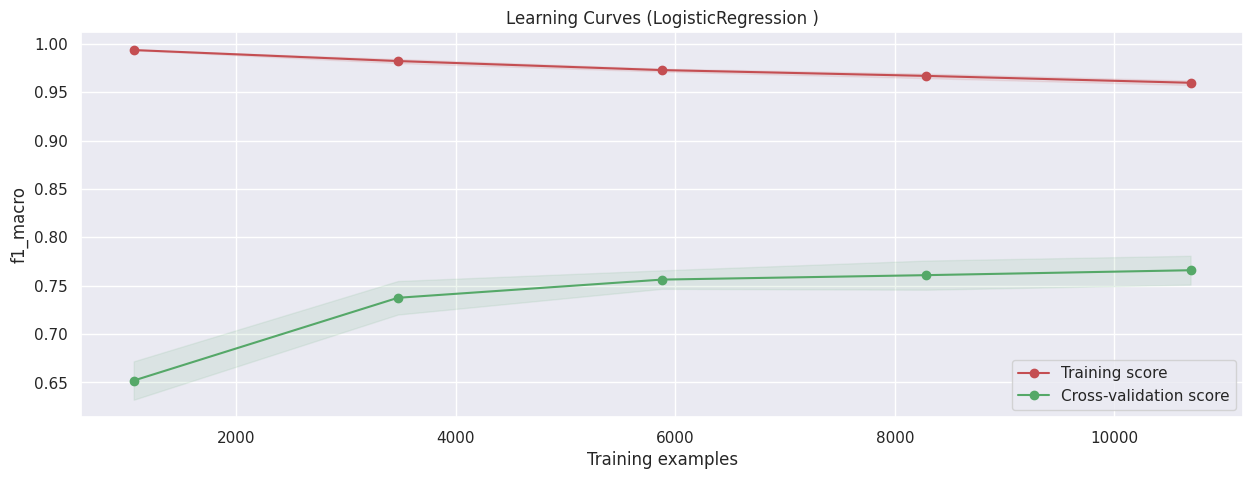

In [45]:
max_ent_grid= {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_tfidf_cls = train_and_evaluate_classifier(train_text_tfidf_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [46]:
print("Best estimator found by grid search:")
print(max_ent_tfidf_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=10, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [47]:
print("Predicting sentiment on the test set")
y_pred = max_ent_tfidf_cls.predict(test_text_tfidf_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.93      0.94      2889
   Offensive       0.59      0.62      0.61       453

    accuracy                           0.89      3342
   macro avg       0.77      0.78      0.77      3342
weighted avg       0.89      0.89      0.89      3342

Confusion matrix, without normalization


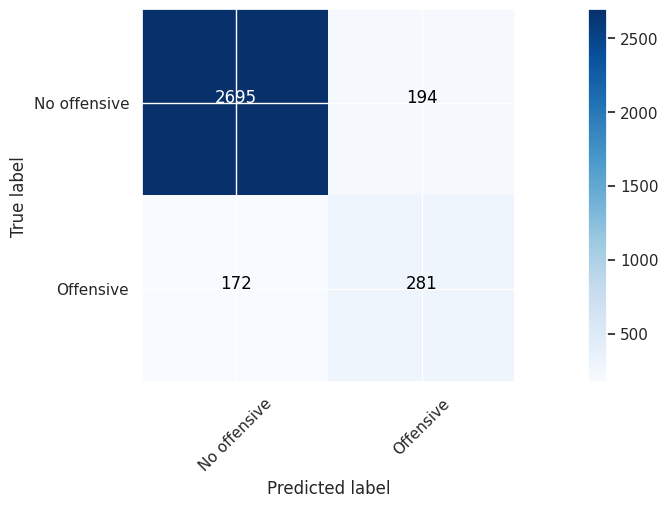

F1 Macro: 0.7710


In [48]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

Con la representación TF-IDF tenemos un mejor clasificador con el mismo algoritmo.

### MaxEnt Bigramas con TF

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits


CV-scores for each grid configuration
F1 Macro: 0.773 (+/-0.014) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.773 (+/-0.015) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.765 (+/-0.009) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.763 (+/-0.019) for params: {'C': 10, 'penalty': 'l1'}
F1 Macro: 0.757 (+/-0.014) for params: {'C': 1, 'penalty': 'l1'}
F1 Macro: 0.757 (+/-0.008) for params: {'C': 100, 'penalty': 'l1'}
F1 Macro: 0.757 (+/-0.006) for params: {'C': 1000, 'penalty': 'l2'}
F1 Macro: 0.756 (+/-0.009) for params: {'C': 1000, 'penalty': 'l1'}
F1 Macro: 0.743 (+/-0.011) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.723 (+/-0.008) for params: {'C': 0.1, 'penalty': 'l1'}
F1 Macro: 0.670 (+/-0.010) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.597 (+/-0.017) for params: {'C': 0.001, 'penalty': 'l2'}
F1 Macro: 0.464 (+/-0.000) for params: {'C': 0.001, 'penalty': 'l1'}
F1 Macro: 0.400 (+/-0.014) for params: {'C': 0.01, 'penalty': 'l1'}

Learning curve for th

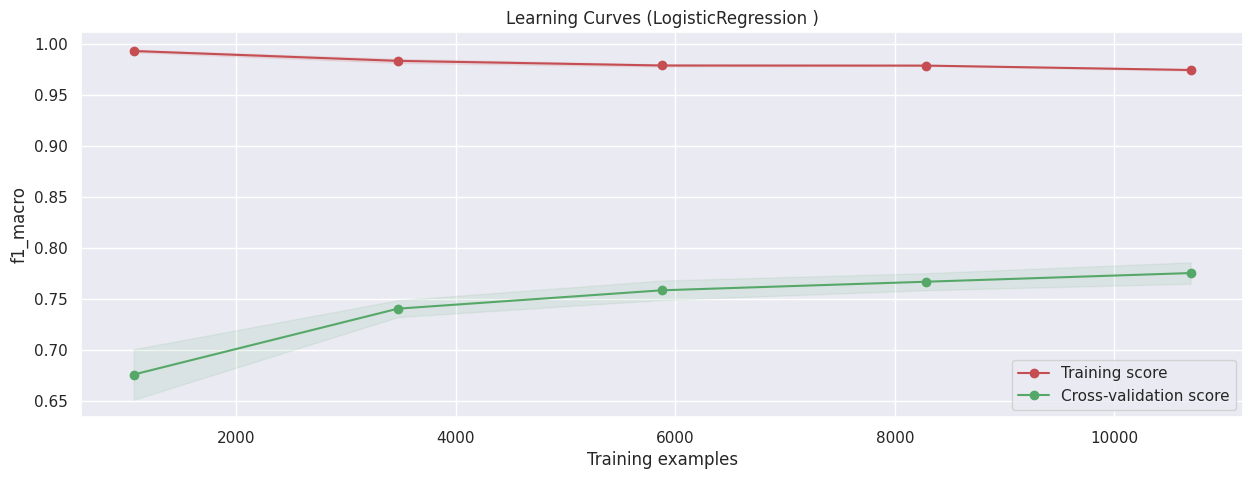

In [49]:
max_ent_bigram_cls = train_and_evaluate_classifier(train_bigram_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [50]:
print("Best estimator found by grid search:")
print(max_ent_bigram_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [51]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_cls.predict(test_bigram_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.94      0.93      0.94      2889
   Offensive       0.60      0.63      0.62       453

    accuracy                           0.89      3342
   macro avg       0.77      0.78      0.78      3342
weighted avg       0.90      0.89      0.89      3342

Confusion matrix, without normalization


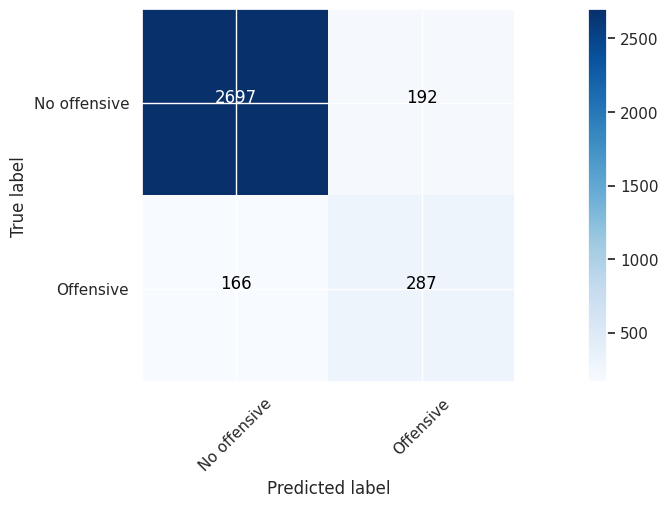

F1 Macro: 0.7768


In [52]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

Usar bigramas mejora la clasificación para el mismo algoritmo.

### MaxEnt Bigramas con TF-IDF

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits


CV-scores for each grid configuration
F1 Macro: 0.771 (+/-0.018) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.759 (+/-0.019) for params: {'C': 10, 'penalty': 'l1'}
F1 Macro: 0.759 (+/-0.023) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.755 (+/-0.014) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.754 (+/-0.024) for params: {'C': 1, 'penalty': 'l1'}
F1 Macro: 0.744 (+/-0.019) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.744 (+/-0.012) for params: {'C': 0.001, 'penalty': 'l2'}
F1 Macro: 0.740 (+/-0.017) for params: {'C': 100, 'penalty': 'l1'}
F1 Macro: 0.737 (+/-0.022) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.736 (+/-0.013) for params: {'C': 1000, 'penalty': 'l1'}
F1 Macro: 0.728 (+/-0.021) for params: {'C': 1000, 'penalty': 'l2'}
F1 Macro: 0.694 (+/-0.016) for params: {'C': 0.1, 'penalty': 'l1'}
F1 Macro: 0.464 (+/-0.000) for params: {'C': 0.001, 'penalty': 'l1'}
F1 Macro: 0.464 (+/-0.000) for params: {'C': 0.01, 'penalty': 'l1'}

Learning curve for th

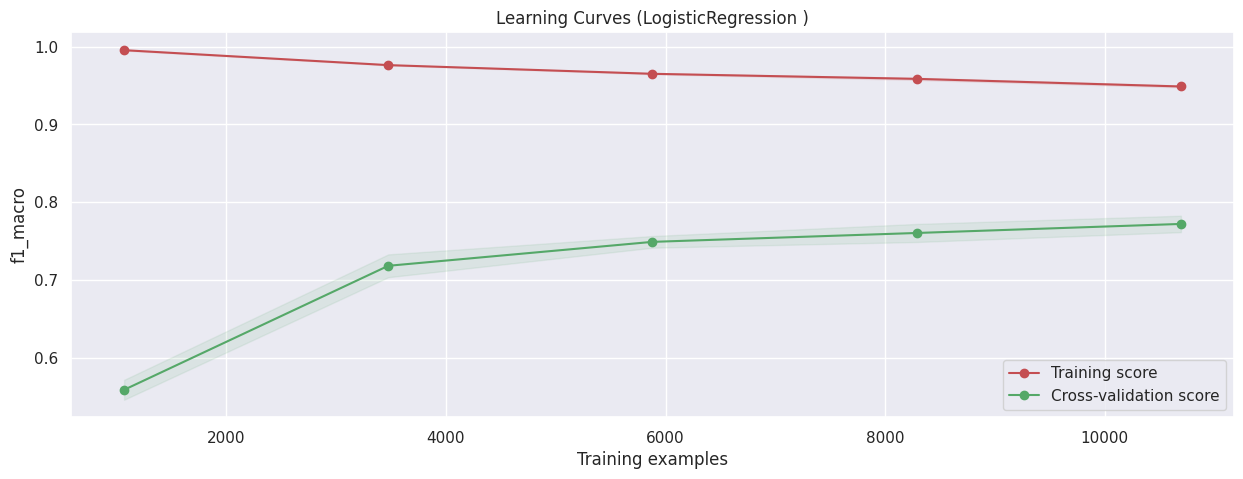

In [53]:
max_ent_bigram_tfidf_cls = train_and_evaluate_classifier(train_text_bigram_tfidf_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

In [54]:
print("Best estimator found by grid search:")
print(max_ent_bigram_tfidf_cls.best_estimator_)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', penalty='l2',
                   solver='liblinear')


In [55]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_tfidf_cls.predict(test_text_bigram_tfidf_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

Predicting sentiment on the test set


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.92      0.93      2889
   Offensive       0.58      0.68      0.62       453

    accuracy                           0.89      3342
   macro avg       0.76      0.80      0.78      3342
weighted avg       0.90      0.89      0.89      3342

Confusion matrix, without normalization


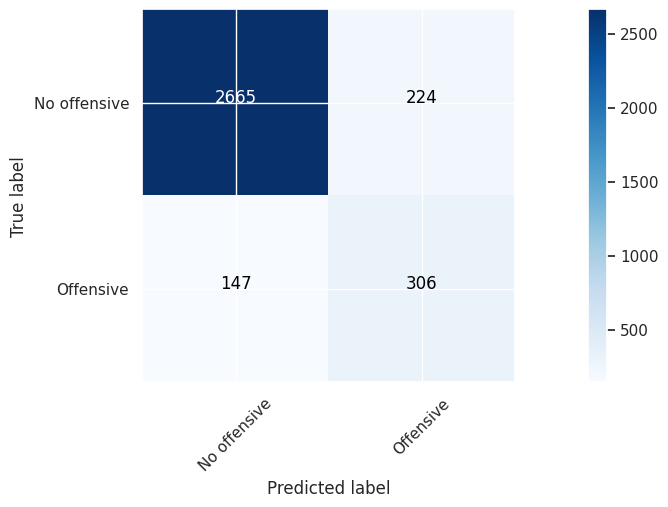

F1 Macro: 0.7788


In [56]:
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

Usar bigramas con TF-IDF es aún mejor para el mismo algoritmo.

In [57]:
def most_informative_feature_for_binary_classification(vectorizer, classifier, n=100):
    """
    See: https://stackoverflow.com/a/26980472
    
    Identify most important features if given a vectorizer and binary classifier. Set n to the number
    of weighted features you would like to show. (Note: current implementation merely prints and does not 
    return top classes.)
    """

    class_labels = classifier.classes_
    feature_names = vectorizer.get_feature_names_out()
    topn_class1 = sorted(zip(feature_names, classifier.coef_[0]), key=lambda u: u[1])[:n]
    topn_class2 = sorted(zip(feature_names, classifier.coef_[0]), key=lambda u: -u[1])[:n]

    return topn_class1, topn_class2

In [58]:
# Remember negative is index 0 and positive is index 1
negative_features, positive_features = most_informative_feature_for_binary_classification(bigram_count_vect, max_ent_cls.best_estimator_, n=30)

<Axes: title={'center': 'Most important features to identify negative reviews'}, xlabel='feature'>

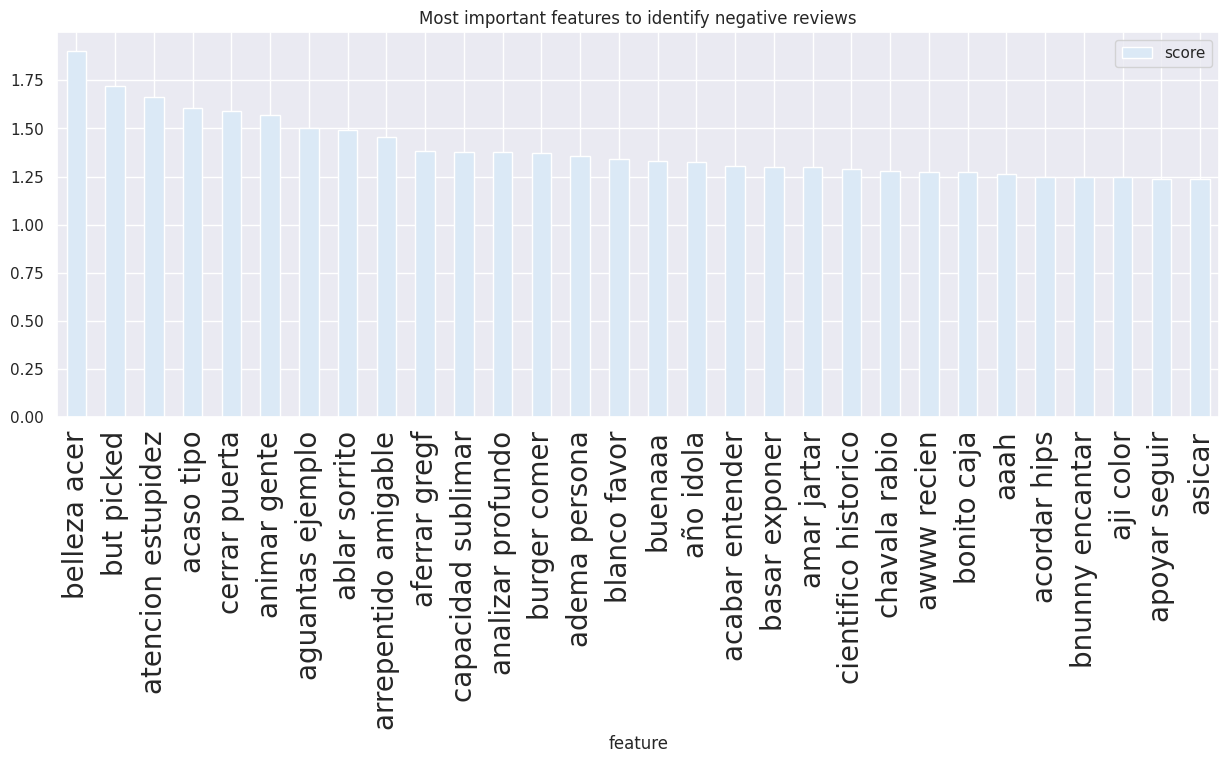

In [59]:
top_negative_features = pd.DataFrame(negative_features, columns=["feature", "score"])
top_negative_features.score = abs(top_negative_features.score)
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
top_negative_features.plot(x="feature", y="score", kind="bar", title="Most important features to identify negative reviews")

<Axes: title={'center': 'Most important features to identify positive reviews'}, xlabel='feature'>

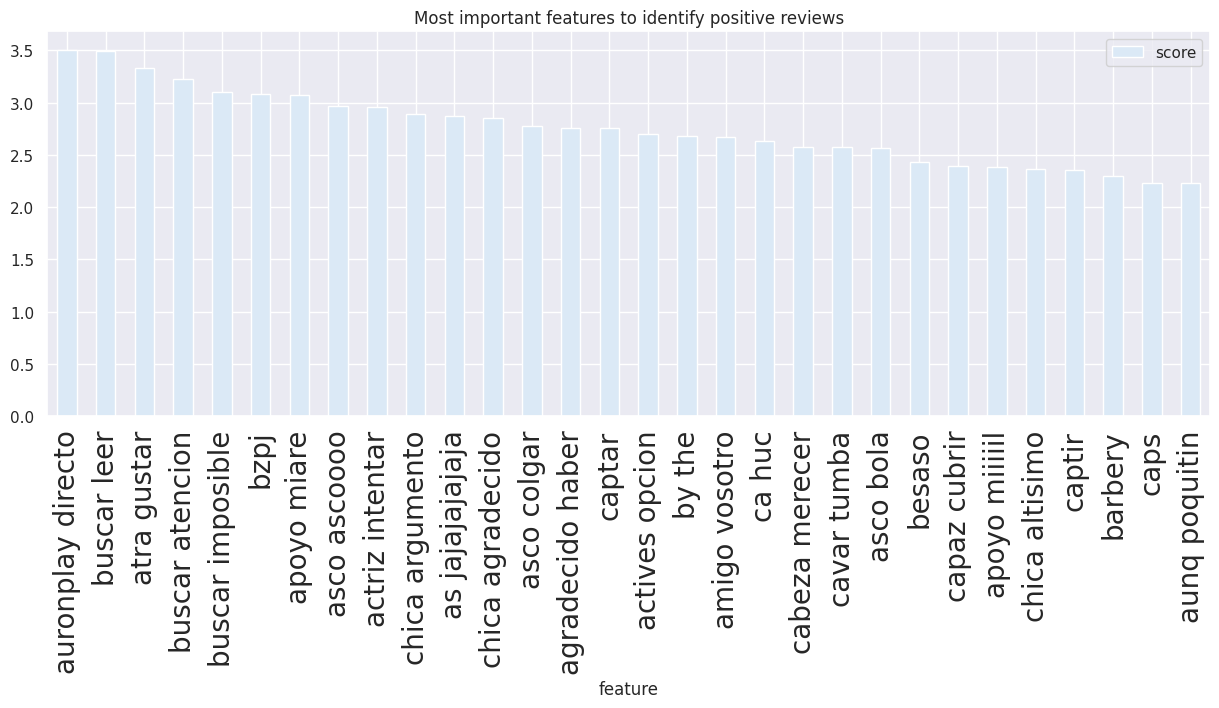

In [60]:
top_positive_features = pd.DataFrame(positive_features, columns=["feature", "score"])
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
top_positive_features.plot(x="feature", y="score", kind="bar", title="Most important features to identify positive reviews")

En la clase ofensiva, podemos ver que aparece la palabra **asco** en las features más importantes para clasificar esta clase, también **cavar tumba**. 

### MaxEnt Bigramas con TF-IDF y reducción de características a 5000
Utilizamos ahora bigramas TF-IDF con reducción de características con chi cuadrado.

Training model
Fitting 5 folds for each of 14 candidates, totalling 70 fits


CV-scores for each grid configuration
F1 Macro: 0.781 (+/-0.018) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.778 (+/-0.021) for params: {'C': 10, 'penalty': 'l1'}
F1 Macro: 0.775 (+/-0.021) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.768 (+/-0.014) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.763 (+/-0.019) for params: {'C': 1, 'penalty': 'l1'}
F1 Macro: 0.753 (+/-0.025) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.748 (+/-0.002) for params: {'C': 1000, 'penalty': 'l2'}
F1 Macro: 0.744 (+/-0.007) for params: {'C': 100, 'penalty': 'l1'}
F1 Macro: 0.744 (+/-0.019) for params: {'C': 0.001, 'penalty': 'l2'}
F1 Macro: 0.743 (+/-0.026) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.731 (+/-0.006) for params: {'C': 1000, 'penalty': 'l1'}
F1 Macro: 0.694 (+/-0.016) for params: {'C': 0.1, 'penalty': 'l1'}
F1 Macro: 0.464 (+/-0.000) for params: {'C': 0.001, 'penalty': 'l1'}
F1 Macro: 0.464 (+/-0.000) for params: {'C': 0.01, 'penalty': 'l1'}

Learning curve for th

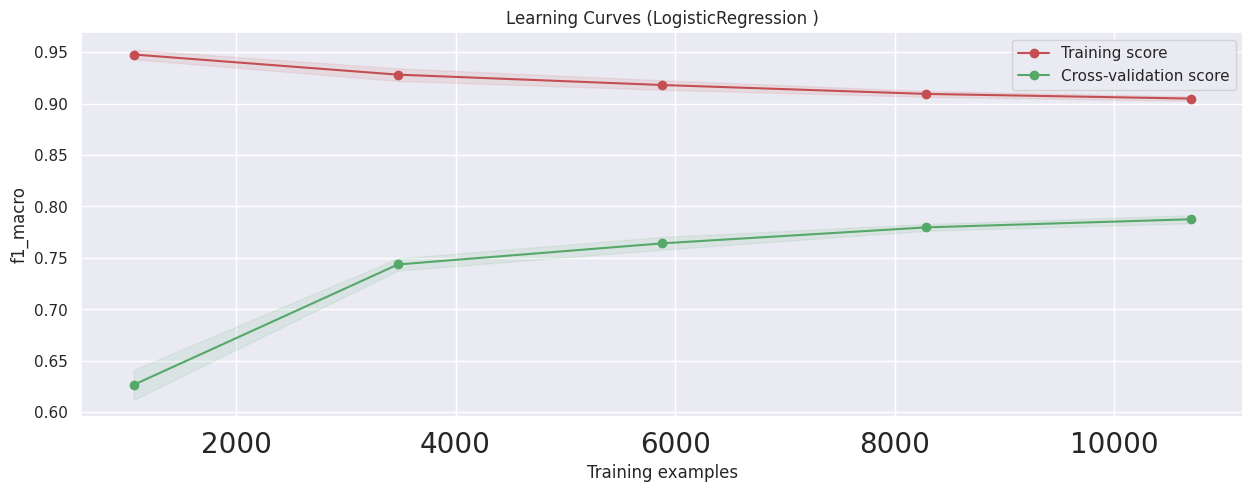

In [61]:
max_ent_bigram_tfidf_chi2_cls = train_and_evaluate_classifier(train_text_bigram_tfidf_chi2_features, encoded_y_train, LogisticRegression(solver='liblinear', class_weight='balanced'), max_ent_grid)

Predicting sentiment on the test set
Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.92      0.93      2889
   Offensive       0.56      0.67      0.61       453

    accuracy                           0.89      3342
   macro avg       0.76      0.79      0.77      3342
weighted avg       0.89      0.89      0.89      3342

Confusion matrix, without normalization


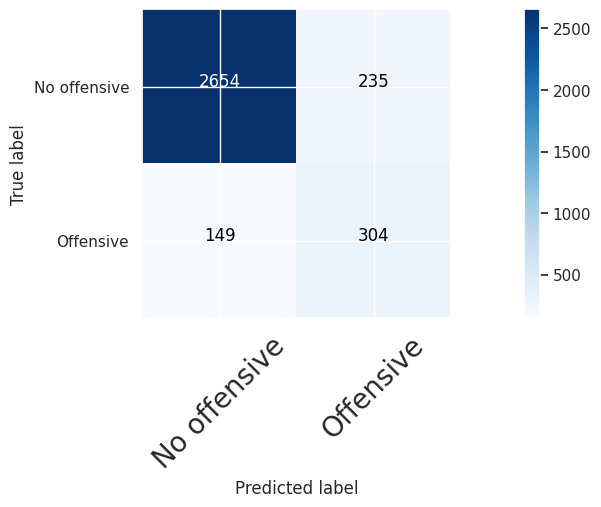

F1 Macro: 0.7727


In [62]:
print("Predicting sentiment on the test set")
y_pred = max_ent_bigram_tfidf_chi2_cls.predict(test_text_bigram_tfidf_chi2_features)

# Se deshace la transformación de las predicciones para obtener las predicciones como negativa o positiva
y_pred = le.inverse_transform(y_pred)

print("Classification Report")
print
print(classification_report(y_test, y_pred, target_names=target_labels))
cm = confusion_matrix(y_test, y_pred, labels=target_labels)
 
plot_confusion_matrix(cm, classes=target_labels)

print("F1 Macro: %.4f" % f1_score(y_test, y_pred, average='macro'))

Con reducción de características el algoritmo funciona prácticamente igual que antes.

## Resumen de Experimentos (2 classes)

| Representación + Algoritmo | F1 Macro |
|---|---|
| BoW (unigramas) + Naive Bayes | 0.6571 |
| BoW (unigramas) + SVM lineal | 0.7472 |
| BoW (unigramas) + Regresión Logística (MaxEnt) | 0.7574 |
| TF-IDF (unigramas) + Regresión Logística (MaxEnt) | 0.7710 |
| BoW (uni+bigramas) + Regresión Logística (MaxEnt) | 0.7768 |
| **TF-IDF (uni+bigramas) + Regresión Logística (MaxEnt)** | **0.7788** |
| TF-IDF (uni+bigramas) + Chi² (k=5000) + Regresión Logística (MaxEnt) | 0.7727 |

Creo que tenemos un buen baseline utilizando el algoritmo **MaxEnt** con representación TF-IDF (unigramas) y con bigramas.

Quiero mencionar que en esta práctica nos vamos a fijar en la métrica f1-macro porque es más representativa en un problema de clasificación
con un dataset desbalanceado. Por ejemplo, sería engañoso ver que tenemos un accuracy del 90% porque estamos clasificando correctamente muchas muestras no ofensivas, pero cometiendo errores en precisamente las que queremos detectar (ofensivas). Con f1-macro, cada clase contribuye de 
igual manera en el score independientemente del número de muestras. Por este motivo creo que es más adecuada a la hora de comparar modelos.

## Baselines con 4 clases

Hasta ahora hemos entrenado los baselines con las etiquetas binarias (Offensive / No offensive). Ahora vamos a repetir los mismos experimentos pero con las 4 clases originales del dataset: **NO** (No ofensivo), **NOM** (Ofensivo menor), **OFG** (Ofensivo grupal) y **OFP** (Ofensivo personal). Reutilizamos las mismas representaciones vectoriales y las mismas funciones de utilidad.

Codificamos las etiquetas esta vez con las 4 clases.

In [34]:
from sklearn import preprocessing

# Etiquetas originales de 4 clases
y_train_4c = dataset[0:len(training_set)][["label"]]
y_test_4c = dataset[len(training_set):len(dataset)][["label"]]

le_4c = preprocessing.LabelEncoder()
le_4c.fit(y_train_4c.label.values)
target_labels_4c = le_4c.classes_
encoded_y_train_4c = le_4c.transform(y_train_4c.label.values)

print(f"Clases: {target_labels_4c}")
print(f"Distribución en train: {dict(zip(*np.unique(encoded_y_train_4c, return_counts=True)))}")
print(encoded_y_train_4c[0:100])

Clases: ['NO' 'NOM' 'OFG' 'OFP']
Distribución en train: {np.int64(0): np.int64(10570), np.int64(1): np.int64(988), np.int64(2): np.int64(169), np.int64(3): np.int64(1641)}
[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 3 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 3 0 0 0 0 0 0
 1 3 1 0 0 0 1 0 0 0 0 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [35]:
def predict_and_report(classifier, X_test_feat, y_test_true, label_encoder, labels):
    """Predice, muestra classification report y confusion matrix."""
    y_pred = classifier.predict(X_test_feat)
    y_pred = label_encoder.inverse_transform(y_pred)

    print("Classification Report")
    print(classification_report(y_test_true, y_pred, target_names=labels))

    cm = confusion_matrix(y_test_true, y_pred, labels=labels)
    plot_confusion_matrix(cm, classes=labels)
    plot_confusion_matrix(cm, classes=labels, normalize=True, title='Confusion matrix (normalized)')

    f1 = f1_score(y_test_true, y_pred, average='macro')
    print("F1 Macro: %.4f" % f1)
    return f1

### Naive Bayes (4 clases)

Training model
Fitting 5 folds for each of 1 candidates, totalling 5 fits


CV-scores for each grid configuration
F1 Macro: 0.406 (+/-0.019) for params: {}

Learning curve for the best estimator


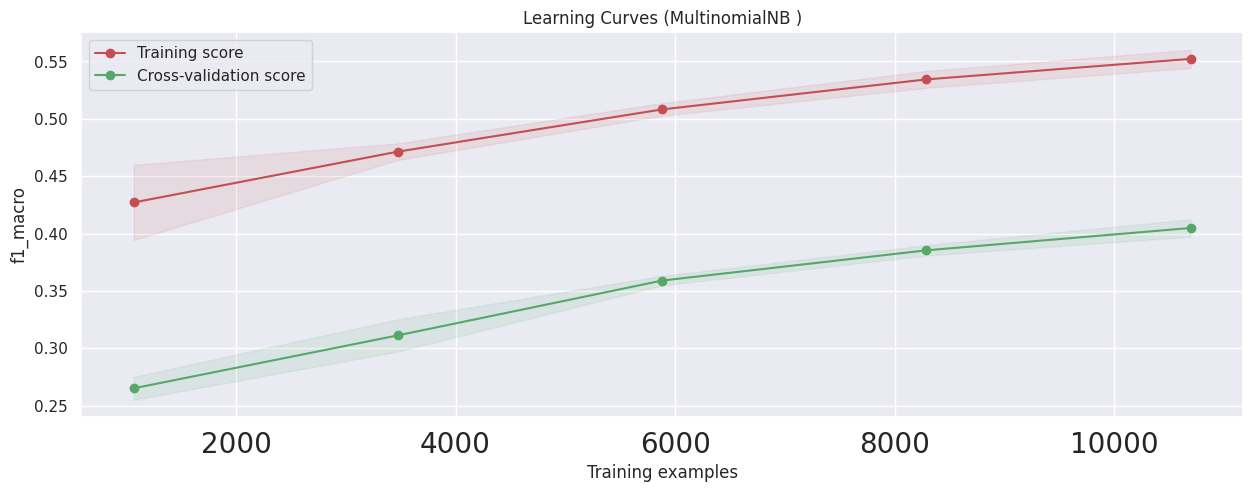

In [65]:
from sklearn.naive_bayes import MultinomialNB

nb_4c_cls = train_and_evaluate_classifier(train_features, encoded_y_train_4c, MultinomialNB(), {})

Classification Report
              precision    recall  f1-score   support

          NO       0.84      0.99      0.91      2642
         NOM       0.75      0.21      0.33       247
         OFG       0.00      0.00      0.00        43
         OFP       0.81      0.27      0.41       410

    accuracy                           0.83      3342
   macro avg       0.60      0.37      0.41      3342
weighted avg       0.82      0.83      0.79      3342

Confusion matrix, without normalization


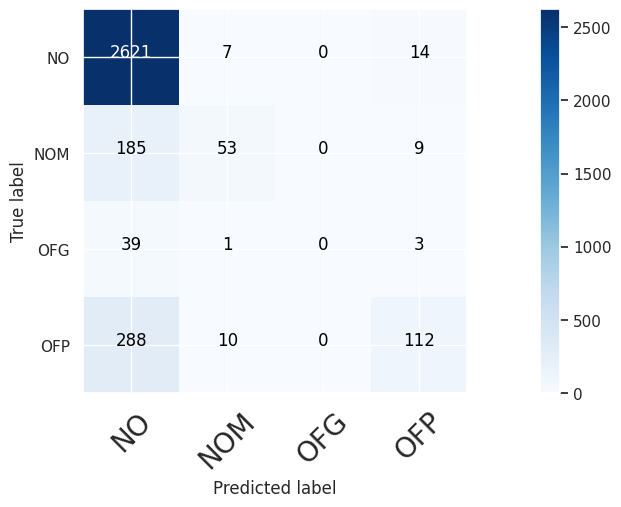

Normalized confusion matrix


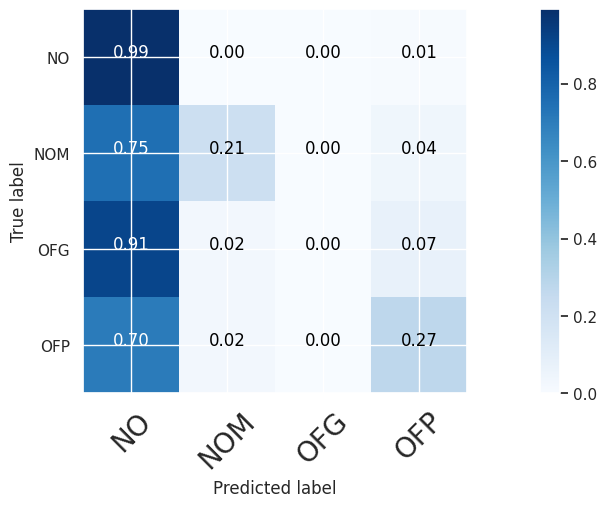

F1 Macro: 0.4124


In [66]:
nb_4c_f1 = predict_and_report(nb_4c_cls, test_features, y_test_4c.label.values, le_4c, target_labels_4c)

En la matriz de confusión se ven bastantes errores a la hora de clasificar las clases: NOM, OFG y OFP. Ninguna muestra de las clase
OFG se ha clasificado correctamente. El nivel de recall es muy bajo en estas tres clases.

### SVM (4 clases)

Como antes, a partir de ahora añadimos **class_weight='balanced'** porque los siguientes algoritmos sí lo soportan. Veremos si esto ayuda a aumentar el recall en las clases minoritarias.

Training model
Fitting 5 folds for each of 6 candidates, totalling 30 fits


CV-scores for each grid configuration
F1 Macro: 0.563 (+/-0.036) for params: {'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}
F1 Macro: 0.560 (+/-0.043) for params: {'C': 1, 'kernel': 'linear'}
F1 Macro: 0.539 (+/-0.040) for params: {'C': 10, 'kernel': 'linear'}
F1 Macro: 0.515 (+/-0.034) for params: {'C': 100, 'kernel': 'linear'}
F1 Macro: 0.513 (+/-0.018) for params: {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
F1 Macro: 0.319 (+/-0.010) for params: {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}

Learning curve for the best estimator


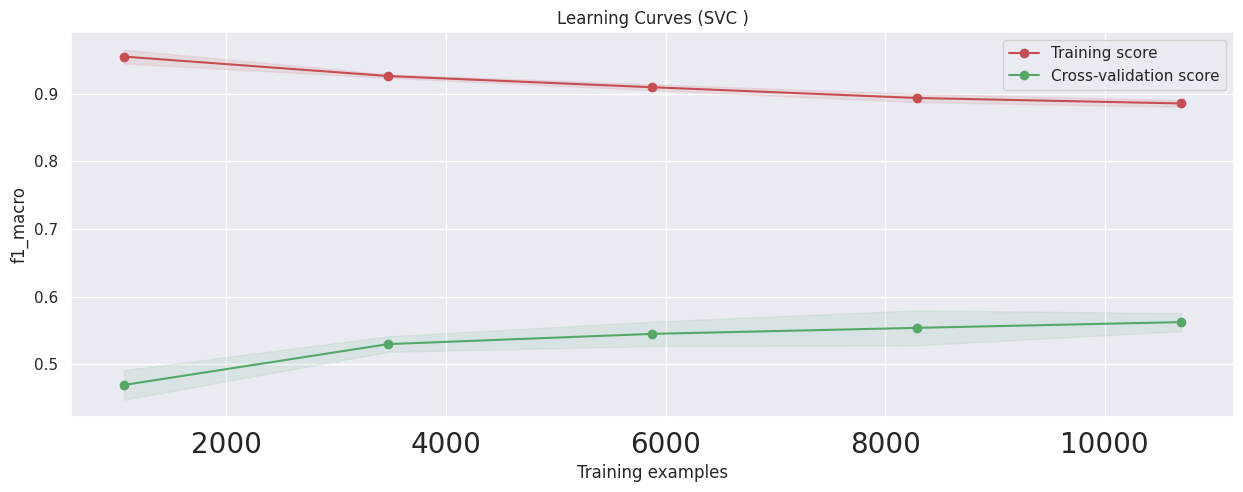

In [67]:
from sklearn.svm import SVC

svm_4c_grid = [
  {'C': [1, 10, 100], 'kernel': ['linear']},
  {'C': [10, 100, 1000], 'gamma': [0.0001], 'kernel': ['rbf']},
]

svm_4c_cls = train_and_evaluate_classifier(train_features, encoded_y_train_4c, SVC(class_weight='balanced'), svm_4c_grid)

Best estimator found by grid search:
SVC(C=1000, class_weight='balanced', gamma=0.0001)


Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.89      0.91      2642
         NOM       0.57      0.74      0.64       247
         OFG       0.07      0.05      0.05        43
         OFP       0.50      0.60      0.55       410

    accuracy                           0.83      3342
   macro avg       0.52      0.57      0.54      3342
weighted avg       0.85      0.83      0.84      3342

Confusion matrix, without normalization


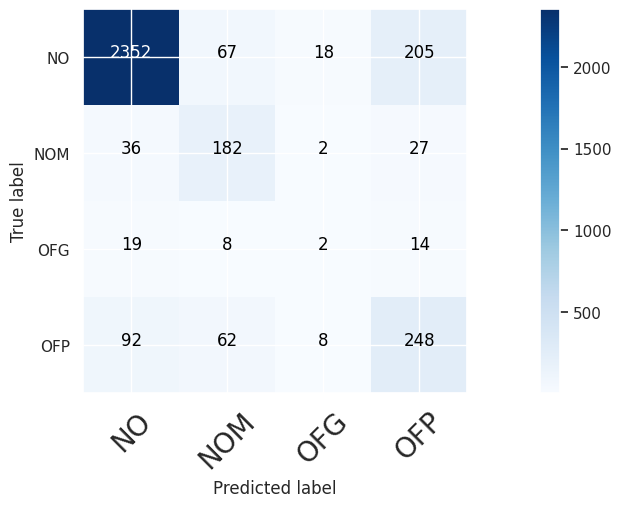

Normalized confusion matrix


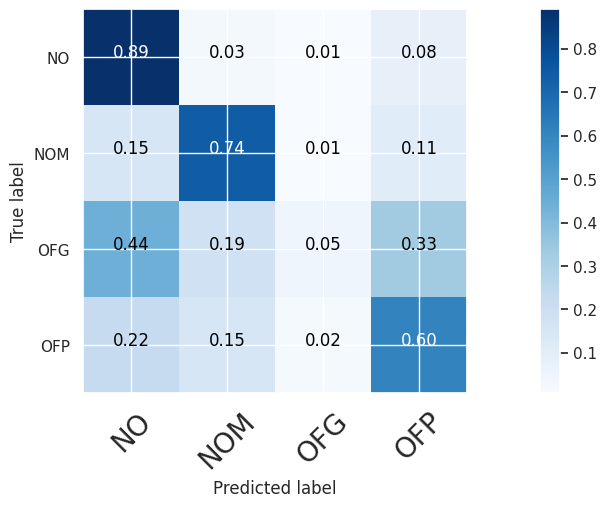

F1 Macro: 0.5404


In [68]:
print("Best estimator found by grid search:")
print(svm_4c_cls.best_estimator_)

svm_4c_f1 = predict_and_report(svm_4c_cls, test_features, y_test_4c.label.values, le_4c, target_labels_4c)

El recall en las clases minoritarias ha aumentado considerablemente. Se están identificando ahora mejor las clases NOM y OFP. Y 2 casos se han clasificado correctamente para OFG, pero se siguen comentiendo bastantes errores con esta clase. Esta es la clase que precisamente tiene menos muestras. 

### MaxEnt - BoW unigramas (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits


CV-scores for each grid configuration
F1 Macro: 0.564 (+/-0.031) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.559 (+/-0.017) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.547 (+/-0.027) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.533 (+/-0.027) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.515 (+/-0.020) for params: {'C': 1000, 'penalty': 'l2'}
F1 Macro: 0.494 (+/-0.012) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.422 (+/-0.013) for params: {'C': 0.001, 'penalty': 'l2'}

Learning curve for the best estimator


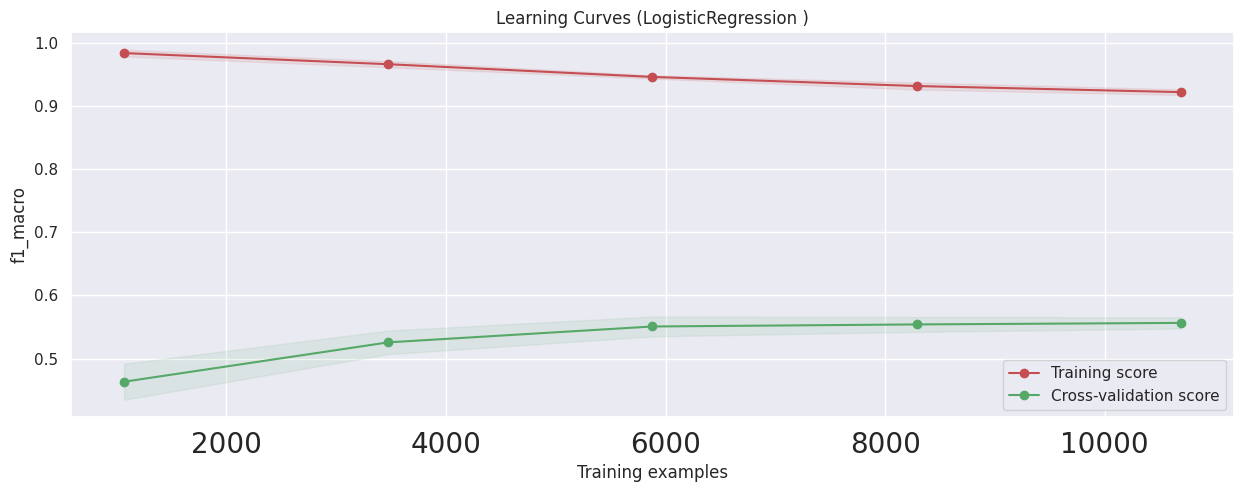

In [69]:
from sklearn.linear_model import LogisticRegression

max_ent_4c_grid = {'penalty': ['l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
max_ent_4c_cls = train_and_evaluate_classifier(
    train_features, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.90      0.92      2642
         NOM       0.61      0.71      0.66       247
         OFG       0.14      0.14      0.14        43
         OFP       0.54      0.63      0.58       410

    accuracy                           0.84      3342
   macro avg       0.56      0.60      0.57      3342
weighted avg       0.86      0.84      0.85      3342

Confusion matrix, without normalization


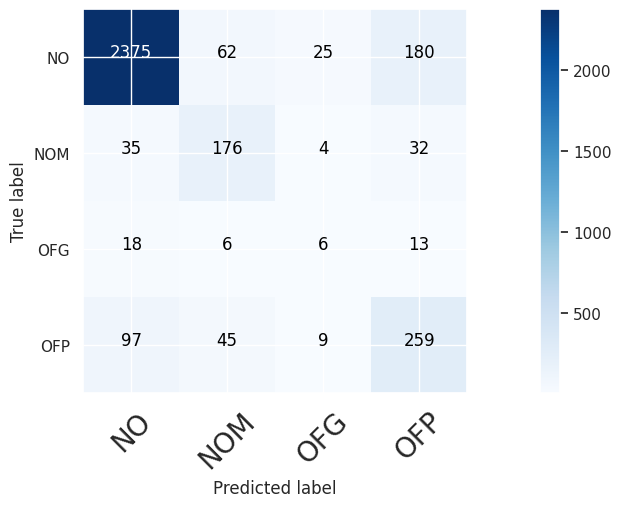

Normalized confusion matrix


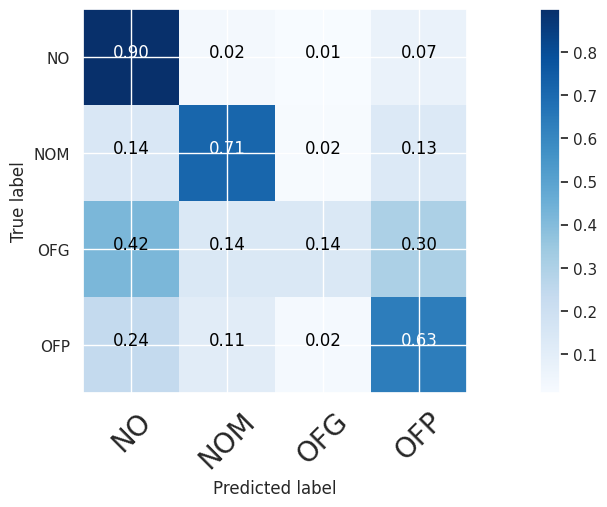

F1 Macro: 0.5733


In [70]:
print("Best estimator found by grid search:")
print(max_ent_4c_cls.best_estimator_)

maxent_bow_4c_f1 = predict_and_report(max_ent_4c_cls, test_features, y_test_4c.label.values, le_4c, target_labels_4c)

Obtenemos un f1-macro score algo mejor que con SVM. **MaxEnt** está funcionando mejor también para el problema con 4 clases.

### MaxEnt - TF-IDF (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits


CV-scores for each grid configuration
F1 Macro: 0.582 (+/-0.022) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.574 (+/-0.023) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.559 (+/-0.038) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.546 (+/-0.015) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.541 (+/-0.038) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.536 (+/-0.018) for params: {'C': 0.001, 'penalty': 'l2'}
F1 Macro: 0.509 (+/-0.035) for params: {'C': 1000, 'penalty': 'l2'}

Learning curve for the best estimator


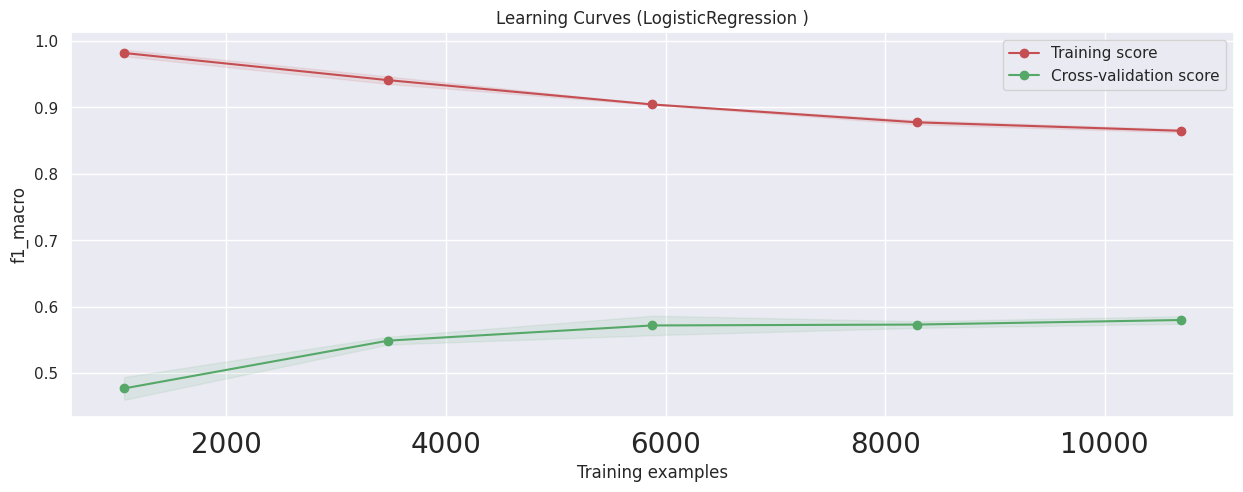

In [71]:
max_ent_tfidf_4c_cls = train_and_evaluate_classifier(
    train_text_tfidf_features, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.91      0.93      2642
         NOM       0.63      0.72      0.67       247
         OFG       0.15      0.19      0.17        43
         OFP       0.57      0.61      0.59       410

    accuracy                           0.85      3342
   macro avg       0.57      0.61      0.59      3342
weighted avg       0.86      0.85      0.86      3342

Confusion matrix, without normalization


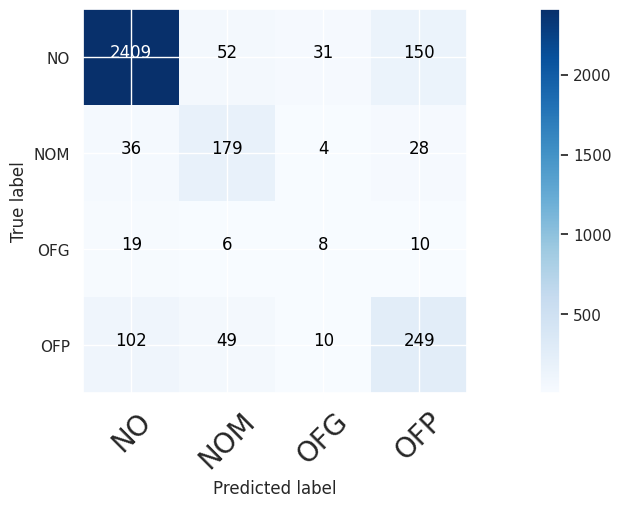

Normalized confusion matrix


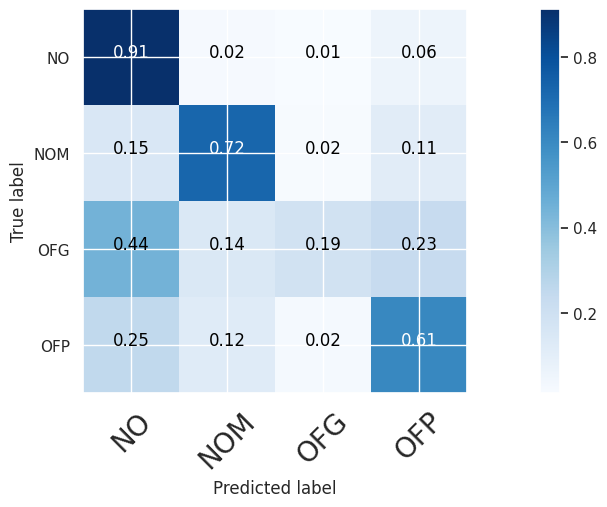

F1 Macro: 0.5879


In [72]:
print("Best estimator found by grid search:")
print(max_ent_tfidf_4c_cls.best_estimator_)

maxent_tfidf_4c_f1 = predict_and_report(max_ent_tfidf_4c_cls, test_text_tfidf_features, y_test_4c.label.values, le_4c, target_labels_4c)

Igual que con el problema de clasificación binaria, una representación TF-IDF funciona un poco mejor que una representación TF. Se obtiene un f1-macro score algo mejor para el mismo algoritmo.

### MaxEnt - Bigramas (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits


CV-scores for each grid configuration
F1 Macro: 0.587 (+/-0.031) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.587 (+/-0.044) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.582 (+/-0.048) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.571 (+/-0.045) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.547 (+/-0.020) for params: {'C': 1000, 'penalty': 'l2'}
F1 Macro: 0.511 (+/-0.012) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.428 (+/-0.013) for params: {'C': 0.001, 'penalty': 'l2'}

Learning curve for the best estimator


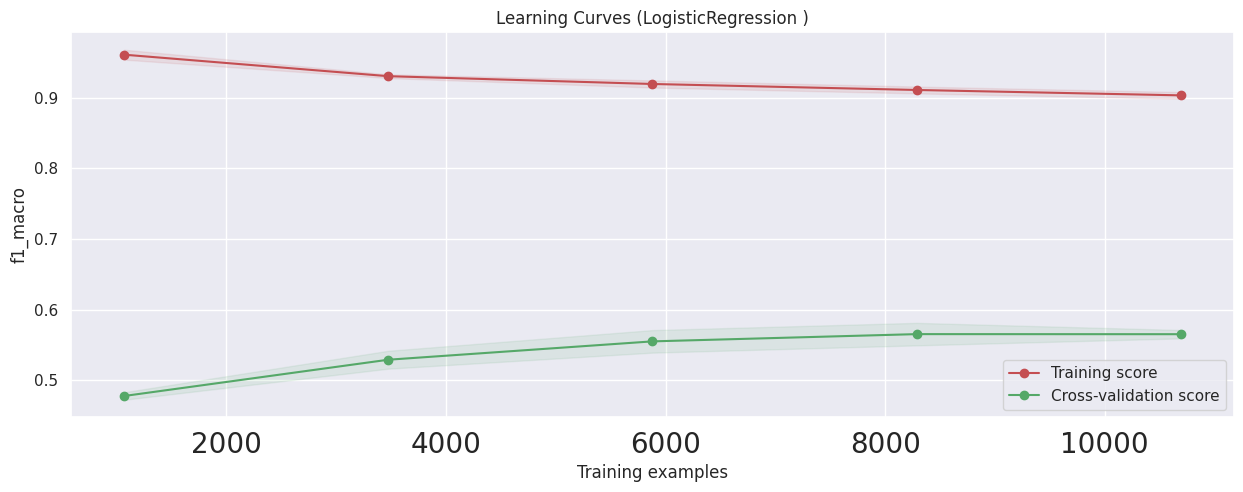

In [73]:
max_ent_bigram_4c_cls = train_and_evaluate_classifier(
    train_bigram_features, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.90      0.92      2642
         NOM       0.63      0.74      0.68       247
         OFG       0.19      0.12      0.14        43
         OFP       0.52      0.63      0.57       410

    accuracy                           0.85      3342
   macro avg       0.57      0.60      0.58      3342
weighted avg       0.86      0.85      0.85      3342

Confusion matrix, without normalization


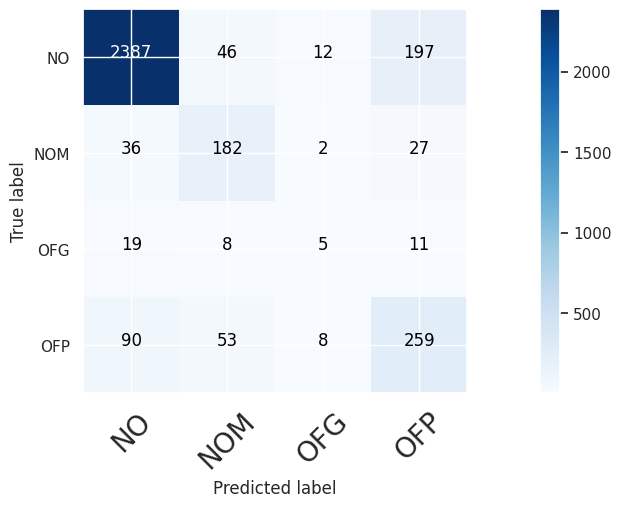

Normalized confusion matrix


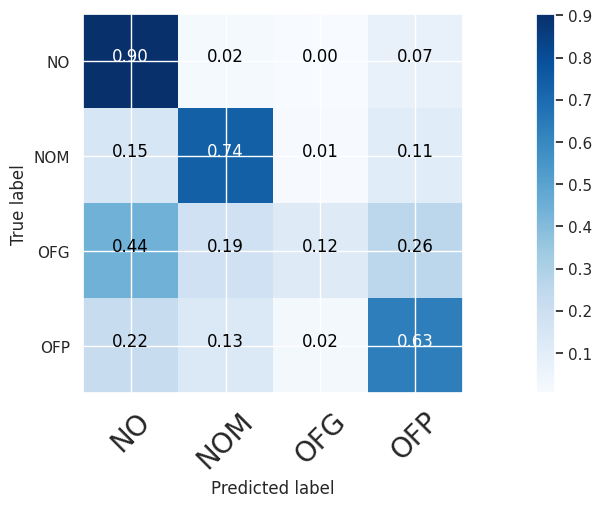

F1 Macro: 0.5794


In [74]:
print("Best estimator found by grid search:")
print(max_ent_bigram_4c_cls.best_estimator_)

maxent_bigram_4c_f1 = predict_and_report(max_ent_bigram_4c_cls, test_bigram_features, y_test_4c.label.values, le_4c, target_labels_4c)

En este caso se obtiene un f1-macro score muy similar.

### MaxEnt - Bigramas con TF-IDF (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits


CV-scores for each grid configuration
F1 Macro: 0.583 (+/-0.028) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.578 (+/-0.020) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.558 (+/-0.019) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.552 (+/-0.024) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.551 (+/-0.016) for params: {'C': 0.001, 'penalty': 'l2'}
F1 Macro: 0.528 (+/-0.028) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.521 (+/-0.032) for params: {'C': 1000, 'penalty': 'l2'}

Learning curve for the best estimator


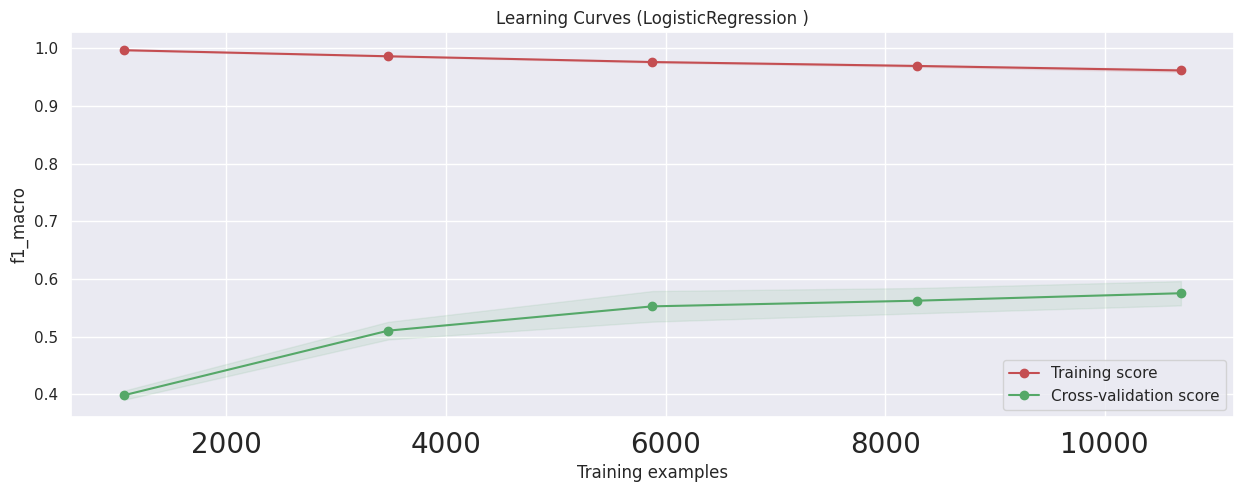

In [75]:
max_ent_bigram_tfidf_4c_cls = train_and_evaluate_classifier(
    train_text_bigram_tfidf_features, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.93      0.93      0.93      2642
         NOM       0.63      0.73      0.67       247
         OFG       0.17      0.14      0.15        43
         OFP       0.61      0.58      0.60       410

    accuracy                           0.86      3342
   macro avg       0.58      0.60      0.59      3342
weighted avg       0.86      0.86      0.86      3342

Confusion matrix, without normalization


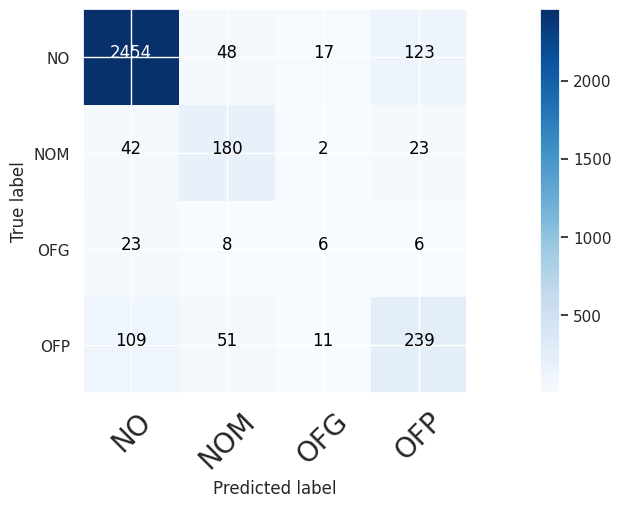

Normalized confusion matrix


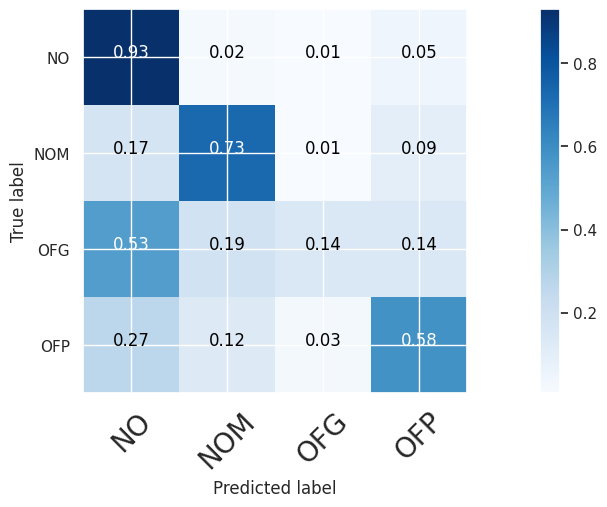

F1 Macro: 0.5885


In [76]:
print("Best estimator found by grid search:")
print(max_ent_bigram_tfidf_4c_cls.best_estimator_)

maxent_bigram_tfidf_4c_f1 = predict_and_report(max_ent_bigram_tfidf_4c_cls, test_text_bigram_tfidf_features, y_test_4c.label.values, le_4c, target_labels_4c)

Este es el mejor resultado hasta ahora para 4 clases.

### MaxEnt - Bigramas con TF-IDF y Chi² k=5000 (4 clases)

Training model
Fitting 5 folds for each of 7 candidates, totalling 35 fits


CV-scores for each grid configuration
F1 Macro: 0.592 (+/-0.032) for params: {'C': 1, 'penalty': 'l2'}
F1 Macro: 0.582 (+/-0.022) for params: {'C': 0.1, 'penalty': 'l2'}
F1 Macro: 0.564 (+/-0.025) for params: {'C': 10, 'penalty': 'l2'}
F1 Macro: 0.551 (+/-0.021) for params: {'C': 0.01, 'penalty': 'l2'}
F1 Macro: 0.543 (+/-0.018) for params: {'C': 0.001, 'penalty': 'l2'}
F1 Macro: 0.537 (+/-0.030) for params: {'C': 100, 'penalty': 'l2'}
F1 Macro: 0.516 (+/-0.024) for params: {'C': 1000, 'penalty': 'l2'}

Learning curve for the best estimator


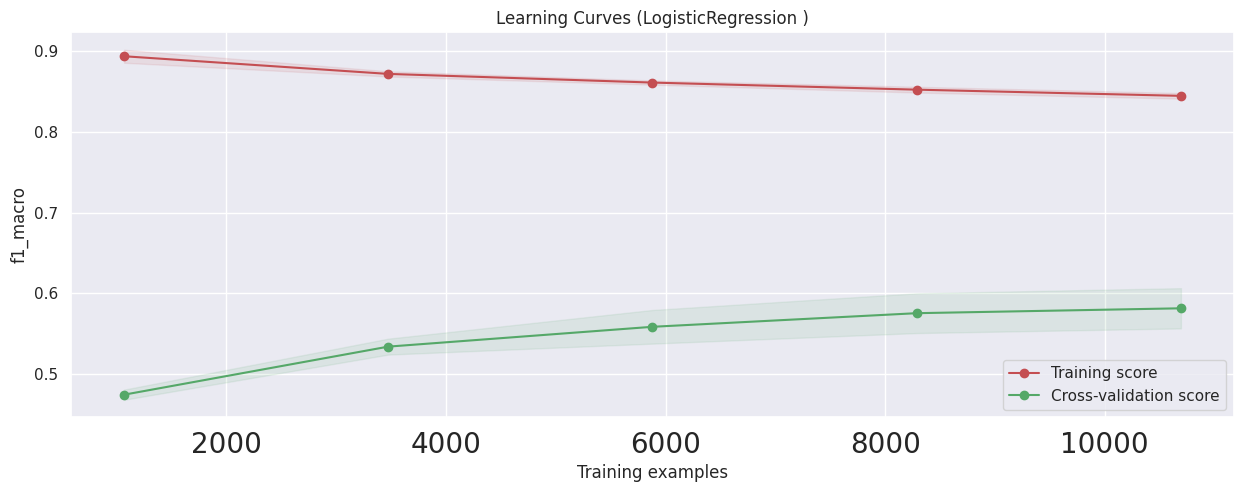

In [77]:
# Recomputamos chi2 con las 4 clases porque la selección de features depende de las etiquetas
bigram_tfidf_chi2_vect_4c = TfidfVectorizer(norm="l2", ngram_range=(1,2))
train_text_bigram_tfidf_chi2_4c = bigram_tfidf_chi2_vect_4c.fit_transform(X_train.clean_comment)
test_text_bigram_tfidf_chi2_4c = bigram_tfidf_chi2_vect_4c.transform(X_test.clean_comment)

ch2_4c = SelectKBest(chi2, k=5000)
train_text_bigram_tfidf_chi2_4c = ch2_4c.fit_transform(train_text_bigram_tfidf_chi2_4c, y_train_4c.label.values)
test_text_bigram_tfidf_chi2_4c = ch2_4c.transform(test_text_bigram_tfidf_chi2_4c)

max_ent_bigram_tfidf_chi2_4c_cls = train_and_evaluate_classifier(
    train_text_bigram_tfidf_chi2_4c, encoded_y_train_4c,
    LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced'),
    max_ent_4c_grid
)

Best estimator found by grid search:
LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l2')
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.90      0.92      2642
         NOM       0.61      0.74      0.67       247
         OFG       0.13      0.14      0.13        43
         OFP       0.53      0.62      0.57       410

    accuracy                           0.84      3342
   macro avg       0.55      0.60      0.57      3342
weighted avg       0.86      0.84      0.85      3342

Confusion matrix, without normalization


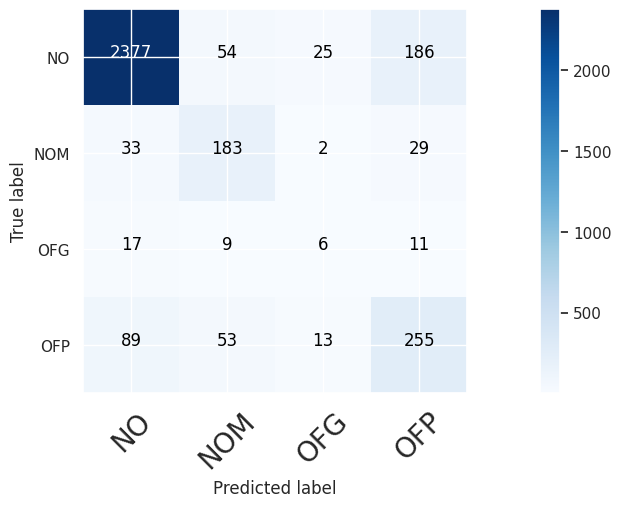

Normalized confusion matrix


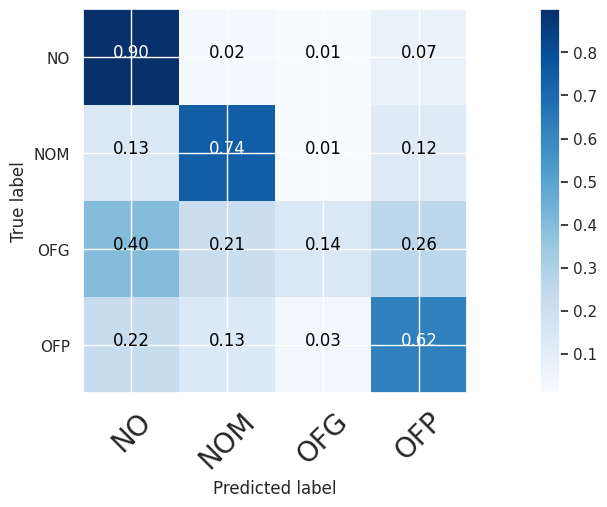

F1 Macro: 0.5748


In [78]:
print("Best estimator found by grid search:")
print(max_ent_bigram_tfidf_chi2_4c_cls.best_estimator_)

maxent_chi2_4c_f1 = predict_and_report(max_ent_bigram_tfidf_chi2_4c_cls, test_text_bigram_tfidf_chi2_4c, y_test_4c.label.values, le_4c, target_labels_4c)

Con reducción de características se obtiene un resultado similar.

## Resumen de Experimentos (4 clases)

| Representación + Algoritmo | F1 Macro (4 clases) |
|---|---|
| BoW (unigramas) + Naive Bayes | 0.4124 |
| BoW (unigramas) + SVM lineal | 0.5404 |
| BoW (unigramas) + Regresión Logística (MaxEnt) | 0.5733 |
| TF-IDF (unigramas) + Regresión Logística (MaxEnt) | 0.5879 |
| BoW (uni+bigramas) + Regresión Logística (MaxEnt) | 0.5794 |
| **TF-IDF (uni+bigramas) + Regresión Logística (MaxEnt)** | **0.5885** |
| TF-IDF (uni+bigramas) + Chi² (k=5000) + Regresión Logística (MaxEnt) | 0.5748 |

Estos valores de f1-macro con algorimos de Machine Learning clásico nos servirán como baseline.
En estos experimentos identificamos que la clase **OFG** es especialmente difícil de clasificar correctamente. Esta clase
es precisamente la que menos muestras tienen en el dataset de entrenamiento. 

# Algoritmos de aprendizaje profundo
En los siguientes apartados vamos a implementar algoritmos de aprendizaje profundo.
Vamos a utilizar las librerías **Pytorch** y **transformers** de **Hugging Face**.

He clasificado los apartados siguiendo también los temas estudiados (MLP, CNN, Modelos Contextuales y Large Language Models).

## Utilidades

In [42]:
# Importamos capas densas, capas de embeddings y capas para el aplanaEl hecho de que de una manera se pueda explicar el resultado del modelo ayuda do de dimensiones
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [43]:
def print_model_info(model):
    print("=" * 80)
    print("MODEL ARCHITECTURE")
    print("=" * 80)
    print(model)
    print()
    
    print("=" * 80)
    print("MODEL PARAMETERS")
    print("=" * 80)
    
    total_params = 0
    trainable_params = 0
    
    print(f"{'Layer':<40} {'Parameters':<15} {'Shape':<20}")
    print("-" * 80)
    
    for name, param in model.named_parameters():
        num_params = param.numel()
        total_params += num_params
        if param.requires_grad:
            trainable_params += num_params
        
        print(f"{name:<40} {num_params:<15,} {str(list(param.shape)):<20}")
    
    print("-" * 80)
    print(f"{'Total Parameters:':<40} {total_params:,}")
    print(f"{'Trainable Parameters:':<40} {trainable_params:,}")
    print(f"{'Non-trainable Parameters:':<40} {(total_params - trainable_params):,}")
    
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    size_mb = (param_size + buffer_size) / 1024**2
    
    print(f"{'Model Size:':<40} {size_mb:.2f} MB")
    print("=" * 80)

In [44]:
# Con esta función podremos ver cómo evoluciona el entrenamiento y la validación de los modelos.

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Clase similar a la estructura que se obtiene al entrenar los modelos en tf.keras
class History:
    def __init__(self):
        self.history = {
            'loss': [],
            'acc': [],
            'val_loss': [],
            'val_acc': []
        }

def plot_history(history, metric='acc'):
    acc = history.history[metric]
    val_acc = history.history[f'val_{metric}']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

In [45]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np

def _is_binary_criterion(criterion):
    """Binary criteria expect float targets of shape [N, 1]."""
    return (
        isinstance(criterion, (nn.BCELoss, nn.BCEWithLogitsLoss))
        or getattr(criterion, 'expects_float_targets', False)
    )

def train_pytorch_model(
    model,
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    optimizer=None,
    criterion=None,
    device=None,
    patience=5,
    scheduler=None
):    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    # Se mueve el modelo al device (CPU o GPU)
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    is_text_data = isinstance(X_train, torch.Tensor) and X_train.dtype == torch.long

    if hasattr(X_train, 'toarray'):
        X_train = X_train.toarray()

    if not isinstance(X_train, torch.Tensor):
        if is_text_data or X_train.dtype in [np.int32, np.int64]:
            X_train = torch.LongTensor(np.array(X_train))
        else:
            X_train = torch.FloatTensor(np.array(X_train).astype('float32'))

    if _is_binary_criterion(criterion):
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.FloatTensor(np.array(y_train).astype('float32'))
    elif isinstance(criterion, nn.CrossEntropyLoss):
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.LongTensor(np.array(y_train))
    else:
        if not isinstance(y_train, torch.Tensor):
            y_train = torch.FloatTensor(np.array(y_train).astype('float32'))

    # Train/validation split
    if validation_split > 0:
        X_numpy = X_train.numpy() if isinstance(X_train, torch.Tensor) else X_train
        y_numpy = y_train.numpy() if isinstance(y_train, torch.Tensor) else y_train
        
        X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
            X_numpy, y_numpy, test_size=validation_split, random_state=42
        )

        if X_train.dtype == torch.long:
            X_train_split = torch.LongTensor(X_train_split)
            X_val_split = torch.LongTensor(X_val_split)
        else:
            X_train_split = torch.FloatTensor(X_train_split)
            X_val_split = torch.FloatTensor(X_val_split)

        if y_train.dtype == torch.long:
            y_train_split = torch.LongTensor(y_train_split)
            y_val_split = torch.LongTensor(y_val_split)
        else:
            y_train_split = torch.FloatTensor(y_train_split)
            y_val_split = torch.FloatTensor(y_val_split)
    else:
        X_train_split, y_train_split = X_train, y_train
        X_val_split, y_val_split = None, None

    if _is_binary_criterion(criterion) and y_train_split.dim() == 1:
        y_train_split = y_train_split.unsqueeze(1)
        if validation_split > 0:
            y_val_split = y_val_split.unsqueeze(1)

    # Los datasets son directamente TensorDataset de Pytorch
    train_dataset = TensorDataset(X_train_split, y_train_split)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    if validation_split > 0:
        val_dataset = TensorDataset(X_val_split, y_val_split)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Inicializar el histórico
    history = History()

    # Rutina de entrenamiento
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            # Backward pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            if isinstance(criterion, nn.CrossEntropyLoss):
                predicted = torch.argmax(outputs, dim=1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()
            else:
                predicted = (outputs > 0.5).float()
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y).sum().item()

        # Métricas de entrenamiento: Train loss, train accuracy
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = train_correct / train_total
        history.history['loss'].append(epoch_train_loss)
        history.history['acc'].append(epoch_train_acc)

        if validation_split > 0:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            # Modelo en modo inferencia sin guardar los gradientes
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()

                    if isinstance(criterion, nn.CrossEntropyLoss):
                        predicted = torch.argmax(outputs, dim=1)
                    else:
                        predicted = (outputs > 0.5).float()

                    val_total += batch_y.size(0)
                    val_correct += (predicted == batch_y).sum().item()

            epoch_val_loss = val_loss / len(val_loader)
            epoch_val_acc = val_correct / val_total
            history.history['val_loss'].append(epoch_val_loss)
            history.history['val_acc'].append(epoch_val_acc)

            if scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(epoch_val_loss)
                else:
                    scheduler.step()
                print(f"Stepping learning rate to value: {scheduler.get_lr()}")

            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                patience_counter = 0
                # Guardar mejor modelo
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
                print(f" (patience: {patience_counter}/{patience})")

            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                # Restaurar mejor modelo
                model.load_state_dict(best_model_state)
                break
        else:
            history.history['val_loss'].append(0.0)
            history.history['val_acc'].append(0.0)

        if validation_split > 0:
            print(f'Epoch {epoch+1}/{epochs} - '
                  f'loss: {epoch_train_loss:.4f} - '
                  f'acc: {epoch_train_acc:.4f} - '
                  f'val_loss: {epoch_val_loss:.4f} - '
                  f'val_acc: {epoch_val_acc:.4f}')
        else:
            print(f'Epoch {epoch+1}/{epochs} - '
                  f'loss: {epoch_train_loss:.4f} - '
                  f'acc: {epoch_train_acc:.4f}')

    return history


In [46]:
def evaluate_pytorch_model(model, X_test, y_test, le=None, target_labels=None, device=None, batch_size=32):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval()

    if hasattr(X_test, 'toarray'):
        X_test_array = X_test.toarray().astype('float32')
        X_test_tensor = torch.FloatTensor(X_test_array)
    elif isinstance(X_test, torch.Tensor):
        X_test_tensor = X_test.cpu()
    else:
        X_test_array = np.array(X_test)
        if X_test_array.dtype in [np.int32, np.int64]:
            X_test_tensor = torch.LongTensor(X_test_array)
        else:
            X_test_tensor = torch.FloatTensor(X_test_array.astype('float32'))

    if isinstance(y_test, torch.Tensor):
        y_test = y_test.cpu().numpy()
    else:
        y_test = np.array(y_test)

    from torch.utils.data import TensorDataset, DataLoader

    dataset = TensorDataset(X_test_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_predictions = []

    with torch.no_grad():
        # En algunos entrenamientos con CNN, pasar como en la prácica anterior un batch del tamaño del test set
        # hacia que la GPU se quedara sin memoria, por eso paso un mini batch. Los resultados de 
        # evaluación deberían ser los mismos.
        for batch in dataloader:
            batch_X = batch[0].to(device)
            outputs = model(batch_X).cpu()
            
            if outputs.shape[1] == 1:
                # Si la salida es tamaño 1, como mencionado anteriormente, se usa un threshold
                # en 0.5 para diferenciar entre una clase u otra
                batch_pred = (outputs.numpy() > 0.5).astype(int).flatten()
            else:
                # Si la salida es de tamaño > 1, entonces la clase escogida
                # es aquella que tenga la probabilidad más alta (por eso argmax)
                batch_pred = torch.argmax(outputs, dim=1).numpy()
            
            all_predictions.append(batch_pred)
    
    y_pred = np.concatenate(all_predictions)
    
    if le is not None:
        y_pred_labels = le.inverse_transform(y_pred)
        if y_test.dtype in [np.int32, np.int64]:
            y_test_labels = le.inverse_transform(y_test)
        else:
            y_test_labels = y_test
    else:
        y_pred_labels = y_pred
        y_test_labels = y_test
    
    if target_labels is None:
        unique_labels = np.unique(np.concatenate([y_test_labels, y_pred_labels]))
        target_labels = sorted(unique_labels)
    
    print("Classification Report")
    print(classification_report(y_test_labels, y_pred_labels, target_names=target_labels))
    cm = confusion_matrix(y_test_labels, y_pred_labels, labels=target_labels)
    plot_confusion_matrix(cm, classes=target_labels)
    print("F1 Macro: %.4f" % f1_score(y_test_labels, y_pred_labels, average='macro'))
    
    return y_pred_labels

In [47]:
#Número de épocas (iteraciones globales)
epochs = 40
#Dimensión de la capa de embeddings
emb_dim = 50
#Tamaño de batch (lote)
batch_size = 32
#Número de palabras tenidas en cuenta (reducción del vocabulario)
n_most_common_words = 50000
#Máxima longitud del documento
max_len = 512

## Entrenamiento de modelos MLP
Vamos a comenzar con el entrenamiento de un modelo basado en redes neuronales Fully Connected con una representación TF-IDF.

In [49]:
Y_train = encoded_y_train  # Shape: (n_samples,)
Y_test = le.transform(y_test.values)

print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

print(Y_train[0:10])

Y_train shape: (13368,)
Y_test shape: (3342,)
[0 0 0 0 0 0 0 0 0 0]


### Standard MLP

En este caso, la salida es una única neurona. La activación de salida puede estar entre 0 y 1. Si la salida es mayor de 0.5 corresponderá con una clase y si es menor, con la otra clase.

In [43]:
class BinaryClassifierMLP(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifierMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        # Single output neuron
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = F.softmax(x, dim=1)

        x = self.fc2(x)
        x = F.softmax(x, dim=1)
        
        x = self.fc3(x)
        x = F.sigmoid(x)

        return x

In [44]:
input_dim = train_text_tfidf_features.shape[1]
model = BinaryClassifierMLP(input_dim)
model = model.to(device)
print_model_info(model)

MODEL ARCHITECTURE
BinaryClassifierMLP(
  (fc1): Linear(in_features=22969, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               2,940,032       [128, 22969]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:                        2,948,4

En estos entrenamientos vamos a usar siempre la técnica de **early stopping**. Se parará el entrenamiento cuando se detecte que **val_loss** no crece durante un determinado número de epochs **patience**.

Epoch 1/40 - loss: 0.5734 - acc: 0.8658 - val_loss: 0.5035 - val_acc: 0.8598
Epoch 2/40 - loss: 0.4579 - acc: 0.8658 - val_loss: 0.4343 - val_acc: 0.8598
Epoch 3/40 - loss: 0.4121 - acc: 0.8658 - val_loss: 0.4109 - val_acc: 0.8598
Epoch 4/40 - loss: 0.3961 - acc: 0.8658 - val_loss: 0.4037 - val_acc: 0.8598
Epoch 5/40 - loss: 0.3857 - acc: 0.8658 - val_loss: 0.3897 - val_acc: 0.8598
Epoch 6/40 - loss: 0.3518 - acc: 0.8658 - val_loss: 0.3553 - val_acc: 0.8598
Epoch 7/40 - loss: 0.2963 - acc: 0.8658 - val_loss: 0.3209 - val_acc: 0.8598
Epoch 8/40 - loss: 0.2417 - acc: 0.8658 - val_loss: 0.2991 - val_acc: 0.8598
Epoch 9/40 - loss: 0.1996 - acc: 0.9025 - val_loss: 0.2889 - val_acc: 0.9001
Epoch 10/40 - loss: 0.1699 - acc: 0.9462 - val_loss: 0.2864 - val_acc: 0.9080
 (patience: 1/5)
Epoch 11/40 - loss: 0.1457 - acc: 0.9553 - val_loss: 0.2874 - val_acc: 0.9016
 (patience: 2/5)
Epoch 12/40 - loss: 0.1283 - acc: 0.9618 - val_loss: 0.2915 - val_acc: 0.8987
 (patience: 3/5)
Epoch 13/40 - loss: 0.

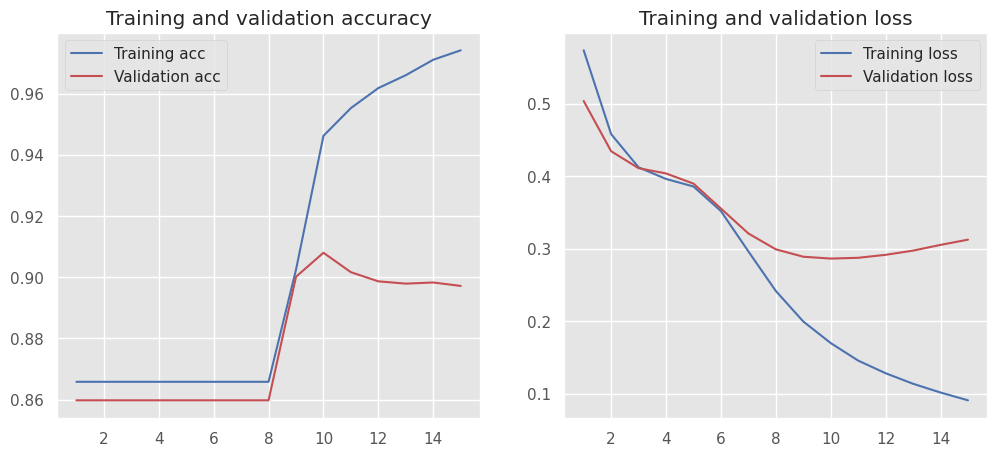

In [45]:
criterion = nn.BCELoss()
history = train_pytorch_model(
  model,
  train_text_tfidf_features,
  Y_train,
  epochs=40, batch_size=32, validation_split=0.2,
  optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
  criterion=criterion)
plot_history(history)

Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.96      0.94      2889
   Offensive       0.65      0.53      0.58       453

    accuracy                           0.90      3342
   macro avg       0.79      0.74      0.76      3342
weighted avg       0.89      0.90      0.89      3342

Confusion matrix, without normalization


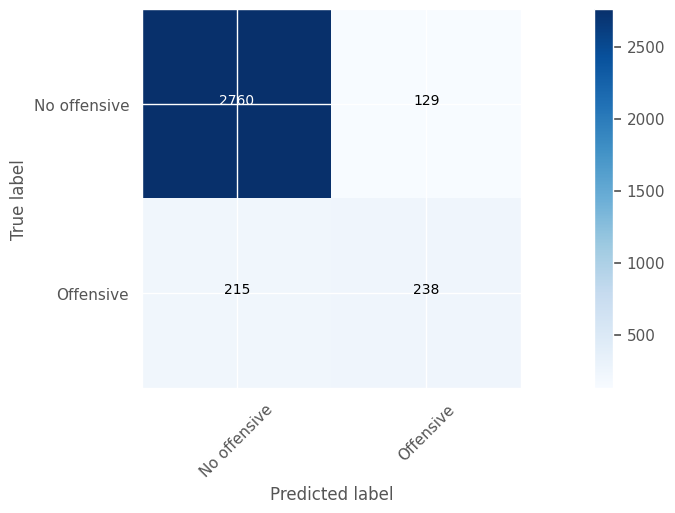

F1 Macro: 0.7609


In [46]:
y_pred = evaluate_pytorch_model(model, test_text_tfidf_features, Y_test, le, target_labels, device)

Se obtiene un resultado cercano al baseline. En la curva de aprendizaje se ve que train loss siempre decrece. Validation loss comienza decreciendo hasta llegar a la epoch 10 donde empieza a crecer. Esto se detecta con la técnica de early stopping y se para el entrenamiento para no guardar un modelo que haga mucho overfitting (train loss pequeño, pero validation loss grande, el modelo funciona bien con datos de entrenamiento pero no generaliza en validación).

Con datos de test tenemos un f1-macro cercano a los baselines **0.7609**.

### MLP con class-weighted loss (BCEWithLogitsLoss)

Como el dataset no está balanceado, es decir, hay muchas más muestras de una clase que de otra, quiero explorar alguna
técnica que ayude con este problema. En el siguiente experimento vamos a usar la función de pérdidas **BCEWithLogitsLoss**
la cual permite añadir un peso a cada clase. Este peso será proporcional al número de muestras de cada clase en el dataset
de entrenamiento. La idea es penalizar más en el coste errores cometidos en la clase minoritaria.

Está función de pérdidas tiene una sigmoide, entonces, tener una sigmoide en la salida del modelo es redundante. Por eso
implemento otro modelo cuya salida son directamente los logits de la última capa fully connected.

In [47]:
class BinaryClassifierMLPLogits(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifierMLPLogits, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.softmax(self.fc1(x), dim=1)
        x = F.softmax(self.fc2(x), dim=1)
        return self.fc3(x)

# pos_weight = número muestras negativas / número muestras positivas
n_neg = (Y_train == 0).sum()
n_pos = (Y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"Clase 0 (No offensive): {n_neg} | Clase 1 (Offensive): {n_pos} | pos_weight: {pos_weight.item():.2f}")

input_dim = train_text_tfidf_features.shape[1]
model_weighted = BinaryClassifierMLPLogits(input_dim).to(device)
print_model_info(model_weighted)

Clase 0 (No offensive): 11558 | Clase 1 (Offensive): 1810 | pos_weight: 6.39
MODEL ARCHITECTURE
BinaryClassifierMLPLogits(
  (fc1): Linear(in_features=22969, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               2,940,032       [128, 22969]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
----------------------------------------------

Epoch 1/40 - loss: 1.1930 - acc: 0.8658 - val_loss: 1.2174 - val_acc: 0.8598
Epoch 2/40 - loss: 1.1927 - acc: 0.8658 - val_loss: 1.2170 - val_acc: 0.8598
Epoch 3/40 - loss: 1.1931 - acc: 0.8658 - val_loss: 1.2109 - val_acc: 0.8598
Epoch 4/40 - loss: 1.1643 - acc: 0.8658 - val_loss: 1.1651 - val_acc: 0.8598
Epoch 5/40 - loss: 1.0521 - acc: 0.8663 - val_loss: 1.0589 - val_acc: 0.8661
Epoch 6/40 - loss: 0.8782 - acc: 0.9150 - val_loss: 0.9564 - val_acc: 0.9039
Epoch 7/40 - loss: 0.7052 - acc: 0.9391 - val_loss: 0.8858 - val_acc: 0.8904
Epoch 8/40 - loss: 0.5525 - acc: 0.9389 - val_loss: 0.8614 - val_acc: 0.8856
 (patience: 1/5)
Epoch 9/40 - loss: 0.4362 - acc: 0.9451 - val_loss: 0.8763 - val_acc: 0.8807
 (patience: 2/5)
Epoch 10/40 - loss: 0.3532 - acc: 0.9509 - val_loss: 0.9270 - val_acc: 0.8822
 (patience: 3/5)
Epoch 11/40 - loss: 0.2973 - acc: 0.9579 - val_loss: 0.9747 - val_acc: 0.8807
 (patience: 4/5)
Epoch 12/40 - loss: 0.2550 - acc: 0.9611 - val_loss: 1.0531 - val_acc: 0.8848
 (pat

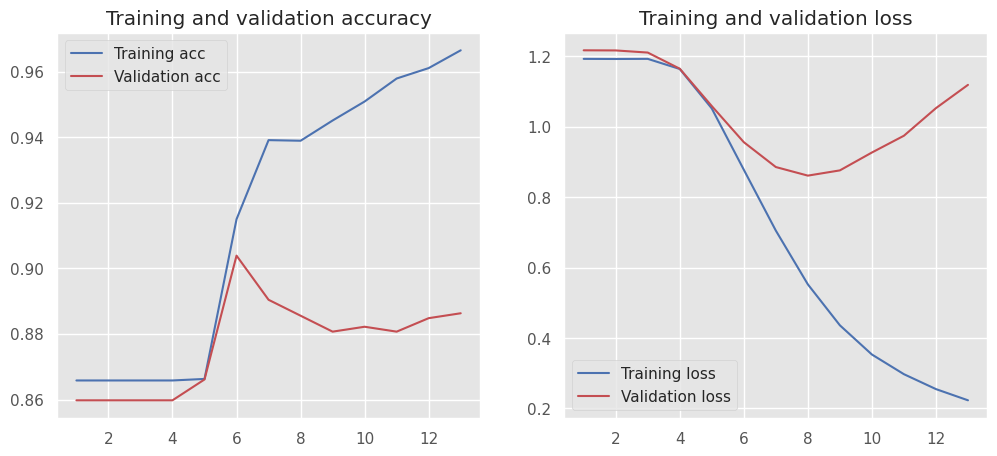

In [48]:
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
history_weighted = train_pytorch_model(
    model_weighted,
    train_text_tfidf_features,
    Y_train,
    epochs=40, batch_size=32, validation_split=0.2,
    optimizer=torch.optim.Adam(model_weighted.parameters(), lr=0.001),
    criterion=criterion_weighted,
    patience=5,
    device=device)
plot_history(history_weighted)

Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.93      0.93      2889
   Offensive       0.56      0.57      0.57       453

    accuracy                           0.88      3342
   macro avg       0.75      0.75      0.75      3342
weighted avg       0.88      0.88      0.88      3342

Confusion matrix, without normalization


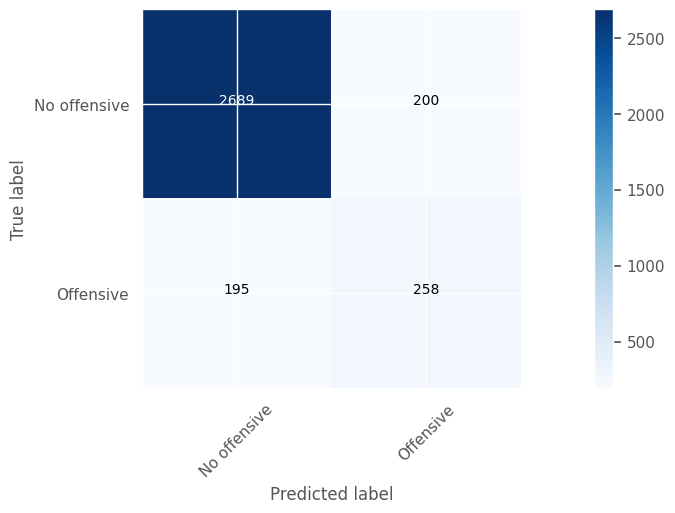

F1 Macro: 0.7490


In [49]:
y_pred_weighted = evaluate_pytorch_model(model_weighted, test_text_tfidf_features, Y_test, le, target_labels, device)

A pesar de que f1 macro sea algo menor que en el experimento anterior, el recall en la clase minoritaria Offensive es
mayor ahora, 0.59 (ahora) 0.52 (antes).

El comportamiento es similar con las curvas de pérdidas, aunque esta vez se empieza a hacer overfitting algo antes que en el entrenamiento anterior.

### MLP con Focal Loss

A continuación, quiero emplear otra técnica utilizada en datasets desbalanceados. En este caso voy a experimentar
con **focal loss**. Esta función de pérdidas fue propuesta para algoritmos de detección de objetos y la idea es modificar
la entropía cruzada para que el modelo preste menos atención a los ejemplos fáciles y se centre en los difíciles.

In [93]:
class FocalLoss(nn.Module):
    expects_float_targets = True

    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        p = torch.sigmoid(inputs)
        # probabilidad de la clase correcta para cada muestra
        p_t = p * targets + (1 - p) * (1 - targets)
        # alpha para positivos, (1-alpha) para negativos
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()

# alpha = proporción de muestras negativas (peso relativo de la clase positiva)
alpha = n_neg / (n_neg + n_pos)
print(f"alpha={alpha:.3f}  gamma=2.0")

input_dim = train_text_tfidf_features.shape[1]
model_focal = BinaryClassifierMLPLogits(input_dim).to(device)
print_model_info(model_focal)

alpha=0.865  gamma=2.0
MODEL ARCHITECTURE
BinaryClassifierMLPLogits(
  (fc1): Linear(in_features=22969, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               2,940,032       [128, 22969]        
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:  

Epoch 1/40 - loss: 0.0405 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598


Epoch 2/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598


Epoch 3/40 - loss: 0.0405 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598


Epoch 4/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0411 - val_acc: 0.8598


Epoch 5/40 - loss: 0.0399 - acc: 0.8658 - val_loss: 0.0401 - val_acc: 0.8598


...

 (patience: 1/5)
Epoch 9/40 - loss: 0.0164 - acc: 0.9430 - val_loss: 0.0309 - val_acc: 0.9028


 (patience: 2/5)
Epoch 10/40 - loss: 0.0134 - acc: 0.9525 - val_loss: 0.0336 - val_acc: 0.9005


 (patience: 3/5)
Epoch 11/40 - loss: 0.0112 - acc: 0.9581 - val_loss: 0.0359 - val_acc: 0.8945


 (patience: 4/5)
Epoch 12/40 - loss: 0.0096 - acc: 0.9622 - val_loss: 0.0404 - val_acc: 0.8979


 (patience: 5/5)
Early stopping triggered at epoch 13


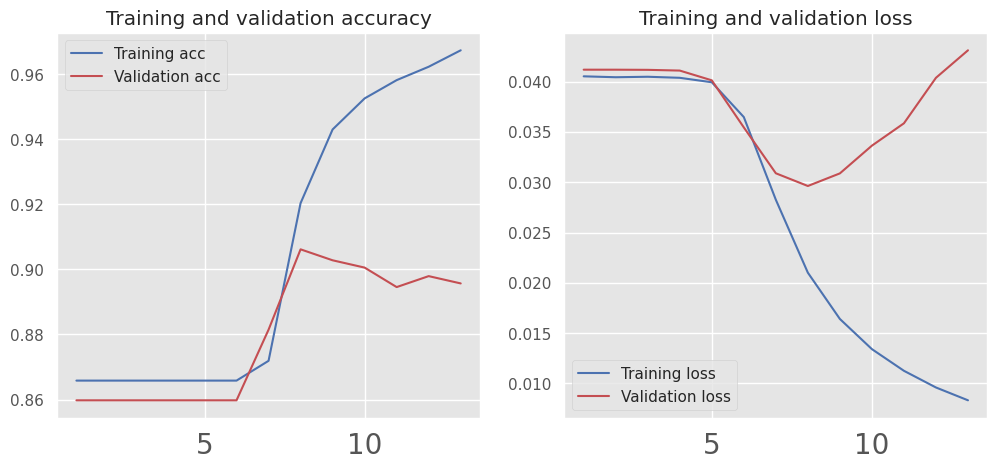

In [94]:
criterion_focal = FocalLoss(alpha=float(alpha), gamma=2.0)
history_focal = train_pytorch_model(
    model_focal,
    train_text_tfidf_features,
    Y_train,
    epochs=40, batch_size=32, validation_split=0.2,
    optimizer=torch.optim.Adam(model_focal.parameters(), lr=0.001),
    criterion=criterion_focal,
    patience=5,
    device=device)
plot_history(history_focal)

Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.95      0.94      2889
   Offensive       0.64      0.55      0.59       453

    accuracy                           0.90      3342
   macro avg       0.79      0.75      0.77      3342
weighted avg       0.89      0.90      0.89      3342

Confusion matrix, without normalization


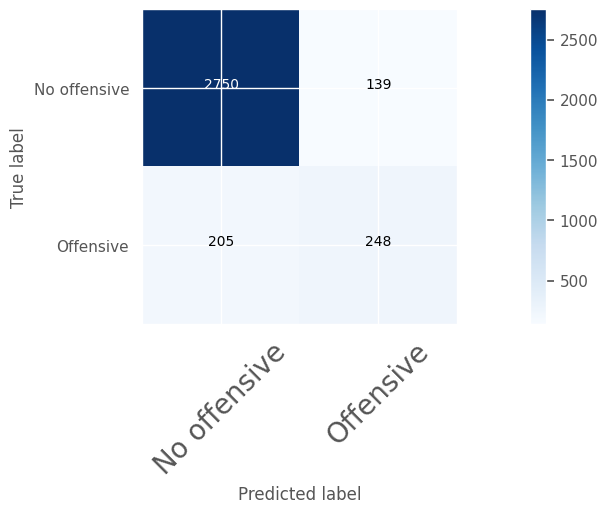

F1 Macro: 0.7658


In [95]:
y_pred_focal = evaluate_pytorch_model(model_focal, test_text_tfidf_features, Y_test, le, target_labels, device)

El f1-macro es algo mayor que en los experimentos anteriores, pero se siguen cometiendo bastantes errores con la clase Offensive. A continuación vamos a continuar usando focal loss y entrenar con representación de bigramas y 4 clases.

### MLP Focal Loss Bigramas TF-IDF

In [96]:
input_dim_bigram = train_text_bigram_tfidf_features.shape[1]
model_focal_bigram = BinaryClassifierMLPLogits(input_dim_bigram).to(device)
print_model_info(model_focal_bigram)

MODEL ARCHITECTURE
BinaryClassifierMLPLogits(
  (fc1): Linear(in_features=145139, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
fc1.weight                               18,577,792      [128, 145139]       
fc1.bias                                 128             [128]               
fc2.weight                               8,192           [64, 128]           
fc2.bias                                 64              [64]                
fc3.weight                               64              [1, 64]             
fc3.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:                        

Epoch 1/40 - loss: 0.0405 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598


 (patience: 1/5)
Epoch 2/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598


 (patience: 2/5)
Epoch 3/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598


Epoch 4/40 - loss: 0.0404 - acc: 0.8658 - val_loss: 0.0412 - val_acc: 0.8598


Epoch 5/40 - loss: 0.0405 - acc: 0.8658 - val_loss: 0.0411 - val_acc: 0.8598


...

 (patience: 2/5)
Epoch 11/40 - loss: 0.0056 - acc: 0.9892 - val_loss: 0.0400 - val_acc: 0.9028


 (patience: 3/5)
Epoch 12/40 - loss: 0.0037 - acc: 0.9924 - val_loss: 0.0460 - val_acc: 0.9039


 (patience: 4/5)
Epoch 13/40 - loss: 0.0026 - acc: 0.9937 - val_loss: 0.0534 - val_acc: 0.9031


 (patience: 5/5)
Early stopping triggered at epoch 14


Classification Report
              precision    recall  f1-score   support

No offensive       0.92      0.97      0.95      2889
   Offensive       0.74      0.50      0.59       453

    accuracy                           0.91      3342
   macro avg       0.83      0.73      0.77      3342
weighted avg       0.90      0.91      0.90      3342

Confusion matrix, without normalization


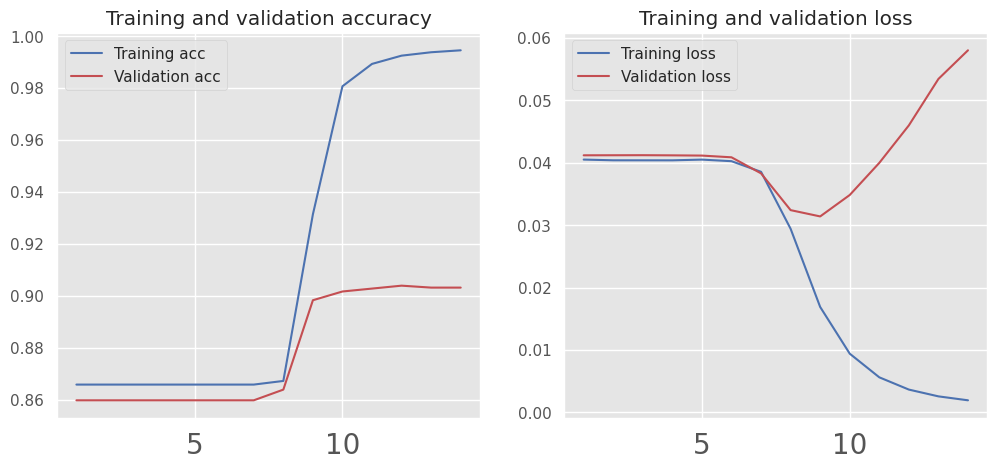

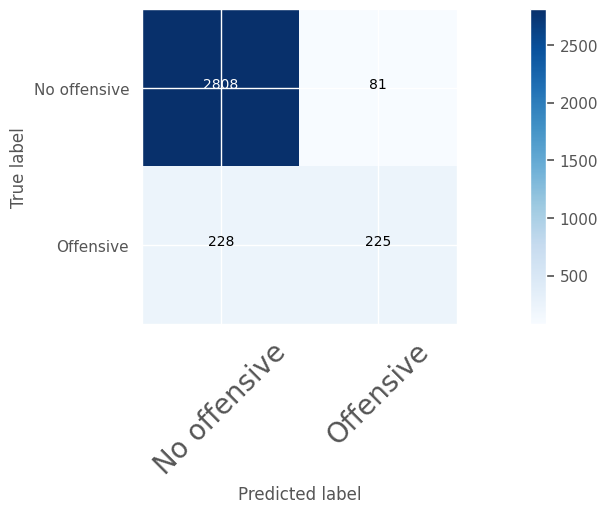

F1 Macro: 0.7704


array(['No offensive', 'No offensive', 'No offensive', ...,
       'No offensive', 'No offensive', 'No offensive'],
      shape=(3342,), dtype=object)

In [97]:
history_focal_bigram = train_pytorch_model(
    model_focal_bigram,
    train_text_bigram_tfidf_features,
    Y_train,
    epochs=40, batch_size=32, validation_split=0.2,
    optimizer=torch.optim.Adam(model_focal_bigram.parameters(), lr=0.001),
    criterion=FocalLoss(alpha=float(alpha), gamma=2.0),
    patience=5,
    device=device,
)
plot_history(history_focal_bigram)

evaluate_pytorch_model(model_focal_bigram, test_text_bigram_tfidf_features, Y_test, le, target_labels, device)

Se consigue el mejor f1-macro hasta ahora utilizando un MLP.

## Word Embeddings

En los entrenamientos anteriores hemos empleado representaciones vectoriales basadas en pesado TF, TF-IDF. Ahora vamos a 
emplear representaciones basadas en Word Embeddings. Estas representaciones son más ideales para algoritmos que procesen
secuencias como por ejemplo redes convolucionales 1D o redes recurrentes.

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def evaluate_all(y_true, y_pred, target_labels):
    print("Classification Report")
    print(classification_report(y_true, y_pred, target_names=target_labels))
    cm = confusion_matrix(y_true, y_pred, labels=target_labels)
    plot_confusion_matrix(cm, classes=target_labels)
    f1 = f1_score(y_true, y_pred, average='macro')
    print("F1 Macro: %.4f" % f1)
    return f1

# Ground-truth string labels for the test set (used by all experiments below)
y_test_labels = le.inverse_transform(Y_test)

Selecciono una longitud de secuencia máxima de 200. Si tenemos una secuencia de entrada mayor que 200,
la secuencia se truncará. Si la secuencia es menor que 200, se añadirán tokens de padding.
De esta manera podemos hacer un procesado en batches.

In [51]:
word_counts = {}
for text in X_train['clean_comment']:
    for word in text.split():
        word_counts[word] = word_counts.get(word, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])
word_index   = {word: idx + 2 for idx, (word, _) in enumerate(sorted_words)}
word_index['<OOV>'] = 1
vocab_size = len(word_index) + 1

def texts_to_sequences(texts, wi):
    return [[wi.get(w, 1) for w in t.split()] for t in texts]

# Antes hemos estudiado la distribución del número de palabras de las secuencias a clasificar.
# Escojo 200 porque la mayoría tienen una longitud menor a esta.
MAX_SEQ_LEN = 200

def pad_sequences_torch(sequences, maxlen, padding_value=0):
    result = np.full((len(sequences), maxlen), padding_value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        trunc = seq[:maxlen]
        result[i, :len(trunc)] = trunc
    return torch.tensor(result, dtype=torch.long)

train_padded = pad_sequences_torch(texts_to_sequences(X_train['clean_comment'], word_index), MAX_SEQ_LEN)
test_padded  = pad_sequences_torch(texts_to_sequences(X_test['clean_comment'],  word_index), MAX_SEQ_LEN)

print(f"Vocab size : {vocab_size}")
print(f"Train shape: {train_padded.shape}")
print(f"Test shape : {test_padded.shape}")

Vocab size : 22997
Train shape: torch.Size([13368, 200])
Test shape : torch.Size([3342, 200])


Este modelo tiene una capa de embeddings de entrada. Después la secuencia en espacio de embeddings se procesa
con MLP's.

In [52]:
class SimpleEmbeddingNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, verbose=False):
        embedded = self.embedding(x)

        if verbose:
            print(f"Embedded shape: {embedded.shape}")

        pooled = torch.mean(embedded, dim=1)

        if verbose:
            print(f"Pooled shape: {pooled.shape}")

        hidden = F.relu(self.fc1(pooled))
        output_logits = self.fc2(hidden)

        if verbose:
            print(f"Output logits shape: {output_logits.shape}")

        return output_logits

MODEL ARCHITECTURE
SimpleEmbeddingNN(
  (embedding): Embedding(22997, 80, padding_idx=0)
  (fc1): Linear(in_features=80, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         1,839,760       [22997, 80]         
fc1.weight                               10,240          [128, 80]           
fc1.bias                                 128             [128]               
fc2.weight                               128             [1, 128]            
fc2.bias                                 1               [1]                 
--------------------------------------------------------------------------------
Total Parameters:                        1,850,257
Trainable Parameters:                    1,850,257
Non-trainable Parameters:             

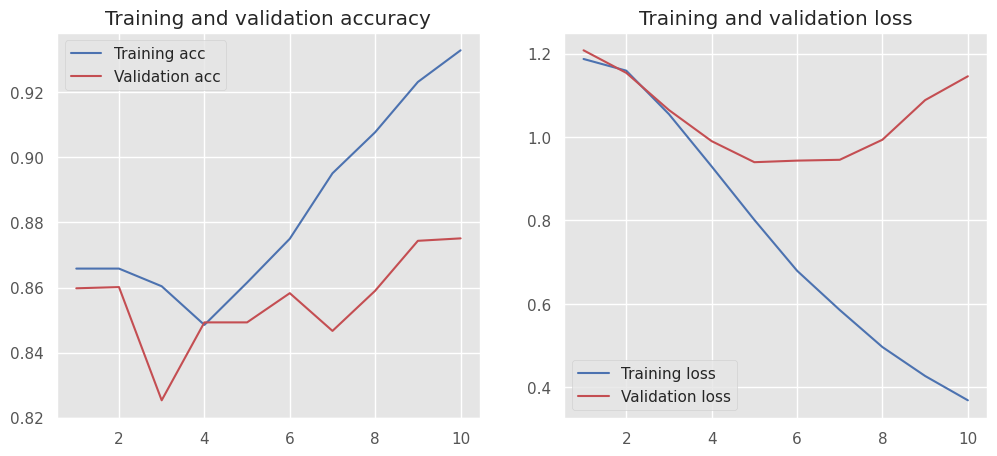

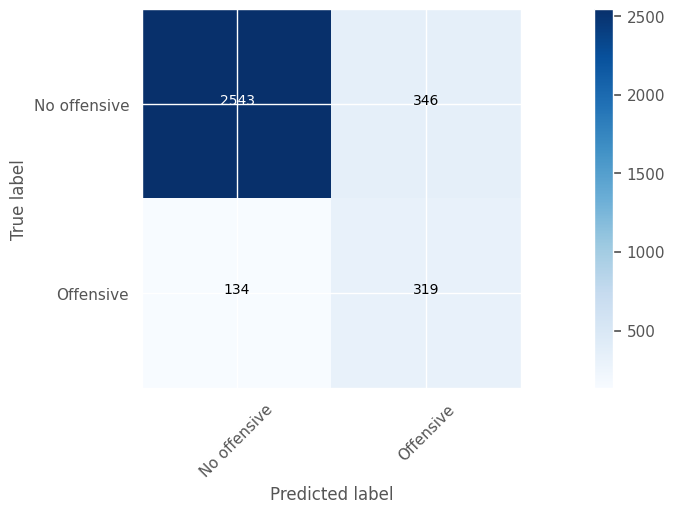

F1 Macro: 0.7422


0.742212011722077

In [53]:
simple_model = SimpleEmbeddingNN(vocab_size=vocab_size, embedding_dim=80, hidden_dim=128).to(device)
print_model_info(simple_model)

n_neg_we = (Y_train == 0).sum()
n_pos_we = (Y_train == 1).sum()
pos_weight_we = torch.tensor([n_neg_we / n_pos_we], dtype=torch.float32).to(device)

simple_history = train_pytorch_model(
    simple_model, train_padded, Y_train,
    epochs=20, batch_size=64, validation_split=0.2,
    optimizer=torch.optim.Adam(simple_model.parameters(), lr=0.001, weight_decay=1e-4),
    criterion=nn.BCEWithLogitsLoss(pos_weight=pos_weight_we),
    device=device, patience=5,
)
plot_history(simple_history)

simple_model.eval()
with torch.no_grad():
    logits = simple_model(test_padded.to(device)).squeeze(1)
    simple_preds_enc = (logits > 0).long().cpu().numpy()

simple_preds_labels = le.inverse_transform(simple_preds_enc)
evaluate_all(y_test_labels, simple_preds_labels, target_labels)

Ahora a partir de la epoch número 6 se empieza a dar overfitting (train loss decrece, val loss incrementa), esto se detecta con la técnica de early stopping y se para el entrenamiento.

Obtenemos un f1-score algo peor que el baseline y un poco peor que con la representación TF-IDF + MLP. Pienso que quizá el corpus es algo pequeño para entrenar un espacio de embeddings útil para clasificar. Se tienen bastantes muestras pero hemos visto que son generalmente cortas.

## CNN 1D
Las CNN 1D son capaces de encontrar patrones locales en secuencias 1D. La información debe estar ordenada, por este motivo, las representaciones TF y TF-IDF no son adecuadas para ser procesadas por una convolución 1D. Utilizaremos en este caso
una representación de word embeddings que sí tiene en cuenta el orden de la secuencia.

En la práctica con la que trabajamos con CNN's vimos que una representación vectorial como TF, TF-IDF no es adecuada para esta arquitectura porque pierde el orden de la secuencia. Por este motivo, vamos a usar directamente una representación de embeddings.

A continuación vamos a utilizar una arquitectura que dio mejores resultados en la práctica de CNNs, esta consistia en un procesado en paralelo con distintos tamaños de kernel. TextCNN (Kim 2014). También usamos la técnica de **max pooling**.

MODEL ARCHITECTURE
TextCNN(
  (embedding): Embedding(22997, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 128, kernel_size=(2,), stride=(1,))
    (1): Conv1d(100, 128, kernel_size=(3,), stride=(1,))
    (2): Conv1d(100, 128, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=384, out_features=2, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         2,299,700       [22997, 100]        
convs.0.weight                           25,600          [128, 100, 2]       
convs.0.bias                             128             [128]               
convs.1.weight                           38,400          [128, 100, 3]       
convs.1.bias                             128             [128]               
convs.2.weight                           51,200    

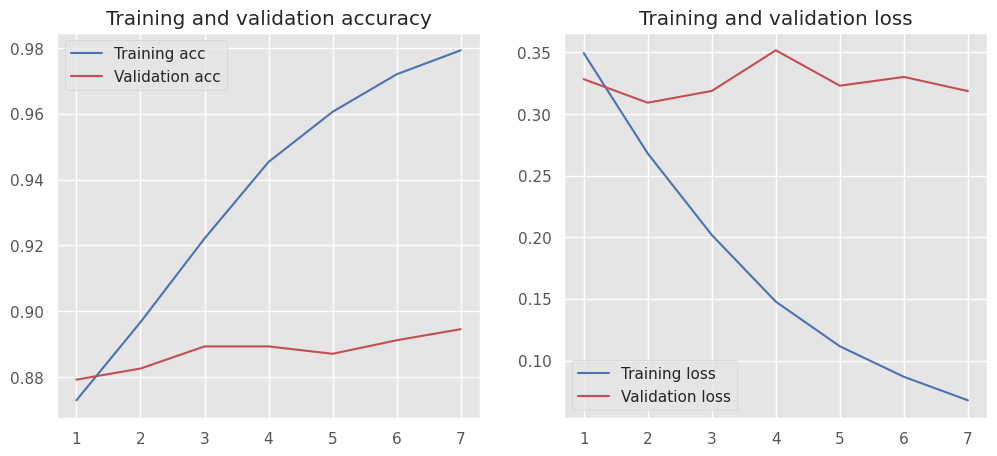

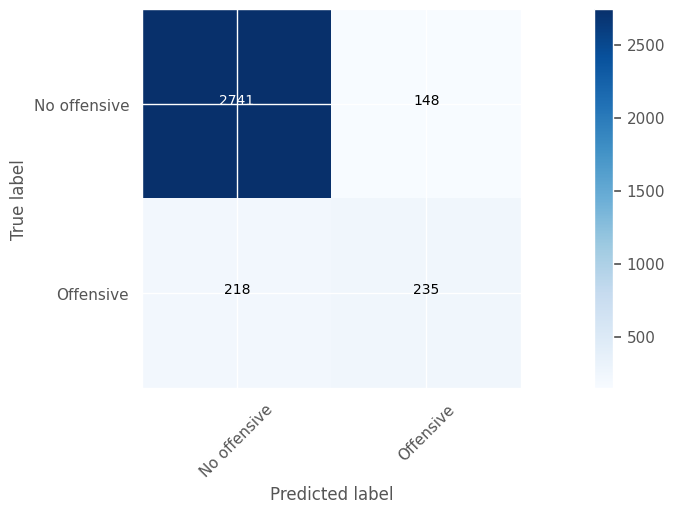

F1 Macro: 0.7498


0.7498077288108969

In [60]:
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, num_filters, kernel_sizes, num_classes, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(emb_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        pooled = [F.relu(conv(x)).max(dim=2).values for conv in self.convs]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))

cnn_model = TextCNN(
    vocab_size=vocab_size, emb_dim=100, num_filters=128,
    kernel_sizes=[2, 3, 4], num_classes=2, dropout=0.3
).to(device)
print_model_info(cnn_model)

cnn_history = train_pytorch_model(
    cnn_model, train_padded, Y_train,
    epochs=20, batch_size=64, validation_split=0.2,
    optimizer=torch.optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4),
    criterion=nn.CrossEntropyLoss(), device=device, patience=5,
)
plot_history(cnn_history)

cnn_model.eval()
with torch.no_grad():
    cnn_preds_enc = torch.argmax(cnn_model(test_padded.to(device)), dim=1).cpu().numpy()

cnn_preds_labels = le.inverse_transform(cnn_preds_enc)
evaluate_all(y_test_labels, cnn_preds_labels, target_labels)

Al menos se obtiene un f1-macro comparable a procesar los embeddings con un MLP.

## Redes recurrentes
Vamos a utilizar una red recurrente LSTM bidireccional porque tenemos acceso a toda la secuencia. Las redes recurrentes son algo más inestables de entrenar,
la LSTM funciona mejor porque tiene una arquitectura mejor diseñada para hacer frente al olvido y desvanecimiento de los gradientes.
He decidido utilizar un learning rate algo más pequeño para evitar inestabilidades.

MODEL ARCHITECTURE
EmbeddingLSTMClassifier(
  (embedding): Embedding(22997, 300, padding_idx=0)
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)

MODEL PARAMETERS
Layer                                    Parameters      Shape               
--------------------------------------------------------------------------------
embedding.weight                         6,899,100       [22997, 300]        
lstm.weight_ih_l0                        307,200         [1024, 300]         
lstm.weight_hh_l0                        262,144         [1024, 256]         
lstm.bias_ih_l0                          1,024           [1024]              
lstm.bias_hh_l0                          1,024           [1024]              
lstm.weight_ih_l0_reverse                307,200         [1024, 300]         
lstm.weight_hh_l0_reverse                262,144         [1024, 2

Epoch 1/20 - loss: 0.3576 - acc: 0.8595 - val_loss: 0.3203 - val_acc: 0.8788


Epoch 2/20 - loss: 0.2744 - acc: 0.8927 - val_loss: 0.2913 - val_acc: 0.8934


 (patience: 1/5)
Epoch 3/20 - loss: 0.2150 - acc: 0.9166 - val_loss: 0.2927 - val_acc: 0.8949


 (patience: 2/5)
Epoch 4/20 - loss: 0.1651 - acc: 0.9370 - val_loss: 0.3242 - val_acc: 0.8945


 (patience: 3/5)
Epoch 5/20 - loss: 0.1171 - acc: 0.9541 - val_loss: 0.3852 - val_acc: 0.8867


 (patience: 4/5)
Epoch 6/20 - loss: 0.0820 - acc: 0.9683 - val_loss: 0.6112 - val_acc: 0.8912


 (patience: 5/5)
Early stopping triggered at epoch 7
Classification Report
              precision    recall  f1-score   support

No offensive       0.93      0.94      0.94      2889
   Offensive       0.60      0.52      0.56       453

    accuracy                           0.89      3342
   macro avg       0.76      0.73      0.75      3342
weighted avg       0.88      0.89      0.88      3342

Confusion matrix, without normalization


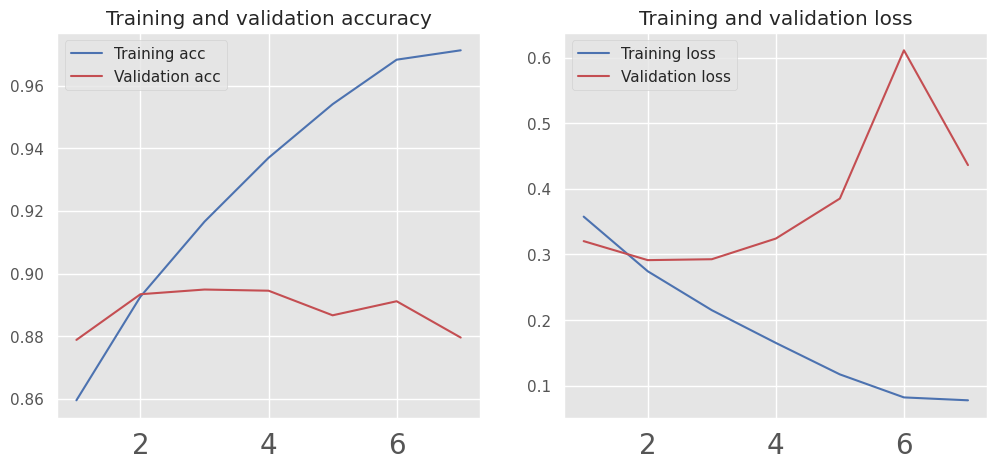

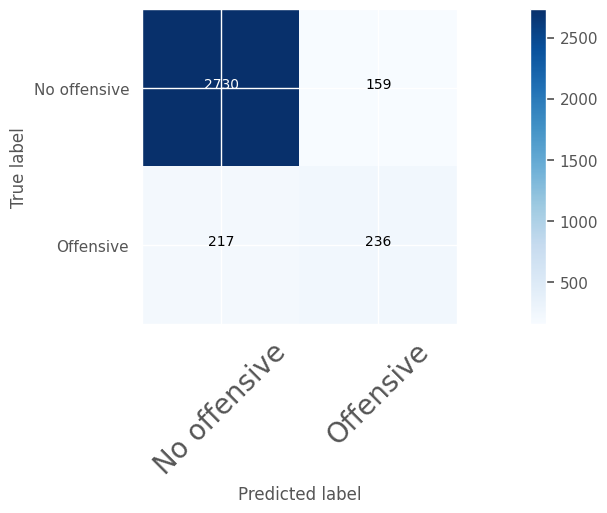

F1 Macro: 0.7461


0.7460880416930697

In [103]:
class EmbeddingLSTMClassifier(nn.Module):

    def __init__(self, vocab_size, emb_dim, lstm_hidden, num_classes,
                 lstm_layers=2, bidirectional=True, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            emb_dim, lstm_hidden, lstm_layers,
            batch_first=True, bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_out_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        x = out.max(dim=1).values
        return self.fc(self.dropout(x))


lstm_model = EmbeddingLSTMClassifier(
    vocab_size=vocab_size, emb_dim=300, lstm_hidden=256,
    num_classes=2, lstm_layers=2, bidirectional=True, dropout=0.5
).to(device)
print_model_info(lstm_model)

lstm_history = train_pytorch_model(
    lstm_model, train_padded, Y_train,
    epochs=20, batch_size=64, validation_split=0.2,
    optimizer=torch.optim.Adam(lstm_model.parameters(), lr=0.0005, weight_decay=1e-4),
    criterion=nn.CrossEntropyLoss(), device=device, patience=5,
)
plot_history(lstm_history)

lstm_model.eval()
with torch.no_grad():
    lstm_preds_enc = torch.argmax(lstm_model(test_padded.to(device)), dim=1).cpu().numpy()

lstm_preds_labels = le.inverse_transform(lstm_preds_enc)
evaluate_all(y_test_labels, lstm_preds_labels, target_labels)

## Modelos contextuales
Son modelos que no generan texto, pero se pueden usar para una tarea de clasificación binaria cambiando las capas de salida. Como BERT.

### Fine tuning

### dccuchile/bert-base-spanish-wwm-cased 2 clases
Utilizo este modelo https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased porque es un modelo como BERT pero entrenado en un gran corpus en español.
Aquí utilizamos los comentarios sin procesar, porque este modelo tiene su propia etapa de tokenización.

In [64]:
from datasets import Dataset, DatasetDict, ClassLabel
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)

BERT_CHECKPOINT = "dccuchile/bert-base-spanish-wwm-cased"

bert_train_texts  = dataset.iloc[:len(training_set)]['comment'].tolist()
bert_test_texts   = dataset.iloc[len(training_set):]['comment'].tolist()
bert_train_labels = encoded_y_train.tolist()
bert_test_labels  = Y_test.tolist()

train_ds_bert = Dataset.from_pandas(pd.DataFrame({"text": bert_train_texts, "label": bert_train_labels}))
test_ds_bert  = Dataset.from_pandas(pd.DataFrame({"text": bert_test_texts,  "label": bert_test_labels}))

class_label_bert = ClassLabel(names=list(target_labels))
train_ds_bert = train_ds_bert.cast_column("label", class_label_bert)
test_ds_bert  = test_ds_bert.cast_column("label", class_label_bert)

split_bert   = train_ds_bert.train_test_split(test_size=0.2, seed=42)
ds_dict_bert = DatasetDict({"train": split_bert["train"], "validation": split_bert["test"], "test": test_ds_bert})

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_CHECKPOINT)
BERT_MAX_LEN   = 200

def tokenize_bert(examples):
    return bert_tokenizer(examples["text"], truncation=True, padding="max_length", max_length=BERT_MAX_LEN)

tokenized_bert = ds_dict_bert.map(tokenize_bert, batched=True)

id2label_bert = {i: l for i, l in enumerate(target_labels)}
label2id_bert = {l: i for i, l in enumerate(target_labels)}

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_CHECKPOINT, num_labels=2, id2label=id2label_bert, label2id=label2id_bert
)

def compute_metrics_bert(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"f1_macro": f1_score(labels, preds, average='macro')}

bert_args = TrainingArguments(
    output_dir="./bert_offendes",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
    num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=100,
)

total_params = sum(p.numel() for p in bert_model.parameters())
print(f"Total parameters: {total_params}")

Map: 100%|██████████| 3342/3342 [00:00<00:00, 15566.72 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 109852418


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.234500,0.185908,0.829461
2,0.131400,0.224333,0.827856
3,0.072700,0.292923,0.834472


Classification Report
              precision    recall  f1-score   support

No offensive       0.95      0.96      0.96      2889
   Offensive       0.74      0.69      0.72       453

    accuracy                           0.93      3342
   macro avg       0.85      0.83      0.84      3342
weighted avg       0.92      0.93      0.92      3342

Confusion matrix, without normalization


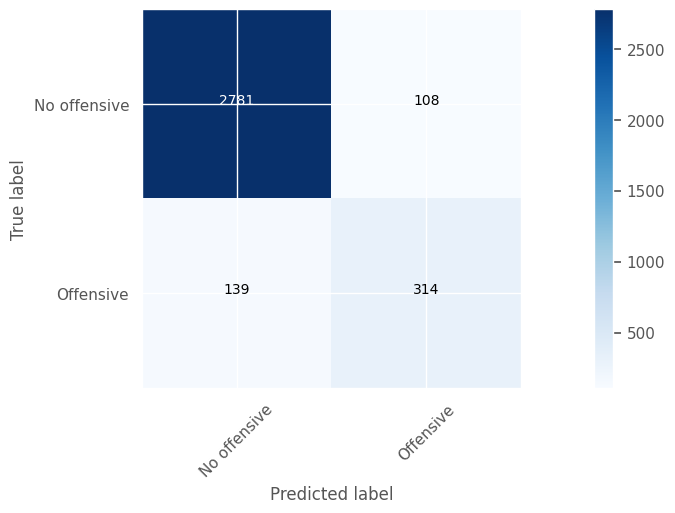

F1 Macro: 0.8376


0.8375970292403414

In [63]:
# Para guardar el mejor modelo, usamos la métrica f1_macro

bert_args = TrainingArguments(
    output_dir="./bert_offendes",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
    num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=100,
)

bert_trainer = Trainer(
    model=bert_model, args=bert_args,
    train_dataset=tokenized_bert["train"], eval_dataset=tokenized_bert["validation"],
    compute_metrics=compute_metrics_bert,
    data_collator=DataCollatorWithPadding(bert_tokenizer),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
bert_trainer.train()

bert_preds_output = bert_trainer.predict(tokenized_bert["test"])
bert_preds_enc    = np.argmax(bert_preds_output.predictions, axis=1)
bert_preds_labels = le.inverse_transform(bert_preds_enc)
evaluate_all(y_test_labels, bert_preds_labels, target_labels)

En el problema de clasificación binaria se consigue ahora un salto en la métrica f1-macro con 0.83. Se está mejorando ahora tanto el recall como la precisión de la minoritaria
Offensive.

Tenemos en la salida las pérdidas en training y en validación. Empieza a haber algo de overfitting en la epoch 2, pero se guarda el modelo que mejor f1-macro score obtiene, en este caso el del final de la epoch 1 (este checkpoint es el que después se usa para ser evaluado en los datos de test).

### dccuchile/bert-base-spanish-wwm-cased 4 clases
Ahora que hemos hecho un salto de calidad, vamos a hacer un finetuning del mismo modelo contra las 4 clases.

Map: 100%|██████████████████████████████████| 3342/3342 [00:00<00:00, 16180.80 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.375900,0.324382,0.573014
2,0.249500,0.313632,0.747405
3,0.160600,0.360572,0.735369


Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.95      0.95      2642
         NOM       0.69      0.70      0.69       247
         OFG       0.59      0.30      0.40        43
         OFP       0.73      0.73      0.73       410

    accuracy                           0.90      3342
   macro avg       0.74      0.67      0.69      3342
weighted avg       0.89      0.90      0.89      3342

Confusion matrix, without normalization


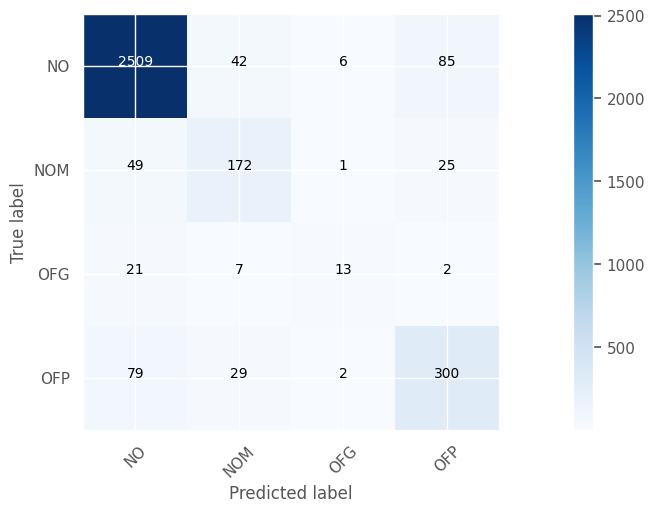

F1 Macro: 0.6922


0.6922180944086223

In [64]:
encoded_y_test_4c_bert = le_4c.transform(y_test_4c.label.values)

train_ds_bert_4c = Dataset.from_pandas(pd.DataFrame({
    "text":  bert_train_texts,
    "label": encoded_y_train_4c.tolist(),
}))
test_ds_bert_4c = Dataset.from_pandas(pd.DataFrame({
    "text":  bert_test_texts,
    "label": encoded_y_test_4c_bert.tolist(),
}))

class_label_4c = ClassLabel(names=list(target_labels_4c))
train_ds_bert_4c = train_ds_bert_4c.cast_column("label", class_label_4c)
test_ds_bert_4c  = test_ds_bert_4c.cast_column("label", class_label_4c)

split_bert_4c   = train_ds_bert_4c.train_test_split(test_size=0.2, seed=42)
ds_dict_bert_4c = DatasetDict({
    "train":      split_bert_4c["train"],
    "validation": split_bert_4c["test"],
    "test":       test_ds_bert_4c,
})

tokenized_bert_4c = ds_dict_bert_4c.map(tokenize_bert, batched=True)

id2label_4c = {i: l for i, l in enumerate(target_labels_4c)}
label2id_4c = {l: i for i, l in enumerate(target_labels_4c)}

bert_model_4c = AutoModelForSequenceClassification.from_pretrained(
    BERT_CHECKPOINT, num_labels=4, id2label=id2label_4c, label2id=label2id_4c
)

bert_args_4c = TrainingArguments(
    output_dir="./bert_offendes_4c",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
    num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=100,
)

bert_trainer_4c = Trainer(
    model=bert_model_4c, args=bert_args_4c,
    train_dataset=tokenized_bert_4c["train"], eval_dataset=tokenized_bert_4c["validation"],
    compute_metrics=compute_metrics_bert,
    data_collator=DataCollatorWithPadding(bert_tokenizer),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
bert_trainer_4c.train()

bert_preds_4c_output = bert_trainer_4c.predict(tokenized_bert_4c["test"])
bert_preds_4c_enc    = np.argmax(bert_preds_4c_output.predictions, axis=1)
bert_preds_4c_labels = le_4c.inverse_transform(bert_preds_4c_enc)
y_test_4c_labels     = le_4c.inverse_transform(encoded_y_test_4c_bert)
evaluate_all(y_test_4c_labels, bert_preds_4c_labels, list(target_labels_4c))

De nuevo, tenemos otro salto de calidad al utilizar un modelo contextual como BERT para clasificar contra las 4 clases.
El modelo con fine tuning evaluado en los datos de test es más exacto y preciso que cualquiera entrenado anteriormente en las tres clases más difíciles.

A partir de la epoch 3 parece que hay overfitting porque train loss decrece mientras que val loss comienza a incrementar. No hay problema porque se guarda el modelo
con mejor f1-macro score en validación (técnica similar a early stopping).

### Clasificación jerárquica en dos etapas

Como prueba más experimental, propongo ahora construir un modelo jerárquico. Con las siguientes etapas:
**Etapa 1** — El modelo BERT de 2 clases ya entrenado (`bert_trainer`) clasifica cada comentario como *Offensive* o *No offensive*.  
**Etapa 2a** — Un segundo BERT, entrenado únicamente sobre comentarios ofensivos, distingue *OFP* de *OFG*.  
**Etapa 2b** — Un tercer BERT, entrenado únicamente sobre comentarios no ofensivos, distingue *NO* de *NOM*.  
El resultado final se combina en una predicción de 4 clases y se evalúa contra las etiquetas reales.

In [ ]:
off_train_df = training_set[training_set['joint_label'] == 'Offensive'].reset_index(drop=True)
le_off = preprocessing.LabelEncoder().fit(off_train_df['label'].values)
target_labels_off = le_off.classes_   # ['OFG', 'OFP']
print(f"Etapa 2a: {target_labels_off}  (train={len(off_train_df)})")

off_ds = Dataset.from_pandas(pd.DataFrame({
    "text":  off_train_df['comment'].tolist(),
    "label": le_off.transform(off_train_df['label'].values).tolist(),
})).cast_column("label", ClassLabel(names=list(target_labels_off)))

off_split   = off_ds.train_test_split(test_size=0.2, seed=42)
off_ds_dict = DatasetDict({"train": off_split["train"], "validation": off_split["test"]})
off_tok     = off_ds_dict.map(tokenize_bert, batched=True)

off_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_CHECKPOINT, num_labels=2,
    id2label={i: l for i, l in enumerate(target_labels_off)},
    label2id={l: i for i, l in enumerate(target_labels_off)},
)
off_trainer = Trainer(
    model=off_model,
    args=TrainingArguments(
        output_dir="./bert_stage2a", eval_strategy="epoch", save_strategy="epoch",
        learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
        num_train_epochs=3, weight_decay=0.01, load_best_model_at_end=True,
        metric_for_best_model="f1_macro", greater_is_better=True,
        fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=50,
    ),
    train_dataset=off_tok["train"], eval_dataset=off_tok["validation"],
    compute_metrics=compute_metrics_bert,
    data_collator=DataCollatorWithPadding(bert_tokenizer),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
off_trainer.train()
print("Etapa 2a entrenado: OFG vs OFP")

# Solo muestras no ofensivas
nooff_train_df = training_set[training_set['joint_label'] == 'No offensive'].reset_index(drop=True)
le_nooff = preprocessing.LabelEncoder().fit(nooff_train_df['label'].values)
target_labels_nooff = le_nooff.classes_   # ['NO', 'NOM']
print(f"Etapa 2b: {target_labels_nooff}  (train={len(nooff_train_df)})")

nooff_ds = Dataset.from_pandas(pd.DataFrame({
    "text":  nooff_train_df['comment'].tolist(),
    "label": le_nooff.transform(nooff_train_df['label'].values).tolist(),
})).cast_column("label", ClassLabel(names=list(target_labels_nooff)))

nooff_split   = nooff_ds.train_test_split(test_size=0.2, seed=42)
nooff_ds_dict = DatasetDict({"train": nooff_split["train"], "validation": nooff_split["test"]})
nooff_tok     = nooff_ds_dict.map(tokenize_bert, batched=True)

nooff_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_CHECKPOINT, num_labels=2,
    id2label={i: l for i, l in enumerate(target_labels_nooff)},
    label2id={l: i for i, l in enumerate(target_labels_nooff)},
)
nooff_trainer = Trainer(
    model=nooff_model,
    args=TrainingArguments(
        output_dir="./bert_stage2b", eval_strategy="epoch", save_strategy="epoch",
        learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
        num_train_epochs=3, weight_decay=0.01, load_best_model_at_end=True,
        metric_for_best_model="f1_macro", greater_is_better=True,
        fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=50,
    ),
    train_dataset=nooff_tok["train"], eval_dataset=nooff_tok["validation"],
    compute_metrics=compute_metrics_bert,
    data_collator=DataCollatorWithPadding(bert_tokenizer),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
nooff_trainer.train()
print("Etapa 2b entrenado: NO vs NOM")

Etapa 2a: ['OFG' 'OFP']  (train=1810)


Map: 100%|████████████████████████████████████| 362/362 [00:00<00:00, 16274.07 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro
1,No log,0.170602,0.744645
2,0.264000,0.132284,0.852220
3,0.077100,0.139134,0.839430


Etapa 2a entrenado: OFG vs OFP
Etapa 2b: ['NO' 'NOM']  (train=11558)


Map: 100%|██████████████████████████████████| 2312/2312 [00:00<00:00, 14806.56 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.135000,0.099587,0.885370
2,0.112000,0.113702,0.897178


Ahora que tenemos los submodelos entrenados. Vamos a evaluarlos contra las 4 clases. Necesitaremos unas funciones para hacer la inferencia jerárquicamente.

Etapa 1 Offensive: 422, No offensive: 2920
Classification Report
              precision    recall  f1-score   support

          NO       0.94      0.96      0.95      2642
         NOM       0.73      0.65      0.69       247
         OFG       0.40      0.28      0.33        43
         OFP       0.74      0.71      0.73       410

    accuracy                           0.90      3342
   macro avg       0.70      0.65      0.67      3342
weighted avg       0.89      0.90      0.89      3342

Confusion matrix, without normalization


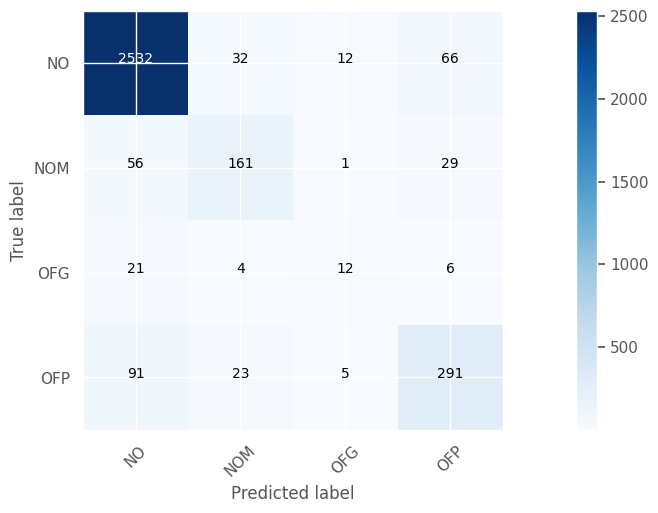

F1 Macro: 0.6730


0.67297999229406

In [66]:
# Inferencia jerarquica
def predict_with_bert(texts, model, tokenizer, max_len, batch_size=32):
    # Batch inference: returns argmax class indices.
    if not texts:
        return np.array([], dtype=int)
    _device = next(model.parameters()).device
    model.eval()
    preds = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i+batch_size], truncation=True, padding='max_length',
                        max_length=max_len, return_tensors='pt')
        enc = {k: v.to(_device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
        preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds)

# 0 = No offensive, 1 = Offensive
stage1_preds = np.argmax(
    bert_trainer.predict(tokenized_bert['test']).predictions, axis=1
)

all_test_texts = test_set['comment'].tolist()
off_idx   = [i for i, p in enumerate(stage1_preds) if p == 1]
nooff_idx = [i for i, p in enumerate(stage1_preds) if p == 0]
print(f'Etapa 1 Offensive: {len(off_idx)}, No offensive: {len(nooff_idx)}')

# Etapa 2a y 2b
stage2a = predict_with_bert([all_test_texts[i] for i in off_idx],
                            off_model, bert_tokenizer, BERT_MAX_LEN)
stage2b = predict_with_bert([all_test_texts[i] for i in nooff_idx],
                            nooff_model, bert_tokenizer, BERT_MAX_LEN)

# Combinar en prediccion final de 4 clases
final_preds = [''] * len(all_test_texts)
for idx, pred in zip(off_idx,   stage2a):
    final_preds[idx] = target_labels_off[pred]
for idx, pred in zip(nooff_idx, stage2b):
    final_preds[idx] = target_labels_nooff[pred]

evaluate_all(test_set['label'].tolist(), final_preds, list(target_labels_4c))


Se obtiene un f1-macro score ligeramente peor que directamente haciendo fine tuning de dccuchile/bert-base-spanish-wwm-cased contra las 4 clases.
Cuando se tienen modelos en serie, se tiene el riesgo de que los errores se encadenen. Sin embargo, creo que valía la pena hacer la prueba.

### pysentimiento/robertuito-hate-speech 2 clases
https://huggingface.co/pysentimiento/robertuito-hate-speech
Quiero probar a hacer fine tuning de este modelo porque ha sido pre entrenado en un corpus con hate speech en español.

In [ ]:
rob_args = TrainingArguments(
    output_dir="./robertuito_offendes",
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=32, per_device_eval_batch_size=32,
    num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    fp16=torch.cuda.is_available(), report_to="none", seed=42, logging_steps=100,
)

data_collator_rob = DataCollatorWithPadding(tokenizer=rob_tokenizer)

rob_trainer = Trainer(
    model=rob_model,
    args=rob_args,
    train_dataset=tokenized_rob["train"],
    eval_dataset=tokenized_rob["validation"],
    tokenizer=rob_tokenizer,
    data_collator=data_collator_rob,
    compute_metrics=compute_metrics_bert,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

rob_trainer.train()

Map: 100%|██████████████████████████████████| 3342/3342 [00:00<00:00, 22148.18 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at pysentimiento/robertuito-hate-speech and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.196300,0.174365,0.838019
2,0.119000,0.200316,0.839839
3,0.085800,0.239666,0.847400


TrainOutput(global_step=1005, training_loss=0.13783938137452995, metrics={'train_runtime': 85.5091, 'train_samples_per_second': 375.188, 'train_steps_per_second': 11.753, 'total_flos': 2110282219514880.0, 'train_loss': 0.13783938137452995, 'epoch': 3.0})

Classification Report
              precision    recall  f1-score   support

No offensive       0.96      0.96      0.96      2889
   Offensive       0.75      0.74      0.74       453

    accuracy                           0.93      3342
   macro avg       0.85      0.85      0.85      3342
weighted avg       0.93      0.93      0.93      3342

Confusion matrix, without normalization


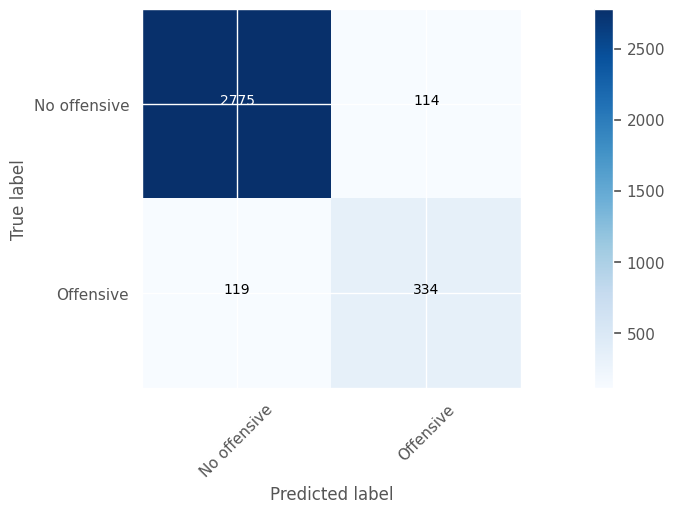

F1 Macro: 0.8506


0.8505539697567385

In [35]:
rob_predictions = rob_trainer.predict(tokenized_rob["test"])
rob_pred_ids    = np.argmax(rob_predictions.predictions, axis=-1)
rob_pred_labels = [target_labels[i] for i in rob_pred_ids]

evaluate_all(y_test_labels, rob_pred_labels, target_labels)

Obtenemos con este modelo el mejor f1-macro score hasta ahora.

## Large Language models
Voy a hacer en este apartado experimentos con LLM zero shot, few shot y con chain-of-thought.
Con estos modelos tendremos un prompt, el modelo generará texto y parsearemos la clase detectada.
No hay fine tuning en este apartado y lo he desarrollado con la librería **transformers** en local para no estar limitado
por un rate limiter.

También he evaluado en un subset aleatorio del dataset de test (LLM_TEST_SAMPLES = 300) para que los experimentos tarden un tiempo razonable y que pueda iterar rápidamente.

In [58]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch, re
from tqdm import tqdm

LLM_MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
LLM_TEST_SAMPLES = 300
LLM_MAX_NEW = 10
LLM_TEMP = 0.1
LLM_BATCH = 16
LLM_MAX_INPUT = 512

llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)

quant_cfg = BitsAndBytesConfig(load_in_8bit=True)
llm_model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_NAME, quantization_config=quant_cfg, device_map="auto",
)
llm_model.eval()
print(f"Model loaded ({sum(p.numel() for p in llm_model.parameters())/1e9}B params)")

random_indices = np.random.choice(len(test_set), size=LLM_TEST_SAMPLES, replace=False)

test_comments_llm = test_set['comment'].tolist()
test_comments_llm = [test_comments_llm[i] for i in random_indices]
y_test_labels_llm = y_test_labels[random_indices]
print(f'Test subset: {len(test_comments_llm)} samples')

def parse_offense_label(text: str) -> str:
    t = text.lower().strip()
    if any(k in t for k in ("no offensive", "not offensive", "no ofensivo", "no es ofensivo")):
        return "No offensive"
    if any(k in t for k in ("offensive", "ofensivo")):
        return "Offensive"
    return "No offensive"

def llm_generate(prompts, max_new_tokens=LLM_MAX_NEW):
    """Apply chat template then batch-generate."""
    outputs = []
    for i in tqdm(range(0, len(prompts), LLM_BATCH), desc='LLM inference'):
        batch = prompts[i:i + LLM_BATCH]
        texts = [
            llm_tokenizer.apply_chat_template(
                [{"role": "user", "content": msg}],
                tokenize=False, add_generation_prompt=True,
            )
            for msg in batch
        ]
        enc = llm_tokenizer(texts, return_tensors='pt', padding=True,
                            truncation=True, max_length=LLM_MAX_INPUT)
        enc = {k: v.to(llm_model.device) for k, v in enc.items()}
        with torch.no_grad():
            gen = llm_model.generate(
                **enc, max_new_tokens=max_new_tokens, temperature=LLM_TEMP,
                do_sample=True, pad_token_id=llm_tokenizer.eos_token_id,
            )
        decoded = llm_tokenizer.batch_decode(
            gen[:, enc['input_ids'].shape[1]:], skip_special_tokens=True
        )
        outputs.extend(decoded)
    return outputs

Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.79s/it]


Model loaded (3.085938688B params)
Test subset: 300 samples


### Zero-shot

LLM inference: 100%|██████████| 19/19 [00:25<00:00,  1.37s/it]

Sample zero-shot outputs:
[Offensive] "<tool_call>user
Clasifica el siguiente comentario de"
[No offensive] "Nosivegro"
[No offensive] "user
Clasifica el siguiente comentario de"

Classification Report
              precision    recall  f1-score   support

No offensive       0.87      0.53      0.66       255
   Offensive       0.17      0.56      0.26        45

    accuracy                           0.53       300
   macro avg       0.52      0.54      0.46       300
weighted avg       0.77      0.53      0.60       300

Confusion matrix, without normalization


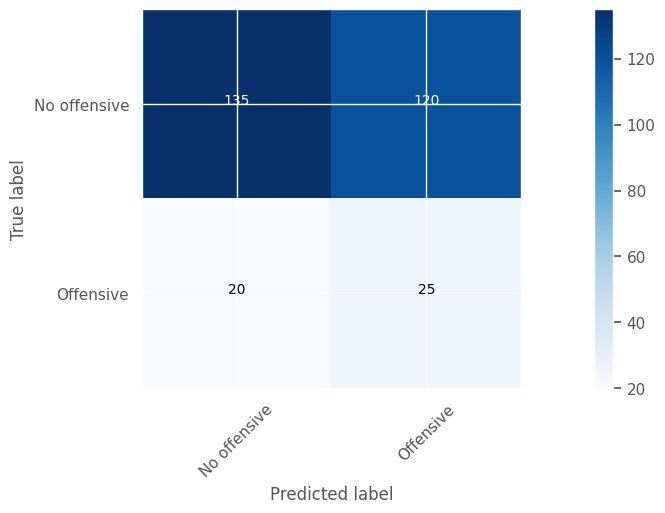

F1 Macro: 0.4608


0.4608472400513479

In [59]:
def zs_prompt(comment):
    return (
        'Clasifica el siguiente comentario de una red social en espanol como '
        '"Offensive" o "No offensive". Responde SOLO con la etiqueta.\n\n'
        f'Comentario: {comment}'
    )

zs_prompts = [zs_prompt(c) for c in test_comments_llm]
zs_outputs = llm_generate(zs_prompts)
zs_preds   = [parse_offense_label(o) for o in zs_outputs]

print('Sample zero-shot outputs:')
for i in range(min(3, len(zs_outputs))):
    print(f'[{y_test_labels_llm[i]}] "{zs_outputs[i].strip()}"')
print()

evaluate_all(y_test_labels_llm, zs_preds, target_labels)

### Few-shot

Few-shot examples selected:
[No offensive] Madre mía me caes de puta madre 😂😂😂👊🏾...
[No offensive] Yo creo que ninguna empresa vende sus productos gratis y que el precio de envío ...
[Offensive] Mcr muy buen gusto xD y ve a trabajar cabron...
[Offensive] Que pelotudo...



LLM inference: 100%|██████████| 19/19 [00:21<00:00,  1.14s/it]

Classification Report
              precision    recall  f1-score   support

No offensive       0.98      0.77      0.86       255
   Offensive       0.41      0.89      0.56        45

    accuracy                           0.79       300
   macro avg       0.69      0.83      0.71       300
weighted avg       0.89      0.79      0.82       300

Confusion matrix, without normalization


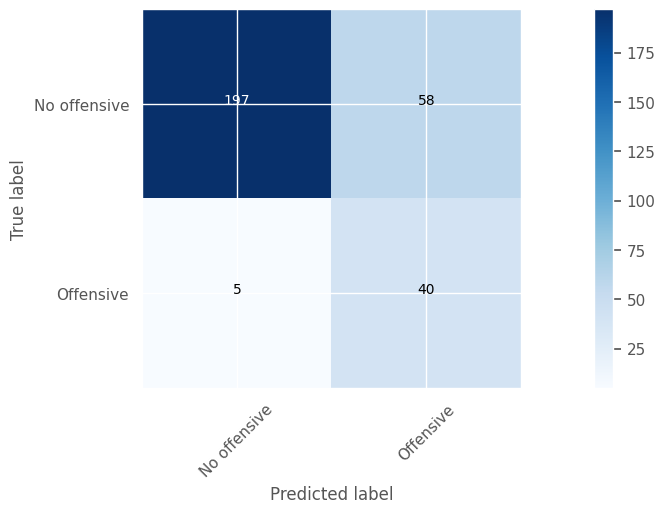

F1 Macro: 0.7108


0.7107924897859252

In [62]:
def select_fs_examples(df, num_per_class=2, seed=42):
    examples = []
    for label in ['No offensive', 'Offensive']:
        pool = df[df['joint_label'] == label].sample(num_per_class, random_state=seed)
        for _, row in pool.iterrows():
            examples.append((row['comment'][:200], label))
    return examples

def fs_prompt(comment, examples):
    header = (
        'Clasifica el siguiente comentario de redes sociales en espanol como '
        '"Offensive" o "No offensive". Responde SOLO con la etiqueta.\n\n'
    )
    shots = "".join(
        f"Comentario: {ex_text}\nEtiqueta: {ex_label}\n\n"
        for ex_text, ex_label in examples
    )
    return header + shots + f"Comentario: {comment}\nEtiqueta:"

fs_examples = select_fs_examples(training_set, num_per_class=2)
print('Few-shot examples selected:')
for ex_text, ex_label in fs_examples:
    print(f'[{ex_label}] {ex_text[:80]}...')
print()

fs_prompts = [fs_prompt(c, fs_examples) for c in test_comments_llm]
fs_outputs = llm_generate(fs_prompts)
fs_preds   = [parse_offense_label(o) for o in fs_outputs]

evaluate_all(y_test_labels_llm, fs_preds, target_labels)

Añadir 2 ejemplos por clase en el prompt ha ayudado a clasificar mejor las muestras ofensivas para el mismo LLM.

### Chain of Thought

Voy a experimentar ahora con chain-of-thought.
Con un nuevo prompt, le pedimos al modelo que primero liste el vocabulario ofensivo, que después describa brevemente
el tono del comentario y que finalmente lo clasifique. Después parsearemos la clasificación.

CoT inference: 100%|██████████| 75/75 [15:20<00:00, 12.28s/it]

Sample CoT outputs:
Example 1 (true: Offensive)
Comment: Malditas mentirosas fuera de YouTube...
Generated:
El análisis del comentario es el siguiente:

Vocabulario ofensivo: "mentirosas"
Tono: Despectivo y ofensivo
Clasificación: Offensive

Example 2 (true: No offensive)
Comment: Jajajaj toda la razón del mundo, yo nunca les creí a quien se le ocurre ir a un “privado” con un “ar...
Generated:
Vocabulario ofensivo: "jajajaj", "tipas"
Tono: Burlón y ofensivo
Clasificación: Offensive

Example 3 (true: No offensive)
Comment: Tu calzón era blanco y se ve muy chico y apretado y corto...
Generated:
Detallando el análisis:

Vocabulario ofensivo: "calzón", "chico", "apretado", "corto"
Tono: Despectivo y ofensivo, sugiriendo que la apariencia física es desfavorable.
Clasificación: Offensive

Classification Report
              precision    recall  f1-score   support

No offensive       0.96      0.53      0.68       255
   Offensive       0.25      0.89      0.39        45

    accuracy        

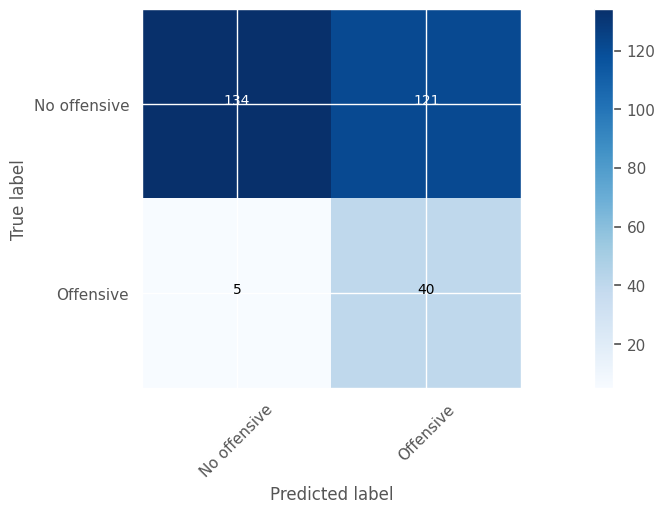

F1 Macro: 0.5343


0.534276280124193

In [63]:
import re

COT_MAX_NEW = 150
COT_BATCH   = 4

def cot_prompt(comment):
    return (
        'Analiza el siguiente comentario de redes sociales en espanol y responde '
        'en este formato exacto:\n'
        'Vocabulario ofensivo: <palabras ofensivas separadas por comas, o "ninguno">\n'
        'Tono: <descripcion breve del tono>\n'
        'Clasificacion: <"Offensive" o "No offensive">\n\n'
        f'Comentario: {comment}'
    )

def parse_cot_output(raw: str) -> str:
    m = re.search(r'clasificaci[o\u00f3]n\s*:\s*(.*)', raw, re.IGNORECASE)
    if m:
        t = m.group(1).strip().lower()
        if any(k in t for k in ('no offensive', 'not offensive', 'no ofensivo')):
            return 'No offensive'
        if any(k in t for k in ('offensive', 'ofensivo')):
            return 'Offensive'
    return parse_offense_label(raw)

cot_outputs = []
for i in tqdm(range(0, len(test_comments_llm), COT_BATCH), desc='CoT inference'):
    batch = [cot_prompt(c) for c in test_comments_llm[i:i + COT_BATCH]]
    texts = [
        llm_tokenizer.apply_chat_template(
            [{"role": "user", "content": msg}],
            tokenize=False, add_generation_prompt=True,
        )
        for msg in batch
    ]
    enc = llm_tokenizer(texts, return_tensors='pt', padding=True,
                        truncation=True, max_length=LLM_MAX_INPUT)
    enc = {k: v.to(llm_model.device) for k, v in enc.items()}
    with torch.no_grad():
        gen = llm_model.generate(
            **enc, max_new_tokens=COT_MAX_NEW, temperature=LLM_TEMP,
            do_sample=True, pad_token_id=llm_tokenizer.eos_token_id,
        )
    decoded = llm_tokenizer.batch_decode(
        gen[:, enc['input_ids'].shape[1]:], skip_special_tokens=True
    )
    cot_outputs.extend(decoded)

print('Sample CoT outputs:')
for i in range(min(3, len(cot_outputs))):
    print(f'Example {i+1} (true: {y_test_labels_llm[i]})')
    print(f'Comment: {test_comments_llm[i][:100]}...')
    print(f'Generated:\n{cot_outputs[i]}')
    print()

cot_preds = [parse_cot_output(o) for o in cot_outputs]
evaluate_all(y_test_labels_llm, cot_preds, target_labels)

Funciona peor que las pruebas anteriores. En algunos ejemplos mostrados se ve que el modelo no es bueno listando el vocabulario ofensivo. Si no es bueno, es posible que al listar y comenter errores, vaya a cometer un error en la clasificación global.

# Resumen de experimentos


### Clasificación binaria (2 clases: Offensive / No offensive)

Mejor baseline con 2 clases:
| Representación + Algoritmo | F1 Macro (4 clases) |
|---|---|
| **TF-IDF (uni+bigramas) + Regresión Logística (MaxEnt)** | **0.7788** |
----


| # | Experimento | Representación | Arquitectura | Parámetros | F1 Macro |
|---|-------------|----------------|--------------|-----------|---------|
| 1 | Standard MLP + BCE | TF-IDF unigramas | Linear(d,128), Linear(128,64), Linear(64,1), Sigmoid | 2.9M | 0.7609 |
| 2 | MLP + BCEWithLogitsLoss + pos_weight | TF-IDF unigramas | Linear(d,128), Linear(128,64), Linear(64,1) | 2.9M | 0.7490 |
| 3 | MLP + Focal Loss (a=0.865, g=2) | TF-IDF unigramas | Linear(d,128), Linear(128,64), Linear(64,1) | 2.9M | 0.7658 |
| 4 | MLP + Focal Loss (a=0.865, g=2) | TF-IDF bigramas | Linear(d,128), Linear(128,64), Linear(64,1) | 18.5M | 0.7704 |
| 5 | SimpleEmbeddingNN + BCEWithLogitsLoss | Word Embeddings (dim=80) | Embedding, AvgPool, Linear(80,128), ReLU, Linear(128,1) | 1.85M | 0.7422 |
| 6 | TextCNN 1D | Word Embeddings (dim=100) | Embedding, 3×Conv1D(k=2,3,4, 128 filtros), MaxPool, Linear(384,2) | 2.41M | 0.7498 |
| 7 | BiLSTM (2 capas, bidireccional) | Word Embeddings (dim=100) | Embedding, BiLSTM(hidden=128, layers=2), MaxPool, Linear(256,2) | 9.61M | 0.7461 |
| 8 | Fine-tuning BERT español | Contextual (BERT) | `dccuchile/bert-base-spanish-wwm-cased` + cabeza de clasificación | 110M | 0.8376 |
| 9 | Fine-tuning RoBERTuito hate-speech | Contextual (RoBERTa) | `pysentimiento/robertuito-hate-speech` + cabeza de clasificación | 108M | **0.8506** |
| 10 | LLM Zero-shot* | — | `Qwen/Qwen2.5-3B-Instruct` (8-bit), sin entrenamiento | 3B | 0.4608 |
| 11 | LLM Few-shot (2 ejs./clase)* | — | `Qwen/Qwen2.5-3B-Instruct` (8-bit), sin entrenamiento | 3B | 0.7108 |
| 12 | LLM Chain-of-Thought* | — | `Qwen/Qwen2.5-3B-Instruct` (8-bit), sin entrenamiento | 3B | 0.5343 |

*Evaluado sobre un subconjunto de **300 muestras**; los F1 no son totalmente comparables con el resto.

### Clasificación de 4 clases (NO / NOM / OFP / OFG)

Mejor baseline con 4 clases:
| Representación + Algoritmo | F1 Macro (4 clases) |
|---|---|
| **TF-IDF (uni+bigramas) + Regresión Logística (MaxEnt)** | **0.5885** |

----



| # | Experimento | Representación | Arquitectura | Parámetros | F1 Macro |
|---|-------------|----------------|--------------|-----------|---------|
| 1 | Fine-tuning BERT español 4 clases | Contextual (BERT) | `dccuchile/bert-base-spanish-wwm-cased` + cabeza de clasificación (4 salidas) | 110M | **0.6922** |
| 2 | Clasificación jerárquica BERT (2 etapas) | Contextual (BERT) | Etapa 1: BERT binario (Off./No off.), Etapa 2a: BERT (OFP/OFG), Etapa 2b: BERT (NO/NOM) | 110M x 3 | 0.6730 |


## Conclusiones

En los modelos entrenados de aprendizaje por refuerzo sobre este dataset como: **MLP, Word Embeddings, CNN, LSTM** vemos que ha sido difícil mejorar
el baseline. Pienso que con un poco más de ajuste de hiperparámetros y de arquitectura habría sido posible. Pero pienso también que el limitante son los datos en el sentido de que entrenar un modelo de 0 como se ha hecho en estos apartados quizá no da los mejores resultados.
En este sentido, quizá para el futuro habría sido interesante utilizar unos embeddings pre-entrenados para el lenguaje español. Aquí sí podríamos haber aprovechado una representación más rica pre-entrenada en un corpus más grande en lenguaje español. También quiero destacar el salto que hay en el lenguaje entre un corpus que podría ser relativamente formal con cómo se escriben los comentarios y ofensivos en las redes sociales.

No obstante, en estos experimentos hemos podido hacer las siguientes pruebas que creo que han sido interesantes:
- Añadir en la función de pérdidas más penalización a la clase minoritaría. Esto ha servido para aumentar el recall en la clase Ofensiva y reducir los false negative. Pero han aumentado los false positive en la clase Offensive. Hemos hecho una reflexión también sobre la diferencia entre tener un modelo que tenga más FP o más FN.
- Cambiar la función de coste a "focal loss". Con esto se ha aumentado algo el f1_macro score con respecto a experimentos anteriores.
- Hemos probado después con el modelado de secuencia con CNNs 1D y con LSTM.

Después, hemos utilizado **modelos contextuales**, aquí es donde se ha conseguido el salto de mayor calidad. Coincide con la idea de mejor pre-entrenar en un corpus de datos muy grande y después hacer un fine tuning hacia este dataset con un corpus más pequeño. Hemos probado lo siguiente:
- Modelo BERT entrenado en un corpus en español. Este ya funciona mejor que cualquier experimento anterior y mejor que los baselines en las clasificaciones de 2 clases y de 4 clases.
- Modelo BERT pre-entrenado en un corpus más cercano a redes sociales y con "hate speech". Funciona aún mejor que el BERT anterior.
- Modelo jerárquico donde primero se tiene un modelo que clasifica ofensivo, no ofensivo; y después dos modelos especializados para clasificar las subclases. Es cierto que su rendimiento es comparable al BERT entrenado end 2 end, solo se reduce f1 macro en 0.02. Aquí se tiene el riesgo de que los errores se encadenen.

Los **LLMs** han rendido peor, aunque es cierto que falta más exploración aquí. Hemos probado solamente el modelo **Qwen/Qwen2.5-3B-Instruct**, el cual, según los resultados obtenidos, es posible que haya un "gap" entre los datos donde ha sido entrenado y el dominio del lenguaje de estos comentarios de redes sociales en español. Además, a pesar de ser un modelo multilenguaje, quizá no es lo suficientemente bueno en este dominio del español. Sin embargo, pienso que sí hay un aprendizaje en las pruebas realizadas. Hay un salto considerable en el rendmiento del modelo entre zero-shot y few-shot. Few-shot funciona considerablemente mejor y se demuestra que a pesar de que es posible que haya un "gap", añadir ejemplos en el prompt ha guiado mejor al modelo a mejorar la clasificación. Como trabajo futuro, se propone identificar LLM's preentrenados en un corpus más grande en español y evaluar si es necesario un finetuning con la técnica Lora.